# Book Votes Prediction

## Predicting Book Popularity Using Heterogeneous Gradient Boosting Ensembles

This project develops a machine learning pipeline to predict the number of votes received by a book based on its metadata, including ratings, genres, publication details, page count, series status, and author popularity.

The project was originally developed from a regression competition and was reconstructed as an end-to-end portfolio project with emphasis on:

- systematic data-quality assessment;
- robust cleaning of semi-structured text fields;
- leakage-aware cross-validation;
- sparse feature engineering;
- model comparison and heterogeneous ensembling;
- residual and high-target error analysis.

### Evaluation Metric

Model performance is evaluated using Root Mean Squared Error:

\[
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
\]

RMSE gives a larger penalty to large prediction errors. This is particularly important in this dataset because a small number of highly popular books have substantially larger vote counts than the majority of observations.

### Final Result

The final model combines LightGBM, CatBoost, and two XGBoost configurations.

| Model | OOF RMSE |
|---|---:|
| Mean baseline | 6,759.068 |
| Ridge Regression | 6,334.786 |
| Best single XGBoost | 6,014.657 |
| CatBoost | 5,985.573 |
| LightGBM | 5,946.640 |
| Final ensemble | **5,927.447** |

The final ensemble improved cross-validated RMSE by approximately **12.3%** relative to the mean baseline.

## 1. Environment and Data Loading

The dataset consists of separate training features, training labels, test features, and a submission template. The initial validation step ensures that their row counts and identifiers are aligned before any transformation is performed.

In [1]:
# Core libraries
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = Path(".")

In [3]:
def find_project_root(start_path=None):
    """
    Find the repository root whether the notebook
    is started from the root or notebooks directory.
    """

    current_path = Path(
        start_path or Path.cwd()
    ).resolve()

    candidates = [
        current_path,
        *current_path.parents,
    ]

    for candidate in candidates:
        has_notebooks = (
            candidate / "notebooks"
        ).is_dir()

        has_outputs = (
            candidate / "outputs"
        ).is_dir()

        has_data = (
            candidate / "data"
        ).is_dir()

        if (
            has_notebooks
            and has_outputs
            and has_data
        ):
            return candidate

    raise FileNotFoundError(
        "Project root could not be found. "
        "Expected folders: notebooks, outputs, and data."
    )

In [4]:
PROJECT_ROOT = find_project_root()

DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
)

ASSETS_DIR = (
    PROJECT_ROOT
    / "assets"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ASSETS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root :", PROJECT_ROOT)
print("Data folder  :", DATA_DIR)
print("Output folder:", OUTPUT_DIR)
print("Assets folder:", ASSETS_DIR)

Project root : D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING
Data folder  : D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\data\raw
Output folder: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\outputs
Assets folder: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\assets


In [5]:
TRAIN_FEATURES_PATH = (
    DATA_DIR
    / "train_features.csv"
)

TEST_FEATURES_PATH = (
    DATA_DIR
    / "test_features.csv"
)

TRAIN_LABELS_PATH = (
    DATA_DIR
    / "train_labels.csv"
)

SUBMISSION_FORMAT_PATH = (
    DATA_DIR
    / "submission_format.csv"
)

In [6]:
required_data_files = {
    "train features": TRAIN_FEATURES_PATH,
    "test features": TEST_FEATURES_PATH,
    "train labels": TRAIN_LABELS_PATH,
    "submission format": SUBMISSION_FORMAT_PATH,
}

missing_data_files = {
    name: path
    for name, path in required_data_files.items()
    if not path.is_file()
}

if missing_data_files:
    raise FileNotFoundError(
        "Required dataset files are missing:\n"
        + "\n".join(
            f"- {name}: {path}"
            for name, path
            in missing_data_files.items()
        )
    )

print("All dataset files were found.")

All dataset files were found.


In [7]:
train = pd.read_csv(TRAIN_FEATURES_PATH)
test = pd.read_csv(TEST_FEATURES_PATH)
train_label = pd.read_csv(TRAIN_LABELS_PATH)
submission = pd.read_csv(SUBMISSION_FORMAT_PATH)

print("Train features :", train.shape)
print("Test features  :", test.shape)
print("Train labels   :", train_label.shape)
print("Submission     :", submission.shape)

Train features : (17290, 8)
Test features  : (11527, 9)
Train labels   : (17290, 1)
Submission     : (11527, 2)


## 2. Dataset Structure and Integrity Checks

Before performing data cleaning or feature engineering, the dataset structure is validated to ensure that:

- the training features are aligned with the target;
- the test features are aligned with the submission template;
- train and test contain the same predictor columns;
- test identifiers are complete, unique, and correctly ordered;
- the target contains no missing or non-finite values;
- missing values in the feature columns are identified explicitly.

These checks prevent silent schema mismatches and row-alignment errors later in the modeling pipeline.

In [8]:
TARGET_COLUMN = "votes"
ID_COLUMN = "ID"

FEATURE_COLUMNS = train.columns.tolist()

print("Target column :", TARGET_COLUMN)
print("ID column     :", ID_COLUMN)
print("Feature count :", len(FEATURE_COLUMNS))

Target column : votes
ID column     : ID
Feature count : 8


In [9]:
dataset_overview = pd.DataFrame({
    "dataset": [
        "train_features",
        "test_features",
        "train_labels",
        "submission_format",
    ],
    "rows": [
        len(train),
        len(test),
        len(train_label),
        len(submission),
    ],
    "columns": [
        train.shape[1],
        test.shape[1],
        train_label.shape[1],
        submission.shape[1],
    ],
    "duplicate_index": [
        train.index.duplicated().sum(),
        test.index.duplicated().sum(),
        train_label.index.duplicated().sum(),
        submission.index.duplicated().sum(),
    ],
})

dataset_overview

,dataset,rows,columns,duplicate_index
0,train_features,17290,8,0
1,test_features,11527,9,0
2,train_labels,17290,1,0
3,submission_format,11527,2,0


In [10]:
test_feature_columns = [
    column
    for column in test.columns
    if column != ID_COLUMN
]

integrity_checks = {
    "train_rows_match_labels": (
        len(train) == len(train_label)
    ),

    "test_rows_match_submission": (
        len(test) == len(submission)
    ),

    "train_test_features_match": (
        set(FEATURE_COLUMNS)
        == set(test_feature_columns)
    ),

    "train_test_feature_order_match": (
        FEATURE_COLUMNS
        == test_feature_columns
    ),

    "target_column_is_correct": (
        train_label.columns.tolist()
        == [TARGET_COLUMN]
    ),

    "submission_columns_are_correct": (
        submission.columns.tolist()
        == [ID_COLUMN, TARGET_COLUMN]
    ),

    "test_id_is_complete": (
        test[ID_COLUMN].notna().all()
    ),

    "test_id_is_unique": (
        test[ID_COLUMN].is_unique
    ),

    "submission_id_is_complete": (
        submission[ID_COLUMN].notna().all()
    ),

    "submission_id_is_unique": (
        submission[ID_COLUMN].is_unique
    ),

    "test_submission_id_order_match": (
        test[ID_COLUMN]
        .reset_index(drop=True)
        .equals(
            submission[ID_COLUMN]
            .reset_index(drop=True)
        )
    ),

    "target_has_no_missing_values": (
        train_label[TARGET_COLUMN]
        .notna()
        .all()
    ),

    "target_is_finite": (
        np.isfinite(
            train_label[TARGET_COLUMN]
            .to_numpy(dtype="float64")
        )
        .all()
    ),
}

integrity_check_results = pd.Series(
    integrity_checks,
    name="passed"
).to_frame()

integrity_check_results

,passed
train_rows_match_labels,True
test_rows_match_submission,True
train_test_features_match,True
train_test_feature_order_match,True
target_column_is_correct,True
submission_columns_are_correct,True
test_id_is_complete,True
test_id_is_unique,True
submission_id_is_complete,True
submission_id_is_unique,True


In [11]:
failed_checks = [
    check_name
    for check_name, passed
    in integrity_checks.items()
    if not passed
]

assert not failed_checks, (
    "Dataset integrity checks failed: "
    + ", ".join(failed_checks)
)

print("All dataset integrity checks passed.")

All dataset integrity checks passed.


In [12]:
schema_comparison = pd.DataFrame({
    "feature": FEATURE_COLUMNS,

    "train_dtype": [
        str(train[column].dtype)
        for column in FEATURE_COLUMNS
    ],

    "test_dtype": [
        str(test[column].dtype)
        for column in FEATURE_COLUMNS
    ],
})

schema_comparison["dtype_match"] = (
    schema_comparison["train_dtype"]
    == schema_comparison["test_dtype"]
)

schema_comparison

,feature,train_dtype,test_dtype,dtype_match
0,series,bool,bool,True
1,rating_avg,float64,float64,True
2,genres,str,str,True
3,pages,str,str,True
4,publication_type,str,str,True
5,publication_info,str,str,True
6,author_books,str,str,True
7,author_followers,str,str,True


In [13]:
assert schema_comparison["dtype_match"].all(), (
    "Train and test contain different feature data types."
)

print("Train and test schemas are consistent.")

Train and test schemas are consistent.


In [14]:
print("TRAIN FEATURES")
display(train.head(3))

print("\nTEST FEATURES")
display(test.head(3))

print("\nTRAIN LABELS")
display(train_label.head(3))

print("\nSUBMISSION FORMAT")
display(submission.head(3))

TRAIN FEATURES


,series,rating_avg,genres,pages,publication_type,publication_info,author_books,author_followers
0,True,3.95,"Christian Fiction,Christian,Fiction,Religion,F...",356 pages,Hardcover,"First published January 1, 2007",745,1926
1,True,4.36,"Romance,Contemporary Romance,Contemporary,Erot...",480 pages,ebook,"First published August 9, 2016",66,3380
2,False,2.97,Nonfiction,224 pages,Paperback,"First published January 1, 2007",21,9



TEST FEATURES


,ID,series,rating_avg,genres,pages,publication_type,publication_info,author_books,author_followers
0,9868,False,3.67,NaN,109 pages,Paperback,"First published January 1, 1991",48,75
1,12913,True,4.31,"Romance,Paranormal Romance,Paranormal,Fantasy,...",348 pages,Mass Market Paperback,"First published August 1, 2004",37,29.5k
2,25616,False,4.23,"Thriller,Mystery,Mystery Thriller,Fiction,Audi...",352 pages,Hardcover,"First published April 21, 2020",11,10.9k



TRAIN LABELS


,votes
0,98
1,397
2,94



SUBMISSION FORMAT


,ID,votes
0,9868,1000
1,12913,1000
2,25616,1000


### Missing-Value Audit

Missing values are evaluated in two forms:

1. explicit missing values represented by `NaN`;
2. disguised missing values stored as text tokens such as `"null"`, `"n/a"`, or an empty string`.

The audit is performed separately on train and test to detect possible differences in data quality.

In [15]:
DISGUISED_MISSING_TOKENS = {
    "",
    "nan",
    "none",
    "null",
    "n/a",
    "na",
    "-",
    "--",
}


def audit_missing_values(dataframe):
    result = pd.DataFrame({
        "dtype": dataframe.dtypes.astype(str),

        "missing_count": (
            dataframe.isna().sum()
        ),

        "missing_percent": (
            dataframe.isna().mean()
            .mul(100)
        ),
    })

    disguised_counts = pd.Series(
        0,
        index=dataframe.columns,
        dtype="int64"
    )

    string_columns = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in string_columns:
        normalized_values = (
            dataframe[column]
            .astype("string")
            .str.strip()
            .str.lower()
        )

        disguised_mask = (
            normalized_values.isin(
                DISGUISED_MISSING_TOKENS
            )
            & dataframe[column].notna()
        )

        disguised_counts.loc[column] = int(
            disguised_mask.sum()
        )

    result["disguised_missing_count"] = (
        disguised_counts
    )

    result["total_potential_missing"] = (
        result["missing_count"]
        + result["disguised_missing_count"]
    )

    result["total_potential_missing_percent"] = (
        result["total_potential_missing"]
        .div(len(dataframe))
        .mul(100)
    )

    return result

In [16]:
train_missing_audit = audit_missing_values(
    train
)

test_missing_audit = audit_missing_values(
    test[FEATURE_COLUMNS]
)

missing_value_summary = pd.concat(
    {
        "train": train_missing_audit,
        "test": test_missing_audit,
    },
    names=[
        "dataset",
        "feature"
    ]
)

missing_value_summary = (
    missing_value_summary.loc[
        missing_value_summary[
            "total_potential_missing"
        ] > 0
    ]
    .round(3)
)

missing_value_summary

dtype  missing_count  missing_percent  \
dataset feature                                                  
train   genres             str            640            3.702   
        pages              str             46            0.266   
        publication_type   str             46            0.266   
        publication_info   str              5            0.029   
test    genres             str            447            3.878   
        pages              str             29            0.252   
        publication_type   str             29            0.252   
        publication_info   str              3            0.026   

                          disguised_missing_count  total_potential_missing  \
dataset feature                                                              
train   genres                                  0                      640   
        pages                                   0                       46   
        publication_type                        0                       46   
        publication_info                        0                        5   
test    genres                                  0                      447   
        pages                                   0                       29   
        publication_type                        0                       29   
        publication_info                        0                        3   

                          total_potential_missing_percent  
dataset feature                                            
train   genres                                      3.702  
        pages                                       0.266  
        publication_type                            0.266  
        publication_info                            0.029  
test    genres                                      3.878  
        pages                                       0.252  
        publication_type                            0.252  
        publication_info                            0.026

In [17]:
total_disguised_missing = int(
    missing_value_summary[
        "disguised_missing_count"
    ].sum()
)

print(
    "Total disguised missing values:",
    total_disguised_missing
)

Total disguised missing values: 0


#### Findings

The train and test datasets have consistent schemas and aligned row structures. The test identifier is complete, unique, and ordered consistently with the submission template.

Missing values are concentrated in four features:

- `genres`;
- `pages`;
- `publication_type`;
- `publication_info`.

The proportions are relatively small and similar between train and test. No disguised missing-value tokens were detected.

Rows with missing values are not removed. Each feature is handled according to its meaning during data cleaning and feature engineering. This preserves the available training observations and avoids unnecessary information loss.

## 3. Data Quality Assessment

Several predictors are stored as strings even though they contain numerical information:

- `pages`;
- `author_books`;
- `author_followers`.

A direct numerical conversion would be unsafe because these columns contain mixed formats, including:

- values with textual suffixes such as `"352 pages"`;
- abbreviated values such as `"52.5k"`;
- publication-format labels appearing inside `pages`;
- tokens such as `"book"` and `"book40"` inside `author_followers`.

This section audits the underlying formats before any conversion is performed.

In [18]:
NUMERIC_TEXT_COLUMNS = [
    "pages",
    "author_books",
    "author_followers",
]


def classify_numeric_text(series):
    text = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    is_missing = series.isna()

    is_plain_number = text.str.fullmatch(
        r"\d+(?:\.\d+)?",
        na=False
    )

    is_number_with_comma = text.str.fullmatch(
        r"\d{1,3}(?:,\d{3})+(?:\.\d+)?",
        na=False
    )

    is_compact_thousand = text.str.fullmatch(
        r"\d+(?:\.\d+)?k",
        na=False
    )

    is_compact_million = text.str.fullmatch(
        r"\d+(?:\.\d+)?m",
        na=False
    )

    is_page_format = text.str.fullmatch(
        r"\d[\d,]*(?:\.\d+)?\s+pages?",
        na=False
    )

    is_book_token = text.str.fullmatch(
        r"book\d*",
        na=False
    )

    recognized = (
        is_missing
        | is_plain_number
        | is_number_with_comma
        | is_compact_thousand
        | is_compact_million
        | is_page_format
        | is_book_token
    )

    return pd.DataFrame({
        "missing": is_missing,
        "plain_number": is_plain_number,
        "number_with_comma": is_number_with_comma,
        "compact_thousand": is_compact_thousand,
        "compact_million": is_compact_million,
        "page_format": is_page_format,
        "book_token": is_book_token,
        "unrecognized": ~recognized,
    })

In [19]:
format_audit_rows = []

for dataset_name, dataframe in {
    "train": train,
    "test": test,
}.items():

    for column in NUMERIC_TEXT_COLUMNS:
        format_flags = classify_numeric_text(
            dataframe[column]
        )

        format_audit_rows.append({
            "dataset": dataset_name,
            "column": column,
            "rows": len(dataframe),
            "unique_values": (
                dataframe[column]
                .nunique(dropna=True)
            ),
            **{
                flag: int(format_flags[flag].sum())
                for flag in format_flags.columns
            },
        })


numeric_text_format_audit = pd.DataFrame(
    format_audit_rows
)

numeric_text_format_audit

,dataset,column,rows,unique_values,missing,plain_number,number_with_comma,compact_thousand,compact_million,page_format,book_token,unrecognized
0,train,pages,17290,879,46,0,0,0,0,16893,0,351
1,train,author_books,17290,720,0,17281,0,9,0,0,0,0
2,train,author_followers,17290,3888,0,13474,0,3497,0,0,319,0
3,test,pages,11527,816,29,0,0,0,0,11259,0,239
4,test,author_books,11527,665,0,11523,0,4,0,0,0,0
5,test,author_followers,11527,3254,0,8934,0,2419,0,0,174,0


In [20]:
for column in NUMERIC_TEXT_COLUMNS:
    print("=" * 75)
    print(f"Most frequent values: {column}")

    frequency_comparison = pd.concat(
        {
            "train": (
                train[column]
                .astype("string")
                .value_counts(dropna=False)
                .head(8)
            ),

            "test": (
                test[column]
                .astype("string")
                .value_counts(dropna=False)
                .head(8)
            ),
        },
        axis=1,
    )

    display(frequency_comparison)

Most frequent values: pages


,train,test
pages,,
352 pages,419,257
320 pages,417,292
384 pages,411,258
304 pages,336,215
336 pages,327,209
368 pages,305,212
256 pages,297,215
288 pages,297,191


Most frequent values: author_books


,train,test
author_books,,
2,345,237
5,319,195
1,319,174
4,317,191
3,289,217
9,282,<NA>
7,280,175
6,260,169
11,<NA>,187


Most frequent values: author_followers


,train,test
author_followers,,
0,232,144
1,159,115
2,151,93
4,126,73
3,112,56
6,87,<NA>
7,81,<NA>
5,76,64
9,<NA>,65


### Potential Column-Displacement Anomalies

The initial format audit suggests that some values may have been duplicated or shifted across neighboring columns.

Three patterns are examined:

1. publication-format labels appearing in `pages`;
2. `book` or `bookN` tokens appearing in `author_followers`;
3. abbreviated values ending in `k` appearing in `author_books`.

These patterns are audited before deciding whether they represent valid values, recoverable data, or unusable entries.

In [21]:
def identify_semistructured_anomalies(dataframe):
    pages_text = (
        dataframe["pages"]
        .astype("string")
        .str.strip()
    )

    publication_type_text = (
        dataframe["publication_type"]
        .astype("string")
        .str.strip()
    )

    author_books_text = (
        dataframe["author_books"]
        .astype("string")
        .str.strip()
    )

    followers_text = (
        dataframe["author_followers"]
        .astype("string")
        .str.strip()
    )

    valid_pages = (
        pages_text
        .str.fullmatch(
            r"\d[\d,]*(?:\.\d+)?\s+pages?",
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    pages_abnormal = (
        dataframe["pages"].notna()
        & ~valid_pages
    ).fillna(False).astype(bool)

    pages_equal_publication_type = (
        pages_text
        .str.lower()
        .eq(
            publication_type_text
            .str.lower()
        )
        .fillna(False)
        .astype(bool)
    )

    pages_equal_publication_type = (
        pages_abnormal
        & pages_equal_publication_type
    )

    followers_book_token = (
        followers_text
        .str.fullmatch(
            r"book\d*",
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    author_books_compact = (
        author_books_text
        .str.fullmatch(
            r"\d+(?:\.\d+)?[km]",
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    return pd.DataFrame({
        "pages_abnormal": pages_abnormal,
        "pages_equal_publication_type": (
            pages_equal_publication_type
        ),
        "followers_book_token": (
            followers_book_token
        ),
        "author_books_compact": (
            author_books_compact
        ),
    })

In [22]:
train_anomaly_flags = (
    identify_semistructured_anomalies(train)
)

test_anomaly_flags = (
    identify_semistructured_anomalies(test)
)

anomaly_summary = pd.DataFrame({
    "train": train_anomaly_flags.sum(),
    "test": test_anomaly_flags.sum(),
}).astype("int64")

anomaly_summary

,train,test
pages_abnormal,351,239
pages_equal_publication_type,351,239
followers_book_token,319,174
author_books_compact,9,4


In [23]:
pages_anomaly_validation = pd.DataFrame({
    "dataset": ["train", "test"],

    "abnormal_pages": [
        int(
            train_anomaly_flags[
                "pages_abnormal"
            ].sum()
        ),
        int(
            test_anomaly_flags[
                "pages_abnormal"
            ].sum()
        ),
    ],

    "equal_publication_type": [
        int(
            train_anomaly_flags[
                "pages_equal_publication_type"
            ].sum()
        ),
        int(
            test_anomaly_flags[
                "pages_equal_publication_type"
            ].sum()
        ),
    ],
})

pages_anomaly_validation[
    "abnormal_not_equal_publication_type"
] = (
    pages_anomaly_validation[
        "abnormal_pages"
    ]
    - pages_anomaly_validation[
        "equal_publication_type"
    ]
)

pages_anomaly_validation

,dataset,abnormal_pages,equal_publication_type,abnormal_not_equal_publication_type
0,train,351,351,0
1,test,239,239,0


In [24]:
assert (
    pages_anomaly_validation[
        "abnormal_not_equal_publication_type"
    ].eq(0).all()
), (
    "Some abnormal pages values require "
    "additional investigation."
)

print(
    "All abnormal pages values duplicate "
    "publication_type information."
)

All abnormal pages values duplicate publication_type information.


In [25]:
example_columns = [
    column
    for column in [
        "ID",
        "series",
        "rating_avg",
        "pages",
        "publication_type",
        "author_books",
        "author_followers",
    ]
    if column in train.columns
]


print("Examples of abnormal pages values")

display(
    train.loc[
        train_anomaly_flags[
            "pages_abnormal"
        ],
        example_columns
    ]
    .head(8)
)


print("Examples of book tokens in author_followers")

display(
    train.loc[
        train_anomaly_flags[
            "followers_book_token"
        ],
        example_columns
    ]
    .head(8)
)


print("Examples of compact values in author_books")

display(
    train.loc[
        train_anomaly_flags[
            "author_books_compact"
        ],
        example_columns
    ]
    .head(8)
)

Examples of abnormal pages values


,series,rating_avg,pages,publication_type,author_books,author_followers
49,True,4.31,ebook,ebook,17,329
50,True,3.93,ebook,ebook,17,329
63,False,3.60,Paperback,Paperback,19,6
165,True,4.03,Kindle Edition,Kindle Edition,25,220
236,False,3.88,ebook,ebook,7,10
251,False,3.92,Audio Cassette,Audio Cassette,763,14.1k
259,False,3.67,Mass Market Paperback,Mass Market Paperback,19,16
270,True,3.87,Hardcover,Hardcover,667,267


Examples of book tokens in author_followers


,series,rating_avg,pages,publication_type,author_books,author_followers
142,False,3.79,416 pages,Hardcover,1,book3
326,True,3.85,358 pages,Kindle Edition,1,book87
351,True,4.11,224 pages,Paperback,1,book10
369,False,4.50,250 pages,Kindle Edition,1,book1
377,False,3.93,288 pages,Hardcover,1,book57
457,False,5.00,182 pages,Hardcover,1,book1
466,False,5.00,231 pages,Hardcover,1,book
527,False,4.32,304 pages,Hardcover,1,book34


Examples of compact values in author_books


,series,rating_avg,pages,publication_type,author_books,author_followers
433,False,3.62,376 pages,Paperback,791k,3149
447,False,3.98,10 pages,Hardcover,33.1k,2607
1623,True,4.06,128 pages,Paperback,33k,2607
2004,False,3.00,304 pages,Hardcover,317k,1201
2436,False,4.33,12 pages,Hardcover,33k,2607
7580,True,4.39,24 pages,Hardcover,33.2k,2607
9002,True,3.84,123 pages,Paperback,33.1k,2607
9274,False,3.56,128 pages,Paperback,316k,1203


#### Findings

The audit reveals three important data-quality issues.

**1. Invalid page values**

A total of 351 train rows and 239 test rows contain publication-format labels inside `pages`. Every invalid value is identical to the corresponding `publication_type`, indicating duplicated rather than recoverable page information.

These values will therefore be treated as missing page counts.

**2. `book` tokens in author followers**

There are 319 train rows and 174 test rows where `author_followers` contains tokens such as `"book"` or `"book40"`. All affected observations have `author_books = 1`, suggesting a systematic formatting or column-shift artifact.

The numerical suffix can be extracted when present. A plain `"book"` token requires a separate fallback rule.

**3. Compact author-book counts**

A small number of `author_books` values use abbreviated notation such as `"33.1k"` or `"317k"`. These values can be parsed numerically by applying the corresponding multiplier.

No rows are removed at this stage. Cleaning rules are applied consistently to train and test in the following section.

## 4.1 Data Cleaning and Feature Engineering

The data-quality assessment identified two reciprocal column anomalies:

- publication-format labels appearing inside `pages`;
- page-count values appearing inside `publication_type`.

The original columns are preserved for auditability. Clean numerical and categorical features are created in separate columns.

Page counts associated with audio formats are treated as semantically ambiguous. Values such as `1 pages` or `3 pages` may represent audio duration or metadata artifacts rather than physical page counts. These values are therefore marked as missing while retaining an explicit indicator.

In [26]:
train_clean = train.copy(deep=True)
test_clean = test.copy(deep=True)

print("Train working copy:", train_clean.shape)
print("Test working copy :", test_clean.shape)

Train working copy: (17290, 8)
Test working copy : (11527, 9)


In [27]:
PAGE_PATTERN = (
    r"\d[\d,]*(?:\.\d+)?\s+pages?"
)


def create_page_features(dataframe):
    pages_text = (
        dataframe["pages"]
        .astype("string")
        .str.strip()
    )

    valid_page_mask = (
        pages_text
        .str.fullmatch(
            PAGE_PATTERN,
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    invalid_page_mask = (
        dataframe["pages"].notna()
        & ~valid_page_mask
    )

    extracted_pages = (
        pages_text
        .where(valid_page_mask)
        .str.extract(
            r"(\d[\d,]*(?:\.\d+)?)",
            expand=False
        )
        .str.replace(
            ",",
            "",
            regex=False
        )
    )

    dataframe["pages_num"] = (
        pd.to_numeric(
            extracted_pages,
            errors="coerce"
        )
        .round()
        .astype("Int64")
    )

    return {
        "raw_missing": int(
            dataframe["pages"].isna().sum()
        ),

        "valid_page_format": int(
            valid_page_mask.sum()
        ),

        "invalid_page_format": int(
            invalid_page_mask.sum()
        ),

        "numeric_missing_after_parsing": int(
            dataframe["pages_num"].isna().sum()
        ),
    }

In [28]:
train_page_cleaning = create_page_features(
    train_clean
)

test_page_cleaning = create_page_features(
    test_clean
)

page_cleaning_summary = pd.DataFrame(
    {
        "train": train_page_cleaning,
        "test": test_page_cleaning,
    }
).T

page_cleaning_summary

,raw_missing,valid_page_format,invalid_page_format,numeric_missing_after_parsing
train,46,16893,351,397
test,29,11259,239,268


In [29]:
PUBLICATION_TYPE_MAPPING = {
    # Main print formats
    "paperback": "Paperback",
    "hardcover": "Hardcover",
    "mass market paperback": "Mass Market Paperback",
    "library binding": "Library Binding",
    "board book": "Board Book",
    "trade paperback": "Trade Paperback",
    "perfect paperback": "Perfect Paperback",
    "unknown binding": "Unknown Binding",
    "spiral-bound": "Spiral-bound",
    "chapbook": "Chapbook",

    # Paperback variants
    "soft cover": "Paperback",
    "softcover": "Paperback",
    "broché": "Paperback",
    "broschiert": "Paperback",
    "poche": "Paperback",
    "pocket book": "Paperback",
    "paperback 6 x 9": "Paperback",
    "print on demand (paperback)": "Paperback",
    "trade paper": "Trade Paperback",

    # Hardcover variants
    "hardback": "Hardcover",
    "slipcased hardcover": "Hardcover",
    "print on demand (hardcover)": "Hardcover",

    # Digital formats
    "kindle edition": "Kindle Edition",
    "ebook": "ebook",
    "html": "ebook",
    ".pdf ebook": "ebook",
    "nook": "Nook",

    # Audio formats
    "audio cd": "Audio CD",
    "audiobook": "Audiobook",
    "audible audio": "Audible Audio",
    "audio cassette": "Audio Cassette",
    "audio play": "Audio Play",
    "mp3 cd": "MP3 CD",
    "audio": "Audiobook",
    "preloaded digital audio player": "Audiobook",

    # Other valid print formats
    "comic": "Comic",
    "unbound": "Unbound",
    "flexibound": "Flexibound",
    "advanced reader copy": "Advanced Reader Copy",
    "microchapbook": "Microchapbook",

    # Insufficiently specific but still informative
    "paper": "Print (unspecified)",
    "print": "Print (unspecified)",

    # Not publication formats
    "a 5": pd.NA,
    "fiction": pd.NA,
}

In [30]:
def create_publication_type_features(dataframe):
    publication_text = (
        dataframe["publication_type"]
        .astype("string")
        .str.strip()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
    )

    page_value_mask = (
        publication_text
        .str.fullmatch(
            PAGE_PATTERN,
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    normalized_publication = (
        publication_text
        .where(~page_value_mask)
        .str.lower()
    )

    mapped_publication = (
        normalized_publication
        .map(PUBLICATION_TYPE_MAPPING)
        .astype("string")
    )

    unmapped_mask = (
        normalized_publication.notna()
        & mapped_publication.isna()
        & ~normalized_publication.isin(
            ["a 5", "fiction"]
        )
    )

    if unmapped_mask.any():
        unmapped_values = (
            normalized_publication.loc[
                unmapped_mask
            ]
            .value_counts()
        )

        raise ValueError(
            "Unmapped publication types found:\n"
            + unmapped_values.to_string()
        )

    dataframe["publication_type_clean"] = (
        mapped_publication
        .fillna("Unknown")
        .astype("string")
    )

    return {
        "raw_missing": int(
            dataframe["publication_type"]
            .isna()
            .sum()
        ),

        "page_values_removed": int(
            page_value_mask.sum()
        ),

        "unknown_after_cleaning": int(
            dataframe[
                "publication_type_clean"
            ]
            .eq("Unknown")
            .sum()
        ),

        "clean_categories": int(
            dataframe[
                "publication_type_clean"
            ]
            .nunique()
        ),
    }

In [31]:
train_publication_cleaning = (
    create_publication_type_features(
        train_clean
    )
)

test_publication_cleaning = (
    create_publication_type_features(
        test_clean
    )
)

publication_cleaning_summary = pd.DataFrame(
    {
        "train": train_publication_cleaning,
        "test": test_publication_cleaning,
    }
).T

publication_cleaning_summary

,raw_missing,page_values_removed,unknown_after_cleaning,clean_categories
train,46,79,127,23
test,29,50,79,24


In [32]:
PRINT_PUBLICATION_TYPES = {
    "Paperback",
    "Hardcover",
    "Mass Market Paperback",
    "Library Binding",
    "Board Book",
    "Trade Paperback",
    "Unknown Binding",
    "Perfect Paperback",
    "Spiral-bound",
    "Comic",
    "Print (unspecified)",
    "Chapbook",
    "Unbound",
    "Flexibound",
    "Advanced Reader Copy",
    "Microchapbook",
}

DIGITAL_PUBLICATION_TYPES = {
    "Kindle Edition",
    "ebook",
    "Nook",
}

AUDIO_PUBLICATION_TYPES = {
    "Audio CD",
    "Audiobook",
    "Audible Audio",
    "Audio Cassette",
    "MP3 CD",
    "Audio Play",
}

In [33]:
def create_publication_group(dataframe):
    publication_type = (
        dataframe[
            "publication_type_clean"
        ]
    )

    publication_group = pd.Series(
        "Unknown",
        index=dataframe.index,
        dtype="string"
    )

    publication_group.loc[
        publication_type.isin(
            PRINT_PUBLICATION_TYPES
        )
    ] = "Print"

    publication_group.loc[
        publication_type.isin(
            DIGITAL_PUBLICATION_TYPES
        )
    ] = "Digital"

    publication_group.loc[
        publication_type.isin(
            AUDIO_PUBLICATION_TYPES
        )
    ] = "Audio"

    dataframe["publication_group"] = (
        publication_group
    )

In [34]:
create_publication_group(train_clean)
create_publication_group(test_clean)

In [35]:
publication_group_summary = pd.concat(
    {
        "train": (
            train_clean[
                "publication_group"
            ]
            .value_counts()
        ),

        "test": (
            test_clean[
                "publication_group"
            ]
            .value_counts()
        ),
    },
    axis=1,
).fillna(0).astype(int)

publication_group_summary

,train,test
publication_group,,
Print,14551,9716
Digital,2478,1629
Audio,134,103
Unknown,127,79


In [36]:
def create_clean_page_features(dataframe):
    dataframe["pages_num_clean"] = (
        dataframe["pages_num"]
        .copy()
        .astype("Int64")
    )

    audio_with_numeric_pages = (
        dataframe[
            "publication_group"
        ]
        .eq("Audio")
        .fillna(False)
        .astype(bool)
        & dataframe[
            "pages_num_clean"
        ]
        .notna()
    )

    dataframe[
        "pages_audio_ambiguous"
    ] = (
        audio_with_numeric_pages
        .astype("int8")
    )

    dataframe.loc[
        audio_with_numeric_pages,
        "pages_num_clean"
    ] = pd.NA

    very_low_non_audio_pages = (
        dataframe[
            "pages_num_clean"
        ]
        .notna()
        & dataframe[
            "pages_num_clean"
        ]
        .le(10)
    )

    dataframe["pages_very_low"] = (
        very_low_non_audio_pages
        .astype("int8")
    )

    return {
        "audio_numeric_removed": int(
            audio_with_numeric_pages.sum()
        ),

        "missing_pages_num": int(
            dataframe[
                "pages_num"
            ]
            .isna()
            .sum()
        ),

        "missing_pages_num_clean": int(
            dataframe[
                "pages_num_clean"
            ]
            .isna()
            .sum()
        ),

        "very_low_non_audio": int(
            dataframe[
                "pages_very_low"
            ]
            .sum()
        ),
    }

In [37]:
train_clean_page_summary = (
    create_clean_page_features(
        train_clean
    )
)

test_clean_page_summary = (
    create_clean_page_features(
        test_clean
    )
)

clean_page_summary = pd.DataFrame(
    {
        "train": train_clean_page_summary,
        "test": test_clean_page_summary,
    }
).T

clean_page_summary

,audio_numeric_removed,missing_pages_num,missing_pages_num_clean,very_low_non_audio
train,78,397,475,14
test,57,268,325,10


In [38]:
def validate_page_and_publication_cleaning(
    dataframe,
    dataset_name
):
    audio_mask = (
        dataframe[
            "publication_group"
        ]
        .eq("Audio")
    )

    audio_still_has_pages = (
        audio_mask
        & dataframe[
            "pages_num_clean"
        ]
        .notna()
    )

    invalid_numeric_pages = (
        dataframe[
            "pages_num"
        ]
        .notna()
        & dataframe[
            "pages_num"
        ]
        .le(0)
    )

    valid_publication_groups = {
        "Print",
        "Digital",
        "Audio",
        "Unknown",
    }

    invalid_group_count = (
        ~dataframe[
            "publication_group"
        ]
        .isin(valid_publication_groups)
    ).sum()

    result = {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "pages_num_missing": int(
            dataframe[
                "pages_num"
            ]
            .isna()
            .sum()
        ),

        "pages_num_clean_missing": int(
            dataframe[
                "pages_num_clean"
            ]
            .isna()
            .sum()
        ),

        "audio_with_clean_pages": int(
            audio_still_has_pages.sum()
        ),

        "non_positive_pages": int(
            invalid_numeric_pages.sum()
        ),

        "publication_unknown": int(
            dataframe[
                "publication_type_clean"
            ]
            .eq("Unknown")
            .sum()
        ),

        "invalid_publication_group": int(
            invalid_group_count
        ),

        "maximum_clean_pages": (
            dataframe[
                "pages_num_clean"
            ]
            .max()
        ),
    }

    return result

In [39]:
page_publication_validation = pd.DataFrame([
    validate_page_and_publication_cleaning(
        train_clean,
        "train"
    ),

    validate_page_and_publication_cleaning(
        test_clean,
        "test"
    ),
])

page_publication_validation

,dataset,rows,pages_num_missing,pages_num_clean_missing,audio_with_clean_pages,non_positive_pages,publication_unknown,invalid_publication_group,maximum_clean_pages
0,train,17290,397,475,0,0,127,0,5216
1,test,11527,268,325,0,0,79,0,3693


In [40]:
assert (
    page_publication_validation[
        "audio_with_clean_pages"
    ].eq(0).all()
)

assert (
    page_publication_validation[
        "non_positive_pages"
    ].eq(0).all()
)

assert (
    page_publication_validation[
        "invalid_publication_group"
    ].eq(0).all()
)

print(
    "Page and publication-format "
    "cleaning checks passed."
)

Page and publication-format cleaning checks passed.


#### Cleaning Decisions

The original `pages` and `publication_type` columns are retained for traceability, while cleaned features are stored separately.

The following decisions are applied:

- invalid page strings are converted to missing numerical values;
- page-count values inside `publication_type` are treated as unavailable publication formats;
- spelling and language variants are mapped into consistent categories;
- missing or unusable publication formats are represented by `Unknown`;
- publication formats are grouped into `Print`, `Digital`, `Audio`, and `Unknown`;
- numerical page values associated with audio formats are treated as ambiguous and excluded from the cleaned page count;
- unusually long books are retained because they remain semantically plausible;
- very low non-audio page counts are retained with a separate indicator.

No observations are removed.

## 4.2 Cleaning Author Popularity Features

The dataset contains two indicators of author popularity:

- `author_books`, representing the number of books associated with an author;
- `author_followers`, representing the author's follower count.

Both columns are stored as strings and contain several formats:

- regular integers, such as `"125"`;
- abbreviated thousands, such as `"52.5k"`;
- abbreviated millions, if encountered;
- malformed follower tokens such as `"book57"` and `"book"`.

The original columns are preserved. Numerical versions and explicit anomaly indicators are created for modeling.

In [41]:
def parse_compact_numeric_series(series):
    """
    Convert values such as:
    - '125'   -> 125
    - '52.5k' -> 52_500
    - '1.2m'  -> 1_200_000

    Unrecognized values are returned as missing.
    """

    text = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    extracted = text.str.extract(
        r"^(?P<number>\d+(?:\.\d+)?)(?P<suffix>[km]?)$"
    )

    numeric_part = pd.to_numeric(
        extracted["number"],
        errors="coerce"
    )

    multiplier = (
        extracted["suffix"]
        .map({
            "": 1,
            "k": 1_000,
            "m": 1_000_000,
        })
        .astype("Float64")
    )

    parsed = (
        numeric_part
        * multiplier
    ).round()

    return parsed.astype("Int64")

In [42]:
parser_test = pd.Series(
    [
        "125",
        "52.5k",
        "1.2m",
        "book57",
        None,
    ]
)

pd.DataFrame({
    "raw": parser_test,
    "parsed": parse_compact_numeric_series(
        parser_test
    ),
})

,raw,parsed
0,125,125
1,52.5k,52500
2,1.2m,1200000
3,book57,<NA>
4,NaN,<NA>


In [43]:
def create_author_books_features(dataframe):
    books_text = (
        dataframe["author_books"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    valid_numeric_format = (
        books_text
        .str.fullmatch(
            r"\d+(?:\.\d+)?[km]?",
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    unrecognized_format = (
        dataframe["author_books"].notna()
        & ~valid_numeric_format
    )

    dataframe["author_books_num"] = (
        parse_compact_numeric_series(
            dataframe["author_books"]
        )
    )

    dataframe[
        "author_books_compact_format"
    ] = (
        books_text
        .str.fullmatch(
            r"\d+(?:\.\d+)?[km]",
            na=False
        )
        .fillna(False)
        .astype("int8")
    )

    dataframe[
        "author_books_above_1000"
    ] = (
        dataframe["author_books_num"]
        .gt(1_000)
        .fillna(False)
        .astype("int8")
    )

    dataframe[
        "author_books_above_10000"
    ] = (
        dataframe["author_books_num"]
        .gt(10_000)
        .fillna(False)
        .astype("int8")
    )

    return {
        "raw_missing": int(
            dataframe["author_books"]
            .isna()
            .sum()
        ),

        "compact_format": int(
            dataframe[
                "author_books_compact_format"
            ]
            .sum()
        ),

        "unrecognized_format": int(
            unrecognized_format.sum()
        ),

        "numeric_missing": int(
            dataframe["author_books_num"]
            .isna()
            .sum()
        ),

        "above_1000": int(
            dataframe[
                "author_books_above_1000"
            ]
            .sum()
        ),

        "above_10000": int(
            dataframe[
                "author_books_above_10000"
            ]
            .sum()
        ),

        "maximum": int(
            dataframe["author_books_num"]
            .max()
        ),
    }

In [44]:
train_author_books_summary = (
    create_author_books_features(
        train_clean
    )
)

test_author_books_summary = (
    create_author_books_features(
        test_clean
    )
)

author_books_cleaning_summary = pd.DataFrame(
    {
        "train": train_author_books_summary,
        "test": test_author_books_summary,
    }
).T

author_books_cleaning_summary

,raw_missing,compact_format,unrecognized_format,numeric_missing,above_1000,above_10000,maximum
train,0,9,0,0,399,9,791000
test,0,4,0,0,312,4,317000


In [45]:
def create_author_followers_features(dataframe):
    followers_text = (
        dataframe["author_followers"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    regular_numeric_mask = (
        followers_text
        .str.fullmatch(
            r"\d+(?:\.\d+)?[km]?",
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    book_number_mask = (
        followers_text
        .str.fullmatch(
            r"book\d+",
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    plain_book_mask = (
        followers_text
        .eq("book")
        .fillna(False)
        .astype(bool)
    )

    known_format = (
        regular_numeric_mask
        | book_number_mask
        | plain_book_mask
    )

    unrecognized_format = (
        dataframe["author_followers"].notna()
        & ~known_format
    )

    # Parse regular numbers and compact values.
    followers_numeric = (
        parse_compact_numeric_series(
            dataframe["author_followers"]
        )
    )

    # Recover the numerical suffix from bookN.
    book_number_value = pd.to_numeric(
        followers_text.str.extract(
            r"^book(\d+)$",
            expand=False
        ),
        errors="coerce"
    ).astype("Int64")

    followers_numeric.loc[
        book_number_mask
    ] = book_number_value.loc[
        book_number_mask
    ]

    dataframe["author_followers_num"] = (
        followers_numeric.astype("Int64")
    )

    dataframe[
        "followers_from_book_token"
    ] = (
        book_number_mask.astype("int8")
    )

    dataframe[
        "followers_missing_book_token"
    ] = (
        plain_book_mask.astype("int8")
    )

    # Preserve the initial parsed version.
    dataframe[
        "author_followers_num_clean"
    ] = (
        dataframe["author_followers_num"]
        .copy()
    )

    plain_book_valid_fallback = (
        plain_book_mask
        & dataframe[
            "author_books_num"
        ]
        .eq(1)
        .fillna(False)
        .astype(bool)
    )

    dataframe.loc[
        plain_book_valid_fallback,
        "author_followers_num_clean"
    ] = 0

    dataframe[
        "author_followers_num_clean"
    ] = (
        dataframe[
            "author_followers_num_clean"
        ]
        .astype("Int64")
    )

    invalid_plain_book = (
        plain_book_mask
        & ~plain_book_valid_fallback
    )

    return {
        "raw_missing": int(
            dataframe["author_followers"]
            .isna()
            .sum()
        ),

        "book_number_token": int(
            book_number_mask.sum()
        ),

        "plain_book_token": int(
            plain_book_mask.sum()
        ),

        "plain_book_filled_zero": int(
            plain_book_valid_fallback.sum()
        ),

        "invalid_plain_book": int(
            invalid_plain_book.sum()
        ),

        "unrecognized_format": int(
            unrecognized_format.sum()
        ),

        "numeric_missing_before_fallback": int(
            dataframe[
                "author_followers_num"
            ]
            .isna()
            .sum()
        ),

        "numeric_missing_after_fallback": int(
            dataframe[
                "author_followers_num_clean"
            ]
            .isna()
            .sum()
        ),

        "maximum": int(
            dataframe[
                "author_followers_num_clean"
            ]
            .max()
        ),
    }

In [46]:
train_followers_summary = (
    create_author_followers_features(
        train_clean
    )
)

test_followers_summary = (
    create_author_followers_features(
        test_clean
    )
)

author_followers_cleaning_summary = (
    pd.DataFrame({
        "train": train_followers_summary,
        "test": test_followers_summary,
    }).T
)

author_followers_cleaning_summary

,raw_missing,book_number_token,plain_book_token,plain_book_filled_zero,invalid_plain_book,unrecognized_format,numeric_missing_before_fallback,numeric_missing_after_fallback,maximum
train,0,263,56,56,0,0,56,0,841000
test,0,136,38,38,0,0,38,0,842000


In [47]:
book_token_validation = pd.DataFrame({
    "dataset": [
        "train",
        "test",
    ],

    "all_book_tokens": [
        int(
            (
                train_clean[
                    "followers_from_book_token"
                ].eq(1)
                | train_clean[
                    "followers_missing_book_token"
                ].eq(1)
            ).sum()
        ),

        int(
            (
                test_clean[
                    "followers_from_book_token"
                ].eq(1)
                | test_clean[
                    "followers_missing_book_token"
                ].eq(1)
            ).sum()
        ),
    ],

    "book_tokens_with_author_books_1": [
        int(
            (
                (
                    train_clean[
                        "followers_from_book_token"
                    ].eq(1)
                    | train_clean[
                        "followers_missing_book_token"
                    ].eq(1)
                )
                & train_clean[
                    "author_books_num"
                ].eq(1)
            ).sum()
        ),

        int(
            (
                (
                    test_clean[
                        "followers_from_book_token"
                    ].eq(1)
                    | test_clean[
                        "followers_missing_book_token"
                    ].eq(1)
                )
                & test_clean[
                    "author_books_num"
                ].eq(1)
            ).sum()
        ),
    ],
})

book_token_validation[
    "unexpected_author_books"
] = (
    book_token_validation[
        "all_book_tokens"
    ]
    - book_token_validation[
        "book_tokens_with_author_books_1"
    ]
)

book_token_validation

,dataset,all_book_tokens,book_tokens_with_author_books_1,unexpected_author_books
0,train,319,319,0
1,test,174,174,0


In [48]:
assert (
    book_token_validation[
        "unexpected_author_books"
    ]
    .eq(0)
    .all()
), (
    "Some book tokens are not associated "
    "with author_books = 1."
)

print(
    "All book/bookN tokens are associated "
    "with author_books = 1."
)

All book/bookN tokens are associated with author_books = 1.


In [49]:
AUTHOR_NUMERIC_FEATURES = [
    "author_books_num",
    "author_followers_num_clean",
]


def validate_author_features(
    dataframe,
    dataset_name
):
    result = {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "author_books_missing": int(
            dataframe[
                "author_books_num"
            ]
            .isna()
            .sum()
        ),

        "author_followers_missing": int(
            dataframe[
                "author_followers_num_clean"
            ]
            .isna()
            .sum()
        ),

        "negative_author_books": int(
            dataframe[
                "author_books_num"
            ]
            .lt(0)
            .sum()
        ),

        "negative_author_followers": int(
            dataframe[
                "author_followers_num_clean"
            ]
            .lt(0)
            .sum()
        ),

        "book_number_tokens": int(
            dataframe[
                "followers_from_book_token"
            ]
            .sum()
        ),

        "plain_book_tokens": int(
            dataframe[
                "followers_missing_book_token"
            ]
            .sum()
        ),

        "author_books_above_1000": int(
            dataframe[
                "author_books_above_1000"
            ]
            .sum()
        ),

        "author_books_above_10000": int(
            dataframe[
                "author_books_above_10000"
            ]
            .sum()
        ),
    }

    return result

In [50]:
author_feature_validation = pd.DataFrame([
    validate_author_features(
        train_clean,
        "train"
    ),

    validate_author_features(
        test_clean,
        "test"
    ),
])

author_feature_validation

,dataset,rows,author_books_missing,author_followers_missing,negative_author_books,negative_author_followers,book_number_tokens,plain_book_tokens,author_books_above_1000,author_books_above_10000
0,train,17290,0,0,0,0,263,56,399,9
1,test,11527,0,0,0,0,136,38,312,4


In [51]:
assert (
    author_feature_validation[
        "author_books_missing"
    ].eq(0).all()
)

assert (
    author_feature_validation[
        "author_followers_missing"
    ].eq(0).all()
)

assert (
    author_feature_validation[
        "negative_author_books"
    ].eq(0).all()
)

assert (
    author_feature_validation[
        "negative_author_followers"
    ].eq(0).all()
)

print(
    "Author feature cleaning checks passed."
)

Author feature cleaning checks passed.


In [52]:
def summarize_numeric_distribution(
    dataframe,
    columns
):
    rows = []

    for column in columns:
        values = (
            dataframe[column]
            .astype("float64")
        )

        rows.append({
            "feature": column,
            "count": values.count(),
            "mean": values.mean(),
            "median": values.median(),
            "p90": values.quantile(0.90),
            "p95": values.quantile(0.95),
            "p99": values.quantile(0.99),
            "maximum": values.max(),
            "skewness": values.skew(),
        })

    return pd.DataFrame(rows)

In [53]:
author_distribution_summary = pd.concat(
    {
        "train": summarize_numeric_distribution(
            train_clean,
            AUTHOR_NUMERIC_FEATURES
        ).set_index("feature"),

        "test": summarize_numeric_distribution(
            test_clean,
            AUTHOR_NUMERIC_FEATURES
        ).set_index("feature"),
    },
    names=[
        "dataset",
        "feature"
    ]
)

author_distribution_summary.round(3)

count       mean  median      p90  \
dataset feature                                                         
train   author_books_num            17290    237.067    54.0    315.0   
        author_followers_num_clean  17290  13138.437  1386.5  22800.0   
test    author_books_num            11527    214.672    54.0    339.0   
        author_followers_num_clean  11527  14818.600  1503.0  25500.0   

                                         p95       p99   maximum  skewness  
dataset feature                                                             
train   author_books_num              500.55    1786.0  791000.0    96.519  
        author_followers_num_clean  44570.00  228000.0  841000.0    10.542  
test    author_books_num              585.00    1786.0  317000.0    74.442  
        author_followers_num_clean  52500.00  314000.0  842000.0     9.691

#### Cleaning Decisions

The author-related columns are converted using the following rules:

- regular integer values are parsed directly;
- values ending in `k` or `m` are multiplied by their corresponding scale;
- `bookN` follower tokens are converted using their numerical suffix;
- plain `book` tokens are assigned a fallback value of zero only when `author_books = 1`;
- explicit indicators preserve whether a follower value originated from a malformed token;
- unusually large `author_books` values are retained rather than winsorized;
- indicators identify authors with more than 1,000 and 10,000 associated books.

The extreme values are preserved because they repeatedly occur in consistent train and test patterns. Their influence will later be reduced using logarithmic transformations.

## 4.3 Cleaning Publication Information and Date Features

The `publication_info` feature combines a publication-status prefix and a calendar date, for example:

- `First published January 1, 2006`;
- `Published October 19, 1993`;
- `Expected publication March 5, 2024`.

The field also contains a small number of missing or malformed values. Therefore, the original text is preserved while structured date features are extracted separately.

Because many dates use the first day of a month, the date components are treated as having different levels of precision:

- January 1 is interpreted as a likely year-only placeholder;
- the first day of another month is interpreted as month-level information;
- dates with another day value are treated as relatively complete dates.

These assumptions are represented through explicit indicators rather than deleting or modifying the original records.

In [54]:
PUBLICATION_PREFIX_PATTERN = (
    r"^(?:first\s+published|"
    r"published|"
    r"expected\s+publication)\s+"
)

PUBLICATION_DATE_PATTERN = (
    r"^(?:January|February|March|April|May|June|"
    r"July|August|September|October|November|December)"
    r"\s+\d{1,2},\s+\d{4}$"
)

PUBLICATION_REFERENCE_YEAR = 2024

In [55]:
def create_publication_date_features(dataframe):
    publication_text = (
        dataframe["publication_info"]
        .astype("string")
        .str.strip()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
    )

    raw_missing = publication_text.isna()

    first_published_mask = (
        publication_text
        .str.match(
            r"^first\s+published\b",
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    published_mask = (
        publication_text
        .str.match(
            r"^published\b",
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    expected_mask = (
        publication_text
        .str.match(
            r"^expected\s+publication\b",
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    publication_prefix = pd.Series(
        "other",
        index=dataframe.index,
        dtype="string"
    )

    publication_prefix.loc[
        raw_missing
    ] = "missing"

    publication_prefix.loc[
        first_published_mask
    ] = "first_published"

    publication_prefix.loc[
        published_mask
    ] = "published"

    publication_prefix.loc[
        expected_mask
    ] = "expected_publication"

    known_prefix_mask = (
        first_published_mask
        | published_mask
        | expected_mask
    )

    date_text = (
        publication_text
        .str.replace(
            PUBLICATION_PREFIX_PATTERN,
            "",
            case=False,
            regex=True
        )
        .str.strip()
    )

    valid_date_format = (
        date_text
        .str.fullmatch(
            PUBLICATION_DATE_PATTERN,
            case=False,
            na=False
        )
        .fillna(False)
        .astype(bool)
    )

    # Only parse values with a valid Month Day, YYYY format.
    publication_date = pd.to_datetime(
        date_text.where(valid_date_format),
        format="%B %d, %Y",
        errors="coerce"
    )

    invalid_nonmissing = (
        ~raw_missing
        & (
            ~known_prefix_mask
            | ~valid_date_format
            | publication_date.isna()
        )
    ).fillna(False).astype(bool)

    dataframe["publication_prefix"] = (
        publication_prefix
    )

    dataframe["publication_is_expected"] = (
        expected_mask.astype("int8")
    )

    dataframe["publication_date_clean"] = (
        publication_date
    )

    dataframe["publication_year"] = (
        publication_date
        .dt.year
        .astype("Int64")
    )

    dataframe["publication_month"] = (
        publication_date
        .dt.month
        .astype("Int64")
    )

    dataframe["publication_day"] = (
        publication_date
        .dt.day
        .astype("Int64")
    )

    dataframe["publication_date_invalid"] = (
        invalid_nonmissing.astype("int8")
    )

    dataframe[
        "publication_date_missing_final"
    ] = (
        publication_date
        .isna()
        .astype("int8")
    )

    return {
        "rows": len(dataframe),

        "raw_missing": int(
            raw_missing.sum()
        ),

        "first_published": int(
            first_published_mask.sum()
        ),

        "published": int(
            published_mask.sum()
        ),

        "expected_publication": int(
            expected_mask.sum()
        ),

        "unknown_prefix": int(
            (
                ~raw_missing
                & ~known_prefix_mask
            ).sum()
        ),

        "invalid_nonmissing": int(
            invalid_nonmissing.sum()
        ),

        "valid_dates": int(
            publication_date.notna().sum()
        ),

        "final_missing_dates": int(
            publication_date.isna().sum()
        ),
    }

In [56]:
train_publication_date_summary = (
    create_publication_date_features(
        train_clean
    )
)

test_publication_date_summary = (
    create_publication_date_features(
        test_clean
    )
)

publication_date_cleaning_summary = (
    pd.DataFrame({
        "train": train_publication_date_summary,
        "test": test_publication_date_summary,
    }).T
)

publication_date_cleaning_summary

,rows,raw_missing,first_published,published,expected_publication,unknown_prefix,invalid_nonmissing,valid_dates,final_missing_dates
train,17290,5,17179,89,17,0,1,17284,6
test,11527,3,11461,50,13,0,0,11524,3


In [57]:
invalid_publication_date_examples = []

for dataset_name, dataframe in {
    "train": train_clean,
    "test": test_clean,
}.items():

    invalid_rows = dataframe.loc[
        dataframe[
            "publication_date_invalid"
        ].eq(1),
        [
            "publication_info",
            "publication_prefix",
            "publication_date_clean",
            "publication_year",
        ]
    ].copy()

    invalid_rows.insert(
        0,
        "dataset",
        dataset_name
    )

    invalid_rows.insert(
        1,
        "row_index",
        invalid_rows.index
    )

    invalid_publication_date_examples.append(
        invalid_rows
    )


invalid_publication_date_examples = pd.concat(
    invalid_publication_date_examples,
    ignore_index=True
)

invalid_publication_date_examples

,dataset,row_index,publication_info,publication_prefix,publication_date_clean,publication_year
0,train,9299,"First published May 25, 201",first_published,NaT,<NA>


#### Date-Precision Features

A substantial number of records use day `1`, particularly `January 1`. This pattern suggests that some dates may represent incomplete metadata rather than exact publication dates.

To preserve this distinction, each row is assigned to exactly one precision category:

- missing or invalid date;
- likely year-only information;
- month known but day uncertain;
- relatively complete date.

In [58]:
def create_publication_precision_features(
    dataframe
):
    valid_date = (
        dataframe[
            "publication_date_clean"
        ]
        .notna()
    )

    january_first = (
        valid_date
        & dataframe[
            "publication_month"
        ].eq(1)
        & dataframe[
            "publication_day"
        ].eq(1)
    ).fillna(False).astype(bool)

    month_known_day_unknown = (
        valid_date
        & dataframe[
            "publication_day"
        ].eq(1)
        & ~dataframe[
            "publication_month"
        ].eq(1)
    ).fillna(False).astype(bool)

    exact_date = (
        valid_date
        & ~dataframe[
            "publication_day"
        ].eq(1)
    ).fillna(False).astype(bool)

    dataframe["publication_year_only"] = (
        january_first.astype("int8")
    )

    dataframe[
        "publication_month_known_day_unknown"
    ] = (
        month_known_day_unknown
        .astype("int8")
    )

    dataframe["publication_exact_date"] = (
        exact_date.astype("int8")
    )

    # Month 0 represents unavailable or year-only metadata.
    dataframe["publication_month_model"] = (
        dataframe[
            "publication_month"
        ]
        .mask(january_first)
        .fillna(0)
        .astype("int8")
    )

    # Diagnostic feature retained temporarily.
    # It will later be excluded because it is identical
    # to publication_exact_date.
    dataframe["publication_day_known"] = (
        exact_date.astype("int8")
    )

In [59]:
create_publication_precision_features(
    train_clean
)

create_publication_precision_features(
    test_clean
)

In [60]:
def summarize_publication_precision(
    dataframe,
    dataset_name
):
    precision_total = (
        dataframe[
            "publication_date_missing_final"
        ]
        + dataframe[
            "publication_year_only"
        ]
        + dataframe[
            "publication_month_known_day_unknown"
        ]
        + dataframe[
            "publication_exact_date"
        ]
    )

    return {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "date_missing": int(
            dataframe[
                "publication_date_missing_final"
            ].sum()
        ),

        "year_only": int(
            dataframe[
                "publication_year_only"
            ].sum()
        ),

        "month_known_day_unknown": int(
            dataframe[
                "publication_month_known_day_unknown"
            ].sum()
        ),

        "exact_date": int(
            dataframe[
                "publication_exact_date"
            ].sum()
        ),

        "exactly_one_precision_category": int(
            precision_total.eq(1).sum()
        ),

        "invalid_precision_rows": int(
            precision_total.ne(1).sum()
        ),
    }

In [61]:
publication_precision_summary = pd.DataFrame([
    summarize_publication_precision(
        train_clean,
        "train"
    ),

    summarize_publication_precision(
        test_clean,
        "test"
    ),
])

publication_precision_summary

,dataset,rows,date_missing,year_only,month_known_day_unknown,exact_date,exactly_one_precision_category,invalid_precision_rows
0,train,17290,6,4291,3072,9921,17290,0
1,test,11527,3,2919,1945,6660,11527,0


In [62]:
assert (
    publication_precision_summary[
        "invalid_precision_rows"
    ].eq(0).all()
), (
    "Some rows belong to zero or multiple "
    "date-precision categories."
)

print(
    "Every row belongs to exactly one "
    "publication-date precision category."
)

Every row belongs to exactly one publication-date precision category.


In [63]:
publication_year_median = int(
    train_clean[
        "publication_year"
    ].median()
)

print(
    "Median publication year from train:",
    publication_year_median
)

Median publication year from train: 2008


In [64]:
def create_publication_year_features(
    dataframe,
    median_year,
    reference_year=PUBLICATION_REFERENCE_YEAR
):
    dataframe["publication_year_missing"] = (
        dataframe[
            "publication_year"
        ]
        .isna()
        .astype("int8")
    )

    dataframe["publication_year_model"] = (
        dataframe[
            "publication_year"
        ]
        .fillna(median_year)
        .astype("int16")
    )

    dataframe["book_age"] = (
        reference_year
        - dataframe[
            "publication_year_model"
        ]
    ).astype("int16")

    dataframe["book_age_negative"] = (
        dataframe[
            "book_age"
        ]
        .lt(0)
        .astype("int8")
    )

In [65]:
create_publication_year_features(
    train_clean,
    median_year=publication_year_median
)

create_publication_year_features(
    test_clean,
    median_year=publication_year_median
)

In [66]:
def validate_publication_features(
    dataframe,
    dataset_name
):
    valid_date_mask = (
        dataframe[
            "publication_date_clean"
        ]
        .notna()
    )

    date_component_missing = (
        valid_date_mask
        & (
            dataframe[
                "publication_year"
            ].isna()
            | dataframe[
                "publication_month"
            ].isna()
            | dataframe[
                "publication_day"
            ].isna()
        )
    )

    date_missing_mismatch = (
        dataframe[
            "publication_date_missing_final"
        ]
        .ne(
            dataframe[
                "publication_date_clean"
            ]
            .isna()
            .astype("int8")
        )
    )

    return {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "raw_missing": int(
            dataframe[
                "publication_info"
            ]
            .isna()
            .sum()
        ),

        "valid_dates": int(
            valid_date_mask.sum()
        ),

        "invalid_dates": int(
            dataframe[
                "publication_date_invalid"
            ]
            .sum()
        ),

        "expected_publications": int(
            dataframe[
                "publication_is_expected"
            ]
            .sum()
        ),

        "missing_year_model": int(
            dataframe[
                "publication_year_model"
            ]
            .isna()
            .sum()
        ),

        "missing_book_age": int(
            dataframe[
                "book_age"
            ]
            .isna()
            .sum()
        ),

        "negative_book_age": int(
            dataframe[
                "book_age_negative"
            ]
            .sum()
        ),

        "date_component_missing": int(
            date_component_missing.sum()
        ),

        "date_missing_mismatch": int(
            date_missing_mismatch.sum()
        ),

        "minimum_year": int(
            dataframe[
                "publication_year"
            ]
            .min()
        ),

        "maximum_year": int(
            dataframe[
                "publication_year"
            ]
            .max()
        ),

        "minimum_book_age": int(
            dataframe[
                "book_age"
            ]
            .min()
        ),

        "maximum_book_age": int(
            dataframe[
                "book_age"
            ]
            .max()
        ),
    }

In [67]:
publication_feature_validation = (
    pd.DataFrame([
        validate_publication_features(
            train_clean,
            "train"
        ),

        validate_publication_features(
            test_clean,
            "test"
        ),
    ])
)

publication_feature_validation

,dataset,rows,raw_missing,valid_dates,invalid_dates,expected_publications,missing_year_model,missing_book_age,negative_book_age,date_component_missing,date_missing_mismatch,minimum_year,maximum_year,minimum_book_age,maximum_book_age
0,train,17290,5,17284,1,17,0,0,0,0,0,1847,2024,0,177
1,test,11527,3,11524,0,13,0,0,0,0,0,1697,2024,0,327


In [68]:
assert (
    publication_feature_validation[
        "missing_year_model"
    ].eq(0).all()
)

assert (
    publication_feature_validation[
        "missing_book_age"
    ].eq(0).all()
)

assert (
    publication_feature_validation[
        "negative_book_age"
    ].eq(0).all()
)

assert (
    publication_feature_validation[
        "date_component_missing"
    ].eq(0).all()
)

assert (
    publication_feature_validation[
        "date_missing_mismatch"
    ].eq(0).all()
)

print(
    "Publication-date feature checks passed."
)

Publication-date feature checks passed.


#### Cleaning Decisions

The publication-date field is processed using the following rules:

- all recognized publication-status prefixes are removed before parsing;
- only dates ending in a four-digit year are accepted;
- malformed or missing dates remain missing rather than being manually corrected;
- expected publication dates are retained with a separate indicator;
- January 1 dates are marked as likely year-only metadata;
- first-of-month dates outside January are marked as month-level metadata;
- other dates are treated as relatively complete;
- missing years are imputed using the median year from the training data;
- book age is calculated relative to the 2024 dataset snapshot.

The original `publication_info` column remains unchanged for traceability.

## 4.4 Cleaning and Encoding Genre Information

The `genres` column contains an ordered, comma-separated list of genre labels. A single book may belong to as many as seven genres.

Genre information is represented in three complementary forms:

- the number of genres assigned to a book;
- the first listed genre as the primary genre;
- a sparse multi-label matrix representing frequently occurring genre tokens.

Missing genre values are represented explicitly rather than imputed with an existing genre. Rare and unseen categories are grouped using frequency information from the training data only.

In [69]:
from scipy import sparse
from sklearn.preprocessing import MultiLabelBinarizer

In [70]:
def normalize_genre_list(value):
    """
    Convert a raw comma-separated genre value into
    an ordered list of normalized tokens.

    Missing values return an empty list.
    Duplicate tokens within the same row are removed
    while preserving their original order.
    """

    if pd.isna(value):
        return []

    tokens = []

    for raw_token in str(value).split(","):
        token = re.sub(
            r"\s+",
            " ",
            raw_token.strip().lower()
        )

        if token:
            tokens.append(token)

    # Remove duplicates while preserving order.
    return list(dict.fromkeys(tokens))

In [71]:
genre_parser_test = pd.Series([
    "Fantasy, Fiction,Young Adult",
    "Mystery, Mystery, Crime",
    None,
])

pd.DataFrame({
    "raw": genre_parser_test,
    "parsed": genre_parser_test.apply(
        normalize_genre_list
    ),
})

,raw,parsed
0,"Fantasy, Fiction,Young Adult","[fantasy, fiction, young adult]"
1,"Mystery, Mystery, Crime","[mystery, crime]"
2,NaN,[]


In [72]:
def create_genre_features(dataframe):
    genre_lists = (
        dataframe["genres"]
        .apply(normalize_genre_list)
    )

    genre_count = (
        genre_lists
        .map(len)
        .astype("int8")
    )

    genres_missing = (
        genre_count.eq(0)
    )

    dataframe["genres_missing"] = (
        genres_missing.astype("int8")
    )

    dataframe["genres_clean"] = (
        genre_lists
        .apply(
            lambda items: (
                ",".join(items)
                if items
                else "unknown"
            )
        )
        .astype("string")
    )

    dataframe["genre_count"] = (
        genre_count
    )

    dataframe["genre_reached_max_7"] = (
        genre_count
        .eq(7)
        .astype("int8")
    )

    dataframe["primary_genre"] = (
        genre_lists
        .apply(
            lambda items: (
                items[0]
                if items
                else "unknown"
            )
        )
        .astype("string")
    )

    return genre_lists

In [75]:
train_genre_lists_all = create_genre_features(
    train_clean
)

test_genre_lists_all = create_genre_features(
    test_clean
)

In [76]:
def validate_genre_features(
    dataframe,
    genre_lists,
    dataset_name
):
    reparsed_genres = (
        dataframe["genres_clean"]
        .apply(
            lambda value: (
                []
                if value == "unknown"
                else value.split(",")
            )
        )
    )

    expected_primary_genre = (
        genre_lists
        .apply(
            lambda items: (
                items[0]
                if items
                else "unknown"
            )
        )
        .astype("string")
    )

    summary = {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "raw_missing": int(
            dataframe["genres"]
            .isna()
            .sum()
        ),

        "missing_indicator": int(
            dataframe["genres_missing"]
            .sum()
        ),

        "missing_genres_clean": int(
            dataframe["genres_clean"]
            .isna()
            .sum()
        ),

        "missing_primary_genre": int(
            dataframe["primary_genre"]
            .isna()
            .sum()
        ),

        "minimum_genre_count": int(
            dataframe["genre_count"]
            .min()
        ),

        "maximum_genre_count": int(
            dataframe["genre_count"]
            .max()
        ),

        "rows_reaching_seven": int(
            dataframe["genre_reached_max_7"]
            .sum()
        ),

        "unique_primary_genres": int(
            dataframe["primary_genre"]
            .nunique()
        ),

        "genre_count_mismatch": int(
            (
                reparsed_genres.map(len)
                != dataframe["genre_count"]
            ).sum()
        ),

        "primary_genre_mismatch": int(
            (
                dataframe["primary_genre"]
                != expected_primary_genre
            ).sum()
        ),
    }

    return summary

In [77]:
genre_cleaning_summary = pd.DataFrame([
    validate_genre_features(
        train_clean,
        train_genre_lists_all,
        "train"
    ),

    validate_genre_features(
        test_clean,
        test_genre_lists_all,
        "test"
    ),
])

genre_cleaning_summary

,dataset,rows,raw_missing,missing_indicator,missing_genres_clean,missing_primary_genre,minimum_genre_count,maximum_genre_count,rows_reaching_seven,unique_primary_genres,genre_count_mismatch,primary_genre_mismatch
0,train,17290,640,640,0,0,0,7,14211,249,0,0
1,test,11527,447,447,0,0,0,7,9514,206,0,0


In [78]:
assert (
    genre_cleaning_summary[
        "missing_genres_clean"
    ].eq(0).all()
)

assert (
    genre_cleaning_summary[
        "missing_primary_genre"
    ].eq(0).all()
)

assert (
    genre_cleaning_summary[
        "maximum_genre_count"
    ].le(7).all()
)

assert (
    genre_cleaning_summary[
        "genre_count_mismatch"
    ].eq(0).all()
)

assert (
    genre_cleaning_summary[
        "primary_genre_mismatch"
    ].eq(0).all()
)

print("Genre cleaning checks passed.")

Genre cleaning checks passed.


In [80]:
genre_count_distribution = pd.concat(
    {
        "train": (
            train_clean["genre_count"]
            .value_counts()
            .sort_index()
        ),

        "test": (
            test_clean["genre_count"]
            .value_counts()
            .sort_index()
        ),
    },
    axis=1,
).fillna(0).astype(int)

genre_count_distribution.index.name = (
    "genre_count"
)

genre_count_distribution

,train,test
genre_count,,
0,640,447
1,485,302
2,465,283
3,405,248
4,366,275
5,367,230
6,351,228
7,14211,9514


In [81]:
primary_genre_frequency = pd.concat(
    {
        "train": (
            train_clean["primary_genre"]
            .value_counts()
            .head(15)
        ),

        "test": (
            test_clean["primary_genre"]
            .value_counts()
            .head(15)
        ),
    },
    axis=1,
)

primary_genre_frequency

,train,test
primary_genre,,
fiction,2163,1384
romance,2117,1536
fantasy,1891,1246
mystery,1755,1194
nonfiction,996,703
historical fiction,860,545
young adult,753,499
unknown,640,447
horror,501,326


In [82]:
def count_genre_tokens(genre_lists):
    exploded_tokens = (
        genre_lists
        .explode()
        .dropna()
    )

    return (
        exploded_tokens
        .value_counts()
    )

In [83]:
train_genre_token_counts = (
    count_genre_tokens(
        train_genre_lists_all
    )
)

test_genre_token_counts = (
    count_genre_tokens(
        test_genre_lists_all
    )
)

train_genre_token_set = set(
    train_genre_token_counts.index
)

test_genre_token_set = set(
    test_genre_token_counts.index
)

test_only_genre_tokens = (
    test_genre_token_set
    - train_genre_token_set
)

In [84]:
test_rows_with_unseen_genre = (
    test_genre_lists_all
    .apply(
        lambda items: any(
            token in test_only_genre_tokens
            for token in items
        )
    )
)

genre_token_overlap_summary = pd.DataFrame({
    "metric": [
        "unique_train_tokens",
        "unique_test_tokens",
        "test_only_tokens",
        "test_rows_with_unseen_token",
        "test_rows_with_unseen_percent",
    ],

    "value": [
        len(train_genre_token_set),
        len(test_genre_token_set),
        len(test_only_genre_tokens),
        int(test_rows_with_unseen_genre.sum()),
        round(
            test_rows_with_unseen_genre
            .mean()
            * 100,
            3
        ),
    ],
})

genre_token_overlap_summary

,metric,value
0,unique_train_tokens,774.000
1,unique_test_tokens,691.000
2,test_only_tokens,46.000
3,test_rows_with_unseen_token,58.000
4,test_rows_with_unseen_percent,0.503


In [85]:
test_only_genre_frequency = (
    test_genre_token_counts.loc[
        test_genre_token_counts.index.isin(
            test_only_genre_tokens
        )
    ]
    .head(15)
)

test_only_genre_frequency

genres
traditional regency            5
whodunit                       3
belgian                        2
ethiopia                       2
young adult science fiction    2
nursing                        2
liberia                        2
mormonism                      2
40k                            2
field guides                   2
science nature                 2
love inspired                  1
star trek voyager              1
jazz                           1
eritrea                        1
Name: count, dtype: int64

In [86]:
GENRE_FREQUENCY_THRESHOLDS = [
    5,
    10,
    20,
    50,
    100,
]

In [87]:
genre_threshold_rows = []

for threshold in GENRE_FREQUENCY_THRESHOLDS:
    selected_tokens = set(
        train_genre_token_counts.loc[
            train_genre_token_counts
            >= threshold
        ].index
    )

    train_selected_count = (
        train_genre_lists_all
        .apply(
            lambda items: sum(
                token in selected_tokens
                for token in items
            )
        )
    )

    test_selected_count = (
        test_genre_lists_all
        .apply(
            lambda items: sum(
                token in selected_tokens
                for token in items
            )
        )
    )

    genre_threshold_rows.append({
        "minimum_train_frequency": threshold,

        "selected_tokens": len(
            selected_tokens
        ),

        "train_rows_covered": int(
            train_selected_count
            .gt(0)
            .sum()
        ),

        "train_coverage_percent": (
            train_selected_count
            .gt(0)
            .mean()
            * 100
        ),

        "test_rows_covered": int(
            test_selected_count
            .gt(0)
            .sum()
        ),

        "test_coverage_percent": (
            test_selected_count
            .gt(0)
            .mean()
            * 100
        ),

        "train_average_active_tokens": (
            train_selected_count.mean()
        ),

        "test_average_active_tokens": (
            test_selected_count.mean()
        ),
    })


genre_threshold_audit = pd.DataFrame(
    genre_threshold_rows
)

genre_threshold_audit.round(3)

,minimum_train_frequency,selected_tokens,train_rows_covered,train_coverage_percent,test_rows_covered,test_coverage_percent,train_average_active_tokens,test_average_active_tokens
0,5,498,16648,96.287,11079,96.113,6.187,6.195
1,10,388,16643,96.258,11079,96.113,6.145,6.155
2,20,311,16637,96.223,11077,96.096,6.084,6.096
3,50,203,16617,96.108,11066,96.001,5.887,5.900
4,100,146,16586,95.928,11056,95.914,5.655,5.671


In [88]:
GENRE_TOKEN_MIN_COUNT = 20

selected_genre_tokens = sorted(
    train_genre_token_counts.loc[
        train_genre_token_counts
        >= GENRE_TOKEN_MIN_COUNT
    ].index
)

selected_genre_token_set = set(
    selected_genre_tokens
)

print(
    "Selected genre tokens:",
    len(selected_genre_tokens)
)

Selected genre tokens: 311


In [89]:
PRIMARY_GENRE_MIN_COUNT = 20

primary_genre_counts = (
    train_clean["primary_genre"]
    .value_counts()
)

frequent_primary_genres = set(
    primary_genre_counts.loc[
        primary_genre_counts
        >= PRIMARY_GENRE_MIN_COUNT
    ].index
)

In [90]:
def create_primary_genre_model_feature(
    dataframe
):
    dataframe["primary_genre_model"] = (
        dataframe["primary_genre"]
        .where(
            dataframe["primary_genre"]
            .isin(
                frequent_primary_genres
            ),
            "Rare"
        )
        .astype("string")
    )

In [91]:
create_primary_genre_model_feature(
    train_clean
)

create_primary_genre_model_feature(
    test_clean
)

In [92]:
primary_genre_model_summary = pd.DataFrame({
    "dataset": [
        "train",
        "test",
    ],

    "original_categories": [
        train_clean[
            "primary_genre"
        ].nunique(),

        test_clean[
            "primary_genre"
        ].nunique(),
    ],

    "model_categories": [
        train_clean[
            "primary_genre_model"
        ].nunique(),

        test_clean[
            "primary_genre_model"
        ].nunique(),
    ],

    "rare_rows": [
        train_clean[
            "primary_genre_model"
        ].eq("Rare").sum(),

        test_clean[
            "primary_genre_model"
        ].eq("Rare").sum(),
    ],

    "rare_percent": [
        train_clean[
            "primary_genre_model"
        ].eq("Rare").mean() * 100,

        test_clean[
            "primary_genre_model"
        ].eq("Rare").mean() * 100,
    ],
})

primary_genre_model_summary.round(3)

,dataset,original_categories,model_categories,rare_rows,rare_percent
0,train,249,63,713,4.124
1,test,206,63,465,4.034


In [93]:
unseen_primary_genre_model = (
    set(
        test_clean[
            "primary_genre_model"
        ].unique()
    )
    - set(
        train_clean[
            "primary_genre_model"
        ].unique()
    )
)

assert not unseen_primary_genre_model, (
    "Unseen primary genre categories remain: "
    f"{unseen_primary_genre_model}"
)

print(
    "All test primary genres are covered "
    "by the train-derived grouping."
)

All test primary genres are covered by the train-derived grouping.


In [94]:
def filter_selected_genres(items):
    return [
        token
        for token in items
        if token in selected_genre_token_set
    ]

In [95]:
train_genre_lists = (
    train_genre_lists_all
    .apply(filter_selected_genres)
)

test_genre_lists = (
    test_genre_lists_all
    .apply(filter_selected_genres)
)

In [96]:
selected_genre_list_summary = pd.DataFrame({
    "dataset": [
        "train",
        "test",
    ],

    "rows": [
        len(train_genre_lists),
        len(test_genre_lists),
    ],

    "rows_without_selected_genre": [
        train_genre_lists
        .map(len)
        .eq(0)
        .sum(),

        test_genre_lists
        .map(len)
        .eq(0)
        .sum(),
    ],

    "average_selected_genres": [
        train_genre_lists
        .map(len)
        .mean(),

        test_genre_lists
        .map(len)
        .mean(),
    ],

    "maximum_selected_genres": [
        train_genre_lists
        .map(len)
        .max(),

        test_genre_lists
        .map(len)
        .max(),
    ],
})

selected_genre_list_summary.round(3)

,dataset,rows,rows_without_selected_genre,average_selected_genres,maximum_selected_genres
0,train,17290,653,6.084,7
1,test,11527,450,6.096,7


In [97]:
genre_mlb = MultiLabelBinarizer(
    classes=selected_genre_tokens,
    sparse_output=True
)

In [98]:
X_genre_train = (
    genre_mlb
    .fit_transform(
        train_genre_lists
    )
    .astype(np.float32)
    .tocsr()
)

X_genre_test = (
    genre_mlb
    .transform(
        test_genre_lists
    )
    .astype(np.float32)
    .tocsr()
)

In [99]:
genre_feature_names = [
    f"genre__{genre}"
    for genre in genre_mlb.classes_
]

In [100]:
def summarize_genre_matrix(
    matrix,
    genre_lists,
    dataset_name
):
    expected_active_count = (
        genre_lists
        .map(len)
        .to_numpy()
    )

    actual_active_count = (
        matrix.getnnz(axis=1)
    )

    rows, columns = matrix.shape

    return {
        "dataset": dataset_name,

        "rows": rows,
        "columns": columns,

        "active_values": int(
            matrix.nnz
        ),

        "density_percent": (
            matrix.nnz
            / (rows * columns)
            * 100
        ),

        "rows_without_active_genre": int(
            np.sum(
                actual_active_count == 0
            )
        ),

        "average_active_genres": (
            actual_active_count.mean()
        ),

        "maximum_active_genres": int(
            actual_active_count.max()
        ),

        "row_count_mismatch": int(
            np.sum(
                actual_active_count
                != expected_active_count
            )
        ),

        "is_csr_sparse": (
            sparse.isspmatrix_csr(
                matrix
            )
        ),

        "non_finite_values": int(
            np.sum(
                ~np.isfinite(
                    matrix.data
                )
            )
        ),
    }

In [101]:
genre_matrix_summary = pd.DataFrame([
    summarize_genre_matrix(
        X_genre_train,
        train_genre_lists,
        "train"
    ),

    summarize_genre_matrix(
        X_genre_test,
        test_genre_lists,
        "test"
    ),
])

genre_matrix_summary.round(4)

,dataset,rows,columns,active_values,density_percent,rows_without_active_genre,average_active_genres,maximum_active_genres,row_count_mismatch,is_csr_sparse,non_finite_values
0,train,17290,311,105192,1.9563,653,6.0840,7,0,True,0
1,test,11527,311,70267,1.9601,450,6.0959,7,0,True,0


In [102]:
assert (
    X_genre_train.shape[0]
    == len(train_clean)
)

assert (
    X_genre_test.shape[0]
    == len(test_clean)
)

assert (
    X_genre_train.shape[1]
    == len(selected_genre_tokens)
)

assert (
    X_genre_test.shape[1]
    == len(selected_genre_tokens)
)

assert (
    genre_matrix_summary[
        "row_count_mismatch"
    ].eq(0).all()
)

assert (
    genre_matrix_summary[
        "is_csr_sparse"
    ].all()
)

assert (
    genre_matrix_summary[
        "non_finite_values"
    ].eq(0).all()
)

assert (
    len(genre_feature_names)
    == X_genre_train.shape[1]
)

print("Genre matrix checks passed.")

Genre matrix checks passed.


In [103]:
all_genre_token_counts = (
    train_genre_token_counts
    .add(
        test_genre_token_counts,
        fill_value=0
    )
    .sort_values(ascending=False)
    .astype(int)
)

genre_token_audit = pd.DataFrame({
    "frequency": all_genre_token_counts
})

genre_token_audit["pure_numeric"] = (
    genre_token_audit.index
    .to_series()
    .str.fullmatch(
        r"\d+(?:\.\d+)?",
        na=False
    )
    .to_numpy()
)

genre_token_audit["numeric_like"] = (
    genre_token_audit.index
    .to_series()
    .str.fullmatch(
        r"\d+(?:\.\d+)?[kmb]",
        case=False,
        na=False
    )
    .to_numpy()
)

genre_token_audit.loc[
    genre_token_audit[
        ["pure_numeric", "numeric_like"]
    ].any(axis=1)
]

,frequency,pure_numeric,numeric_like
genres,,,
40k,2,False,True


In [104]:
genre_40k_rows = test.loc[
    test_genre_lists_all.apply(
        lambda genres: "40k" in genres
    ),
    [
        "genres",
        "rating_avg",
        "publication_type",
        "publication_info",
    ]
].copy()

genre_40k_rows["parsed_genres"] = (
    test_genre_lists_all.loc[
        genre_40k_rows.index
    ]
)

genre_40k_rows

,genres,rating_avg,publication_type,publication_info,parsed_genres
4806,"Science Fiction,40k,Fiction,Fantasy,Science Fi...",4.08,Paperback,"First published January 1, 1999","[science fiction, 40k, fiction, fantasy, scien..."
6812,"Science Fiction,40k,Fiction,Audiobook",4.51,Hardcover,"First published January 27, 2024","[science fiction, 40k, fiction, audiobook]"


#### Alphanumeric Genre and Shelf Labels

The genre field contains user-generated shelf labels in addition to conventional literary genres. Consequently, tokens containing numbers are not automatically treated as invalid.

For example, `40k` refers to the Warhammer 40,000 fictional universe and functions as a meaningful book-category label. It is therefore retained as categorical text rather than interpreted as the numerical value 40,000.

Only purely numerical tokens without an identifiable categorical meaning are treated as potentially invalid. Test-only labels remain excluded from the train-derived multi-label vocabulary, while their presence is still reflected in `genre_count` and, when applicable, the `Rare` primary-genre category.

#### Genre Feature Decisions

Genre information is processed using the following rules:

- labels are converted to lowercase and surrounding whitespace is removed;
- duplicate labels within the same row are removed while preserving order;
- missing genres are represented by `unknown`, with `genre_count = 0`;
- the first listed genre is retained as the primary genre;
- primary genres occurring fewer than 20 times in train are grouped as `Rare`;
- multi-label genre tokens occurring fewer than 20 times in train are excluded from the sparse matrix;
- tokens appearing only in test are safely ignored by the encoder;
- the original genre count is retained even when some rare tokens are not included in the multi-hot matrix.

The final representation contains 311 sparse genre indicators alongside the primary genre and genre-count features.

## 4.5 Validating Rating and Series Features

The `rating_avg` and `series` columns are already stored in appropriate data types, but they are validated before modeling.

For `rating_avg`, values outside the valid interval of 0 to 5 would be treated as data-quality errors. Values exactly equal to 0, 1, or 5 are unusual but remain valid and are preserved with explicit indicators.

The `series` feature is Boolean and is converted into a compact numerical representation:

- `False` → 0;
- `True` → 1.

In [105]:
def summarize_rating_feature(
    dataframe,
    dataset_name
):
    rating = pd.to_numeric(
        dataframe["rating_avg"],
        errors="coerce"
    )

    invalid_rating = (
        rating.lt(0)
        | rating.gt(5)
    )

    return {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "dtype": str(
            dataframe["rating_avg"].dtype
        ),

        "missing": int(
            rating.isna().sum()
        ),

        "below_zero": int(
            rating.lt(0).sum()
        ),

        "above_five": int(
            rating.gt(5).sum()
        ),

        "invalid_range": int(
            invalid_rating.sum()
        ),

        "rating_zero": int(
            rating.eq(0).sum()
        ),

        "rating_one": int(
            rating.eq(1).sum()
        ),

        "rating_five": int(
            rating.eq(5).sum()
        ),

        "unique_values": int(
            rating.nunique()
        ),

        "minimum": float(
            rating.min()
        ),

        "mean": float(
            rating.mean()
        ),

        "median": float(
            rating.median()
        ),

        "maximum": float(
            rating.max()
        ),
    }

In [106]:
rating_audit_summary = pd.DataFrame([
    summarize_rating_feature(
        train_clean,
        "train"
    ),

    summarize_rating_feature(
        test_clean,
        "test"
    ),
])

rating_audit_summary.round(4)

,dataset,rows,dtype,missing,below_zero,above_five,invalid_range,rating_zero,rating_one,rating_five,unique_values,minimum,mean,median,maximum
0,train,17290,float64,0,0,0,0,24,1,38,238,0.0,3.9361,3.96,5.0
1,test,11527,float64,0,0,0,0,17,1,30,225,0.0,3.9452,3.97,5.0


In [107]:
RATING_BINS = [
    -0.01,
    0,
    1,
    2,
    3,
    3.5,
    4,
    4.5,
    5,
]

RATING_LABELS = [
    "0",
    ">0–1",
    ">1–2",
    ">2–3",
    ">3–3.5",
    ">3.5–4",
    ">4–4.5",
    ">4.5–5",
]

In [108]:
def create_rating_distribution(
    dataframe
):
    return (
        pd.cut(
            dataframe["rating_avg"],
            bins=RATING_BINS,
            labels=RATING_LABELS,
            include_lowest=True
        )
        .value_counts()
        .sort_index()
    )

In [109]:
rating_distribution = pd.concat(
    {
        "train": create_rating_distribution(
            train_clean
        ),

        "test": create_rating_distribution(
            test_clean
        ),
    },
    axis=1,
).fillna(0).astype(int)

rating_distribution.index.name = (
    "rating_interval"
)

rating_distribution

,train,test
rating_interval,,
0,24,17
>0–1,1,1
>1–2,7,5
>2–3,173,115
>3–3.5,1300,807
>3.5–4,8127,5345
>4–4.5,7264,4964
>4.5–5,394,273


In [110]:
rating_extreme_examples = pd.concat(
    {
        "rating_zero": (
            train_clean.loc[
                train_clean[
                    "rating_avg"
                ].eq(0),
                [
                    "rating_avg",
                    "genres",
                    "publication_type",
                    "publication_info",
                ]
            ]
            .head(5)
        ),

        "rating_one": (
            train_clean.loc[
                train_clean[
                    "rating_avg"
                ].eq(1),
                [
                    "rating_avg",
                    "genres",
                    "publication_type",
                    "publication_info",
                ]
            ]
            .head(5)
        ),

        "rating_five": (
            train_clean.loc[
                train_clean[
                    "rating_avg"
                ].eq(5),
                [
                    "rating_avg",
                    "genres",
                    "publication_type",
                    "publication_info",
                ]
            ]
            .head(5)
        ),
    },
    names=[
        "rating_category",
        "row_index"
    ]
)

rating_extreme_examples

rating_avg          genres publication_type  \
rating_category row_index                                                
rating_zero     2326              0.0  Fiction,France        Hardcover   
                2492              0.0             NaN        Paperback   
                3076              0.0             NaN        Hardcover   
                3155              0.0             NaN        Hardcover   
                4159              0.0             NaN   Kindle Edition   
rating_one      5293              1.0             NaN        Paperback   
rating_five     367               5.0             NaN   Kindle Edition   
                457               5.0             NaN        Hardcover   
                466               5.0             NaN        Hardcover   
                508               5.0             NaN            ebook   
                641               5.0           Games        Paperback   

                                          publication_info  
rating_category row_index                                   
rating_zero     2326           First published May 1, 1992  
                2492        First published April 12, 1984  
                3076       First published January 1, 2024  
                3155       First published January 1, 1980  
                4159       First published October 4, 2008  
rating_one      5293       First published January 1, 1989  
rating_five     367          First published June 10, 2015  
                457        First published August 15, 2016  
                466            First published May 2, 2023  
                508           First published May 29, 2008  
                641          First published March 1, 1980

In [111]:
def create_rating_features(dataframe):
    rating = pd.to_numeric(
        dataframe["rating_avg"],
        errors="coerce"
    )

    dataframe["rating_is_zero"] = (
        rating
        .eq(0)
        .astype("int8")
    )

    dataframe["rating_is_one"] = (
        rating
        .eq(1)
        .astype("int8")
    )

    dataframe["rating_is_five"] = (
        rating
        .eq(5)
        .astype("int8")
    )

    dataframe["rating_extreme"] = (
        rating
        .isin([0, 1, 5])
        .astype("int8")
    )

In [112]:
create_rating_features(
    train_clean
)

create_rating_features(
    test_clean
)

In [113]:
def validate_rating_features(
    dataframe,
    dataset_name
):
    expected_extreme = (
        dataframe["rating_avg"]
        .isin([0, 1, 5])
        .astype("int8")
    )

    indicator_sum = (
        dataframe["rating_is_zero"]
        + dataframe["rating_is_one"]
        + dataframe["rating_is_five"]
    )

    return {
        "dataset": dataset_name,

        "missing_rating": int(
            dataframe["rating_avg"]
            .isna()
            .sum()
        ),

        "invalid_rating": int(
            (
                dataframe["rating_avg"].lt(0)
                | dataframe["rating_avg"].gt(5)
            ).sum()
        ),

        "rating_zero": int(
            dataframe["rating_is_zero"]
            .sum()
        ),

        "rating_one": int(
            dataframe["rating_is_one"]
            .sum()
        ),

        "rating_five": int(
            dataframe["rating_is_five"]
            .sum()
        ),

        "rating_extreme": int(
            dataframe["rating_extreme"]
            .sum()
        ),

        "extreme_indicator_mismatch": int(
            (
                dataframe["rating_extreme"]
                != expected_extreme
            ).sum()
        ),

        "multiple_specific_indicators": int(
            indicator_sum.gt(1).sum()
        ),

        "specific_vs_combined_mismatch": int(
            (
                indicator_sum
                != dataframe["rating_extreme"]
            ).sum()
        ),
    }

In [114]:
rating_feature_validation = pd.DataFrame([
    validate_rating_features(
        train_clean,
        "train"
    ),

    validate_rating_features(
        test_clean,
        "test"
    ),
])

rating_feature_validation

,dataset,missing_rating,invalid_rating,rating_zero,rating_one,rating_five,rating_extreme,extreme_indicator_mismatch,multiple_specific_indicators,specific_vs_combined_mismatch
0,train,0,0,24,1,38,63,0,0,0
1,test,0,0,17,1,30,48,0,0,0


In [115]:
assert (
    rating_feature_validation[
        "missing_rating"
    ].eq(0).all()
)

assert (
    rating_feature_validation[
        "invalid_rating"
    ].eq(0).all()
)

assert (
    rating_feature_validation[
        "extreme_indicator_mismatch"
    ].eq(0).all()
)

assert (
    rating_feature_validation[
        "multiple_specific_indicators"
    ].eq(0).all()
)

assert (
    rating_feature_validation[
        "specific_vs_combined_mismatch"
    ].eq(0).all()
)

print("Rating feature checks passed.")

Rating feature checks passed.


In [116]:
def summarize_series_feature(
    dataframe,
    dataset_name
):
    series_values = dataframe["series"]

    valid_boolean = (
        series_values
        .isin([True, False])
    )

    return {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "dtype": str(
            series_values.dtype
        ),

        "missing": int(
            series_values.isna().sum()
        ),

        "false_count": int(
            series_values.eq(False).sum()
        ),

        "true_count": int(
            series_values.eq(True).sum()
        ),

        "false_percent": (
            series_values
            .eq(False)
            .mean()
            * 100
        ),

        "true_percent": (
            series_values
            .eq(True)
            .mean()
            * 100
        ),

        "invalid_values": int(
            (
                series_values.notna()
                & ~valid_boolean
            ).sum()
        ),

        "unique_values": int(
            series_values
            .nunique(dropna=False)
        ),
    }

In [117]:
series_audit_summary = pd.DataFrame([
    summarize_series_feature(
        train_clean,
        "train"
    ),

    summarize_series_feature(
        test_clean,
        "test"
    ),
])

series_audit_summary.round(3)

,dataset,rows,dtype,missing,false_count,true_count,false_percent,true_percent,invalid_values,unique_values
0,train,17290,bool,0,8744,8546,50.573,49.427,0,2
1,test,11527,bool,0,5622,5905,48.772,51.228,0,2


In [118]:
def create_series_feature(dataframe):
    dataframe["series_num"] = (
        dataframe["series"]
        .astype("int8")
    )

In [119]:
create_series_feature(
    train_clean
)

create_series_feature(
    test_clean
)

In [120]:
def validate_series_feature(
    dataframe,
    dataset_name
):
    expected_series_num = (
        dataframe["series"]
        .astype("int8")
    )

    return {
        "dataset": dataset_name,

        "missing_series": int(
            dataframe["series"]
            .isna()
            .sum()
        ),

        "missing_series_num": int(
            dataframe["series_num"]
            .isna()
            .sum()
        ),

        "invalid_raw_values": int(
            (
                dataframe["series"]
                .notna()
                & ~dataframe["series"]
                .isin([True, False])
            ).sum()
        ),

        "invalid_numeric_values": int(
            (
                ~dataframe["series_num"]
                .isin([0, 1])
            ).sum()
        ),

        "conversion_mismatch": int(
            (
                dataframe["series_num"]
                != expected_series_num
            ).sum()
        ),

        "series_zero": int(
            dataframe["series_num"]
            .eq(0)
            .sum()
        ),

        "series_one": int(
            dataframe["series_num"]
            .eq(1)
            .sum()
        ),
    }

In [121]:
series_feature_validation = pd.DataFrame([
    validate_series_feature(
        train_clean,
        "train"
    ),

    validate_series_feature(
        test_clean,
        "test"
    ),
])

series_feature_validation

,dataset,missing_series,missing_series_num,invalid_raw_values,invalid_numeric_values,conversion_mismatch,series_zero,series_one
0,train,0,0,0,0,0,8744,8546
1,test,0,0,0,0,0,5622,5905


In [122]:
assert (
    series_feature_validation[
        "missing_series"
    ].eq(0).all()
)

assert (
    series_feature_validation[
        "missing_series_num"
    ].eq(0).all()
)

assert (
    series_feature_validation[
        "invalid_raw_values"
    ].eq(0).all()
)

assert (
    series_feature_validation[
        "invalid_numeric_values"
    ].eq(0).all()
)

assert (
    series_feature_validation[
        "conversion_mismatch"
    ].eq(0).all()
)

print("Series feature checks passed.")

Series feature checks passed.


In [123]:
rating_series_features = [
    "rating_avg",
    "rating_is_zero",
    "rating_is_one",
    "rating_is_five",
    "rating_extreme",
    "series_num",
]

rating_series_feature_summary = pd.DataFrame({
    "feature": rating_series_features,

    "train_dtype": [
        str(train_clean[column].dtype)
        for column in rating_series_features
    ],

    "test_dtype": [
        str(test_clean[column].dtype)
        for column in rating_series_features
    ],

    "train_missing": [
        int(
            train_clean[column]
            .isna()
            .sum()
        )
        for column in rating_series_features
    ],

    "test_missing": [
        int(
            test_clean[column]
            .isna()
            .sum()
        )
        for column in rating_series_features
    ],

    "train_unique": [
        int(
            train_clean[column]
            .nunique()
        )
        for column in rating_series_features
    ],

    "test_unique": [
        int(
            test_clean[column]
            .nunique()
        )
        for column in rating_series_features
    ],
})

rating_series_feature_summary

,feature,train_dtype,test_dtype,train_missing,test_missing,train_unique,test_unique
0,rating_avg,float64,float64,0,0,238,225
1,rating_is_zero,int8,int8,0,0,2,2
2,rating_is_one,int8,int8,0,0,2,2
3,rating_is_five,int8,int8,0,0,2,2
4,rating_extreme,int8,int8,0,0,2,2
5,series_num,int8,int8,0,0,2,2


#### Feature Decisions

The rating and series features require no corrective cleaning.

The following decisions are applied:

- `rating_avg` is retained in its original continuous form;
- values outside the interval 0–5 would be considered invalid, but none are found;
- ratings equal to 0, 1, and 5 are preserved because they remain valid values;
- separate indicators identify each extreme rating;
- `rating_extreme` provides a combined indicator for all three cases;
- the Boolean `series` feature is converted to `series_num`, where 0 represents a standalone book and 1 represents a book belonging to a series.

No rows are removed and no values are imputed.

## 4.6 Finalizing Numerical and Categorical Features

Before applying statistical imputation, missing page counts are checked against otherwise identical records.

A page value is recovered only when:

- the target row is not an audio publication;
- another record has identical metadata in all selected non-page features;
- all available donor records agree on exactly one page count.

This procedure uses predictor information only and does not use the target variable.

In [124]:
PAGE_RECOVERY_KEYS = [
    "series_num",
    "rating_avg",
    "genres_clean",
    "publication_type_clean",
    "publication_date_clean",
    "author_books_num",
    "author_followers_num_clean",
]

In [125]:
def create_record_signature(
    dataframe,
    key_columns
):
    key_data = (
        dataframe[key_columns]
        .astype("string")
        .fillna("__MISSING__")
    )

    return pd.util.hash_pandas_object(
        key_data,
        index=False
    )

In [126]:
combined_page_recovery = pd.concat(
    [
        train_clean.assign(
            _dataset="train",
            _original_index=train_clean.index
        ),

        test_clean.assign(
            _dataset="test",
            _original_index=test_clean.index
        ),
    ],
    ignore_index=True
)

combined_page_recovery[
    "_page_signature"
] = create_record_signature(
    combined_page_recovery,
    PAGE_RECOVERY_KEYS
)

In [127]:
page_donor_mask = (
    combined_page_recovery[
        "pages_num_clean"
    ].notna()
    & combined_page_recovery[
        "publication_group"
    ].ne("Audio")
)

page_donor_summary = (
    combined_page_recovery.loc[
        page_donor_mask
    ]
    .groupby(
        "_page_signature"
    )["pages_num_clean"]
    .agg(
        donor_count="count",
        unique_values="nunique",
        donor_value="first",
    )
)

In [128]:
unique_page_donor_map = (
    page_donor_summary.loc[
        page_donor_summary[
            "unique_values"
        ].eq(1),
        "donor_value"
    ]
    .to_dict()
)

In [129]:
def recover_pages_from_identical_records(
    dataframe,
    donor_map
):
    signature = create_record_signature(
        dataframe,
        PAGE_RECOVERY_KEYS
    )

    candidate_pages = (
        signature
        .map(donor_map)
        .astype("Float64")
    )

    eligible_missing = (
        dataframe[
            "pages_num_clean"
        ].isna()
        & dataframe[
            "publication_group"
        ].ne("Audio")
    )

    recoverable = (
        eligible_missing
        & candidate_pages.notna()
    )

    dataframe[
        "pages_recovered_duplicate"
    ] = (
        recoverable.astype("int8")
    )

    dataframe.loc[
        recoverable,
        "pages_num_clean"
    ] = (
        candidate_pages.loc[
            recoverable
        ]
        .round()
        .astype("Int64")
    )

    dataframe[
        "pages_num_clean"
    ] = (
        dataframe[
            "pages_num_clean"
        ]
        .astype("Int64")
    )

    return {
        "eligible_missing": int(
            eligible_missing.sum()
        ),

        "recovered": int(
            recoverable.sum()
        ),

        "not_recovered": int(
            (
                eligible_missing
                & ~recoverable
            ).sum()
        ),
    }

In [130]:
train_page_recovery_summary = (
    recover_pages_from_identical_records(
        train_clean,
        unique_page_donor_map
    )
)

test_page_recovery_summary = (
    recover_pages_from_identical_records(
        test_clean,
        unique_page_donor_map
    )
)

page_recovery_summary = pd.DataFrame(
    {
        "train": train_page_recovery_summary,
        "test": test_page_recovery_summary,
    }
).T

page_recovery_summary

,eligible_missing,recovered,not_recovered
train,341,1,340
test,222,0,222


In [131]:
recovered_page_examples = pd.concat(
    {
        "train": train_clean.loc[
            train_clean[
                "pages_recovered_duplicate"
            ].eq(1),
            [
                "pages",
                "pages_num_clean",
                "publication_type_clean",
                "publication_group",
                "primary_genre",
            ]
        ],

        "test": test_clean.loc[
            test_clean[
                "pages_recovered_duplicate"
            ].eq(1),
            [
                "pages",
                "pages_num_clean",
                "publication_type_clean",
                "publication_group",
                "primary_genre",
            ]
        ],
    },
    names=[
        "dataset",
        "row_index"
    ]
)

recovered_page_examples

,,pages,pages_num_clean,publication_type_clean,publication_group,primary_genre
dataset,row_index,,,,,
train,8813,Hardcover,115,Hardcover,Print,childrens


#### Hierarchical Page Imputation

Remaining non-audio page counts are imputed using a train-derived hierarchy.

The most specific reliable estimate is used first:

1. median page count for the same publication group and primary genre;
2. median for the same primary genre;
3. median for the same publication group;
4. global median page count.

Group-level estimates require at least 20 valid training observations. Audio publications are not assigned an imputed physical page count; they receive a structural model value of zero and a dedicated route indicator.

In [132]:
PAGE_IMPUTATION_MIN_COUNT = 20

page_donors = train_clean.loc[
    train_clean[
        "pages_num_clean"
    ].notna()
    & train_clean[
        "publication_group"
    ].ne("Audio"),
    [
        "publication_group",
        "primary_genre",
        "pages_num_clean",
    ]
].copy()

In [133]:
page_pair_statistics = (
    page_donors
    .groupby(
        [
            "publication_group",
            "primary_genre",
        ],
        dropna=False
    )["pages_num_clean"]
    .agg(
        count="count",
        median="median"
    )
)

page_pair_median_map = (
    page_pair_statistics.loc[
        page_pair_statistics[
            "count"
        ].ge(
            PAGE_IMPUTATION_MIN_COUNT
        ),
        "median"
    ]
    .to_dict()
)

In [134]:
page_genre_statistics = (
    page_donors
    .groupby(
        "primary_genre",
        dropna=False
    )["pages_num_clean"]
    .agg(
        count="count",
        median="median"
    )
)

page_genre_median_map = (
    page_genre_statistics.loc[
        page_genre_statistics[
            "count"
        ].ge(
            PAGE_IMPUTATION_MIN_COUNT
        ),
        "median"
    ]
    .to_dict()
)

In [135]:
page_group_median_map = (
    page_donors
    .groupby(
        "publication_group",
        dropna=False
    )["pages_num_clean"]
    .median()
    .to_dict()
)

global_pages_median = float(
    page_donors[
        "pages_num_clean"
    ].median()
)

print(
    "Global page median:",
    global_pages_median
)

print(
    "Eligible group–genre pairs:",
    len(page_pair_median_map)
)

print(
    "Eligible primary genres:",
    len(page_genre_median_map)
)

print(
    "Publication-group medians:",
    page_group_median_map
)

Global page median: 320.0
Eligible group–genre pairs: 70
Eligible primary genres: 61
Publication-group medians: {'Digital': 315.0, 'Print': 320.0, 'Unknown': 297.0}


In [136]:
def determine_page_imputation_routes(
    dataframe
):
    result = pd.DataFrame(
        index=dataframe.index
    )

    pages_missing = (
        dataframe[
            "pages_num_clean"
        ].isna()
    )

    is_audio = (
        dataframe[
            "publication_group"
        ]
        .eq("Audio")
        .fillna(False)
        .astype(bool)
    )

    eligible_imputation = (
        pages_missing
        & ~is_audio
    )

    pair_candidates = pd.Series(
        [
            page_pair_median_map.get(
                (
                    publication_group,
                    primary_genre,
                ),
                pd.NA
            )
            for publication_group, primary_genre
            in zip(
                dataframe[
                    "publication_group"
                ],
                dataframe[
                    "primary_genre"
                ],
            )
        ],
        index=dataframe.index,
        dtype="Float64"
    )

    genre_candidates = (
        dataframe[
            "primary_genre"
        ]
        .map(
            page_genre_median_map
        )
        .astype("Float64")
    )

    group_candidates = (
        dataframe[
            "publication_group"
        ]
        .map(
            page_group_median_map
        )
        .astype("Float64")
    )

    result["pages_missing"] = (
        pages_missing
    )

    result["eligible_imputation"] = (
        eligible_imputation
    )

    result["route"] = (
        "already_available"
    )

    result["candidate_pages"] = (
        dataframe[
            "pages_num_clean"
        ]
        .astype("Float64")
    )

    # Audio values remain semantically non-page data.
    audio_missing = (
        pages_missing
        & is_audio
    )

    result.loc[
        audio_missing,
        "route"
    ] = "audio_not_pages"

    result.loc[
        audio_missing,
        "candidate_pages"
    ] = pd.NA

    remaining = (
        eligible_imputation.copy()
    )

    # Route 1: publication group + primary genre.
    use_pair = (
        remaining
        & pair_candidates.notna()
    )

    result.loc[
        use_pair,
        "route"
    ] = "group_plus_genre"

    result.loc[
        use_pair,
        "candidate_pages"
    ] = pair_candidates.loc[
        use_pair
    ]

    remaining = (
        remaining
        & ~use_pair
    )

    # Route 2: primary genre.
    use_genre = (
        remaining
        & genre_candidates.notna()
    )

    result.loc[
        use_genre,
        "route"
    ] = "primary_genre"

    result.loc[
        use_genre,
        "candidate_pages"
    ] = genre_candidates.loc[
        use_genre
    ]

    remaining = (
        remaining
        & ~use_genre
    )

    # Route 3: publication group.
    use_group = (
        remaining
        & group_candidates.notna()
    )

    result.loc[
        use_group,
        "route"
    ] = "publication_group"

    result.loc[
        use_group,
        "candidate_pages"
    ] = group_candidates.loc[
        use_group
    ]

    remaining = (
        remaining
        & ~use_group
    )

    # Route 4: robust fallback.
    result.loc[
        remaining,
        "route"
    ] = "global_median"

    result.loc[
        remaining,
        "candidate_pages"
    ] = global_pages_median

    result["route"] = (
        result["route"]
        .astype("string")
    )

    return result

In [137]:
train_page_routes = (
    determine_page_imputation_routes(
        train_clean
    )
)

test_page_routes = (
    determine_page_imputation_routes(
        test_clean
    )
)

In [138]:
page_route_summary = pd.concat(
    {
        "train": (
            train_page_routes[
                "route"
            ]
            .value_counts()
        ),

        "test": (
            test_page_routes[
                "route"
            ]
            .value_counts()
        ),
    },
    axis=1,
).fillna(0).astype(int)

page_route_summary

,train,test
route,,
already_available,16816,11202
group_plus_genre,268,181
audio_not_pages,134,103
primary_genre,45,21
publication_group,27,20


In [139]:
def apply_page_imputation(
    dataframe,
    route_result
):
    dataframe["pages_was_missing"] = (
        dataframe[
            "pages_num_clean"
        ]
        .isna()
        .astype("int8")
    )

    dataframe["pages_imputed"] = (
        route_result[
            "eligible_imputation"
        ]
        .astype("int8")
    )

    dataframe[
        "pages_imputation_route"
    ] = (
        route_result[
            "route"
        ]
        .astype("string")
    )

    dataframe["pages_num_model"] = (
        route_result[
            "candidate_pages"
        ]
        .copy()
    )

    audio_mask = (
        dataframe[
            "pages_imputation_route"
        ]
        .eq("audio_not_pages")
    )

    dataframe.loc[
        audio_mask,
        "pages_num_model"
    ] = 0

    dataframe[
        "pages_num_model"
    ] = (
        dataframe[
            "pages_num_model"
        ]
        .round()
        .astype("Int64")
    )

In [140]:
apply_page_imputation(
    train_clean,
    train_page_routes
)

apply_page_imputation(
    test_clean,
    test_page_routes
)

In [141]:
def validate_page_imputation(
    dataframe,
    dataset_name
):
    audio_mask = (
        dataframe[
            "publication_group"
        ].eq("Audio")
    )

    non_audio_mask = (
        ~audio_mask
    )

    return {
        "dataset": dataset_name,

        "rows": len(dataframe),

        "pages_clean_missing": int(
            dataframe[
                "pages_num_clean"
            ]
            .isna()
            .sum()
        ),

        "pages_model_missing": int(
            dataframe[
                "pages_num_model"
            ]
            .isna()
            .sum()
        ),

        "statistically_imputed": int(
            dataframe[
                "pages_imputed"
            ]
            .sum()
        ),

        "audio_structural_zero": int(
            (
                audio_mask
                & dataframe[
                    "pages_num_model"
                ].eq(0)
            ).sum()
        ),

        "audio_nonzero": int(
            (
                audio_mask
                & dataframe[
                    "pages_num_model"
                ].ne(0)
            ).sum()
        ),

        "non_audio_zero": int(
            (
                non_audio_mask
                & dataframe[
                    "pages_num_model"
                ].eq(0)
            ).sum()
        ),

        "negative_values": int(
            dataframe[
                "pages_num_model"
            ]
            .lt(0)
            .sum()
        ),

        "minimum": int(
            dataframe[
                "pages_num_model"
            ]
            .min()
        ),

        "median": float(
            dataframe[
                "pages_num_model"
            ]
            .median()
        ),

        "maximum": int(
            dataframe[
                "pages_num_model"
            ]
            .max()
        ),
    }

In [142]:
page_imputation_validation = (
    pd.DataFrame([
        validate_page_imputation(
            train_clean,
            "train"
        ),

        validate_page_imputation(
            test_clean,
            "test"
        ),
    ])
)

page_imputation_validation

,dataset,rows,pages_clean_missing,pages_model_missing,statistically_imputed,audio_structural_zero,audio_nonzero,non_audio_zero,negative_values,minimum,median,maximum
0,train,17290,474,0,340,134,0,0,0,0,320.0,5216
1,test,11527,325,0,222,103,0,0,0,0,320.0,3693


In [143]:
assert (
    page_imputation_validation[
        "pages_model_missing"
    ].eq(0).all()
)

assert (
    page_imputation_validation[
        "audio_nonzero"
    ].eq(0).all()
)

assert (
    page_imputation_validation[
        "non_audio_zero"
    ].eq(0).all()
)

assert (
    page_imputation_validation[
        "negative_values"
    ].eq(0).all()
)

print(
    "Page imputation checks passed."
)

Page imputation checks passed.


#### Grouping Rare Publication Types

Publication formats occurring fewer than five times in the training data are grouped into `Rare`.

The threshold and accepted categories are derived exclusively from train. Consequently, publication formats that occur only in test are also mapped safely into the `Rare` category.

In [144]:
PUBLICATION_TYPE_MIN_COUNT = 5

publication_type_counts = (
    train_clean[
        "publication_type_clean"
    ]
    .value_counts()
)

frequent_publication_types = set(
    publication_type_counts.loc[
        publication_type_counts
        >= PUBLICATION_TYPE_MIN_COUNT
    ].index
)

In [145]:
def create_publication_type_model_feature(
    dataframe
):
    dataframe[
        "publication_type_model"
    ] = (
        dataframe[
            "publication_type_clean"
        ]
        .where(
            dataframe[
                "publication_type_clean"
            ].isin(
                frequent_publication_types
            ),
            "Rare"
        )
        .astype("string")
    )

In [146]:
create_publication_type_model_feature(
    train_clean
)

create_publication_type_model_feature(
    test_clean
)

In [147]:
publication_type_model_summary = (
    pd.DataFrame({
        "dataset": [
            "train",
            "test",
        ],

        "original_categories": [
            train_clean[
                "publication_type_clean"
            ].nunique(),

            test_clean[
                "publication_type_clean"
            ].nunique(),
        ],

        "model_categories": [
            train_clean[
                "publication_type_model"
            ].nunique(),

            test_clean[
                "publication_type_model"
            ].nunique(),
        ],

        "rare_rows": [
            train_clean[
                "publication_type_model"
            ].eq("Rare").sum(),

            test_clean[
                "publication_type_model"
            ].eq("Rare").sum(),
        ],

        "rare_percent": [
            train_clean[
                "publication_type_model"
            ].eq("Rare").mean() * 100,

            test_clean[
                "publication_type_model"
            ].eq("Rare").mean() * 100,
        ],
    })
)

publication_type_model_summary.round(3)

,dataset,original_categories,model_categories,rare_rows,rare_percent
0,train,23,18,13,0.075
1,test,24,18,17,0.147


In [148]:
unseen_publication_type_model = (
    set(
        test_clean[
            "publication_type_model"
        ].unique()
    )
    - set(
        train_clean[
            "publication_type_model"
        ].unique()
    )
)

assert not unseen_publication_type_model, (
    "Unseen publication-type model "
    f"categories remain: "
    f"{unseen_publication_type_model}"
)

print(
    "All test publication types are covered."
)

All test publication types are covered.


#### Numerical Transformations

Extreme but plausible observations are retained.

To reduce their leverage:

- page count is transformed using the square root;
- author book count is transformed using `log1p`;
- author follower count is transformed using `log1p`.

The untransformed values remain available for audit but are excluded from the final numerical model feature set.

In [149]:
def create_numeric_transform_features(
    dataframe
):
    dataframe["pages_sqrt"] = np.sqrt(
        dataframe[
            "pages_num_model"
        ].astype("float64")
    )

    dataframe[
        "author_books_log1p"
    ] = np.log1p(
        dataframe[
            "author_books_num"
        ].astype("float64")
    )

    dataframe[
        "author_followers_log1p"
    ] = np.log1p(
        dataframe[
            "author_followers_num_clean"
        ].astype("float64")
    )

In [150]:
create_numeric_transform_features(
    train_clean
)

create_numeric_transform_features(
    test_clean
)

In [151]:
TRANSFORMED_NUMERIC_FEATURES = [
    "pages_sqrt",
    "author_books_log1p",
    "author_followers_log1p",
]

In [152]:
def summarize_numeric_transforms(
    dataframe,
    dataset_name
):
    summary = pd.DataFrame({
        "dataset": dataset_name,

        "feature": (
            TRANSFORMED_NUMERIC_FEATURES
        ),

        "missing": [
            dataframe[column]
            .isna()
            .sum()
            for column
            in TRANSFORMED_NUMERIC_FEATURES
        ],

        "minimum": [
            dataframe[column].min()
            for column
            in TRANSFORMED_NUMERIC_FEATURES
        ],

        "median": [
            dataframe[column].median()
            for column
            in TRANSFORMED_NUMERIC_FEATURES
        ],

        "mean": [
            dataframe[column].mean()
            for column
            in TRANSFORMED_NUMERIC_FEATURES
        ],

        "maximum": [
            dataframe[column].max()
            for column
            in TRANSFORMED_NUMERIC_FEATURES
        ],

        "skewness": [
            dataframe[column].skew()
            for column
            in TRANSFORMED_NUMERIC_FEATURES
        ],
    })

    return summary

In [153]:
numeric_transform_summary = pd.concat(
    [
        summarize_numeric_transforms(
            train_clean,
            "train"
        ),

        summarize_numeric_transforms(
            test_clean,
            "test"
        ),
    ],
    ignore_index=True
)

numeric_transform_summary.round(4)

,dataset,feature,missing,minimum,median,mean,maximum,skewness
0,train,pages_sqrt,0,0.0,17.8885,17.4296,72.2219,-0.3472
1,train,author_books_log1p,0,0.0,4.0073,3.9335,13.5811,0.0754
2,train,author_followers_log1p,0,0.0,7.2353,6.8640,13.6423,-0.4307
3,test,pages_sqrt,0,0.0,17.8885,17.4733,60.7701,-0.4454
4,test,author_books_log1p,0,0.0,4.0073,3.9695,12.6667,0.0962
5,test,author_followers_log1p,0,0.0,7.3159,6.9412,13.6435,-0.4254


In [154]:
for dataframe_name, dataframe in {
    "train": train_clean,
    "test": test_clean,
}.items():

    transformed_array = (
        dataframe[
            TRANSFORMED_NUMERIC_FEATURES
        ]
        .to_numpy(
            dtype="float64"
        )
    )

    assert np.isfinite(
        transformed_array
    ).all(), (
        f"Non-finite transformed values "
        f"found in {dataframe_name}."
    )

print(
    "Numeric transformation checks passed."
)

Numeric transformation checks passed.


In [155]:
numeric_features_model_v1 = [
    "series_num",
    "rating_avg",
    "genre_count",
    "publication_month_model",
    "book_age",

    "genres_missing",
    "genre_reached_max_7",

    "rating_is_zero",
    "rating_is_one",
    "rating_is_five",
    "rating_extreme",

    "pages_was_missing",
    "pages_imputed",
    "pages_audio_ambiguous",
    "pages_very_low",

    "publication_is_expected",
    "publication_date_missing_final",
    "publication_year_only",
    "publication_month_known_day_unknown",
    "publication_exact_date",

    "followers_from_book_token",
    "followers_missing_book_token",

    "author_books_above_1000",
    "author_books_above_10000",

    "pages_sqrt",
    "author_books_log1p",
    "author_followers_log1p",
]

In [156]:
def validate_final_numeric_features(
    train_dataframe,
    test_dataframe,
    feature_columns
):
    train_numeric = (
        train_dataframe[
            feature_columns
        ]
        .astype("float64")
    )

    test_numeric = (
        test_dataframe[
            feature_columns
        ]
        .astype("float64")
    )

    constant_features = [
        column
        for column in feature_columns
        if train_numeric[
            column
        ].nunique(
            dropna=False
        ) <= 1
    ]

    correlation_matrix = (
        train_numeric
        .corr()
        .abs()
    )

    perfect_pairs = []

    for index, feature_a in enumerate(
        correlation_matrix.columns
    ):
        for feature_b in (
            correlation_matrix.columns[
                index + 1:
            ]
        ):
            correlation_value = (
                correlation_matrix.loc[
                    feature_a,
                    feature_b
                ]
            )

            if (
                pd.notna(
                    correlation_value
                )
                and correlation_value
                >= 0.999999
            ):
                perfect_pairs.append({
                    "feature_a": feature_a,
                    "feature_b": feature_b,
                    "absolute_correlation": (
                        correlation_value
                    ),
                })

    return {
        "feature_count": len(
            feature_columns
        ),

        "duplicate_feature_names": (
            len(feature_columns)
            - len(set(feature_columns))
        ),

        "train_missing": int(
            train_numeric
            .isna()
            .sum()
            .sum()
        ),

        "test_missing": int(
            test_numeric
            .isna()
            .sum()
            .sum()
        ),

        "train_non_finite": int(
            (
                ~np.isfinite(
                    train_numeric.to_numpy()
                )
            ).sum()
        ),

        "test_non_finite": int(
            (
                ~np.isfinite(
                    test_numeric.to_numpy()
                )
            ).sum()
        ),

        "constant_features": (
            constant_features
        ),

        "perfect_correlation_pairs": (
            perfect_pairs
        ),
    }

In [157]:
numeric_feature_validation = (
    validate_final_numeric_features(
        train_clean,
        test_clean,
        numeric_features_model_v1
    )
)

numeric_feature_validation

{'feature_count': 27,
 'duplicate_feature_names': 0,
 'train_missing': 0,
 'test_missing': 0,
 'train_non_finite': 0,
 'test_non_finite': 0,
 'constant_features': [],
 'perfect_correlation_pairs': []}

In [158]:
assert (
    numeric_feature_validation[
        "feature_count"
    ] == 27
)

assert (
    numeric_feature_validation[
        "duplicate_feature_names"
    ] == 0
)

assert (
    numeric_feature_validation[
        "train_missing"
    ] == 0
)

assert (
    numeric_feature_validation[
        "test_missing"
    ] == 0
)

assert (
    numeric_feature_validation[
        "train_non_finite"
    ] == 0
)

assert (
    numeric_feature_validation[
        "test_non_finite"
    ] == 0
)

assert not numeric_feature_validation[
    "constant_features"
]

assert not numeric_feature_validation[
    "perfect_correlation_pairs"
]

print(
    "Final numeric feature checks passed."
)

Final numeric feature checks passed.


In [159]:
final_numeric_feature_table = pd.DataFrame({
    "number": range(
        1,
        len(
            numeric_features_model_v1
        ) + 1
    ),

    "feature": (
        numeric_features_model_v1
    ),

    "train_dtype": [
        str(
            train_clean[
                column
            ].dtype
        )
        for column
        in numeric_features_model_v1
    ],

    "test_dtype": [
        str(
            test_clean[
                column
            ].dtype
        )
        for column
        in numeric_features_model_v1
    ],
})

final_numeric_feature_table

,number,feature,train_dtype,test_dtype
0,1,series_num,int8,int8
1,2,rating_avg,float64,float64
2,3,genre_count,int8,int8
3,4,publication_month_model,int8,int8
4,5,book_age,int16,int16
5,6,genres_missing,int8,int8
6,7,genre_reached_max_7,int8,int8
7,8,rating_is_zero,int8,int8
8,9,rating_is_one,int8,int8
9,10,rating_is_five,int8,int8


In [160]:
categorical_features_model = [
    "primary_genre_model",
    "publication_type_model",
    "publication_group",
    "pages_imputation_route",
]

In [161]:
categorical_feature_summary = pd.DataFrame({
    "feature": (
        categorical_features_model
    ),

    "train_categories": [
        train_clean[column]
        .nunique()
        for column
        in categorical_features_model
    ],

    "test_categories": [
        test_clean[column]
        .nunique()
        for column
        in categorical_features_model
    ],

    "train_missing": [
        train_clean[column]
        .isna()
        .sum()
        for column
        in categorical_features_model
    ],

    "test_missing": [
        test_clean[column]
        .isna()
        .sum()
        for column
        in categorical_features_model
    ],
})

categorical_feature_summary

,feature,train_categories,test_categories,train_missing,test_missing
0,primary_genre_model,63,63,0,0
1,publication_type_model,18,18,0,0
2,publication_group,4,4,0,0
3,pages_imputation_route,5,5,0,0


In [162]:
assert (
    categorical_feature_summary[
        "train_missing"
    ].eq(0).all()
)

assert (
    categorical_feature_summary[
        "test_missing"
    ].eq(0).all()
)

print(
    "Final categorical feature checks passed."
)

Final categorical feature checks passed.


#### Final Feature-Engineering Decisions

The completed preprocessing pipeline applies the following principles:

- raw source columns remain unchanged for traceability;
- exact-record recovery is used only when all valid donors agree;
- page imputation is hierarchical and learned from train;
- audio publications receive a structural page value of zero and remain identifiable through explicit indicators;
- rare publication types are grouped using train-derived frequency thresholds;
- extreme but plausible numerical values are retained;
- square-root and logarithmic transformations reduce the influence of heavily skewed features;
- redundant, constant, and perfectly correlated features are excluded.

The resulting model inputs contain:

- 27 numerical features;
- 4 categorical features;
- 311 sparse multi-label genre features.

All selected features are complete, finite, and aligned between train and test.

## 5. Duplicate Analysis and Leakage-Aware Cross-Validation

After data cleaning, some observations have identical predictor information.

Random cross-validation would allow identical records to appear in both training and validation folds. This could produce overly optimistic validation scores because the model would evaluate records whose feature patterns had already appeared during training.

To prevent this leakage, exact feature identities are identified and assigned to groups. All members of the same identity group must remain in the same cross-validation fold.

The target is deliberately excluded from the identity definition.

In [163]:
from sklearn.model_selection import (
    GroupKFold,
    StratifiedGroupKFold,
)

In [164]:
train_clean = train_clean.reset_index(drop=True)
test_clean = test_clean.reset_index(drop=True)

y = (
    train_label[TARGET_COLUMN]
    .astype("float64")
    .reset_index(drop=True)
)

y_array = y.to_numpy(dtype="float64")

assert len(train_clean) == len(y)
assert len(test_clean) == len(submission)
assert np.isfinite(y_array).all()
assert np.all(y_array >= 0)

print("Train rows :", len(train_clean))
print("Test rows  :", len(test_clean))
print("Target rows:", len(y_array))

Train rows : 17290
Test rows  : 11527
Target rows: 17290


In [165]:
identity_columns = [
    "series_num",
    "rating_avg",
    "genres_clean",
    "pages_num_clean",
    "publication_type_clean",
    "publication_date_clean",
    "author_books_num",
    "author_followers_num_clean",
]

missing_identity_columns = [
    column
    for column in identity_columns
    if (
        column not in train_clean.columns
        or column not in test_clean.columns
    )
]

assert not missing_identity_columns, (
    "Identity columns are missing: "
    f"{missing_identity_columns}"
)

print("Identity feature count:", len(identity_columns))

Identity feature count: 8


In [166]:
IDENTITY_MISSING_TOKEN = "__MISSING__"


def create_identity_signature(
    dataframe,
    columns=identity_columns,
):
    """
    Create a deterministic signature from cleaned
    predictor information only.

    Missing values are represented explicitly so that
    equal missing patterns receive the same signature.
    """

    normalized_identity = (
        dataframe[columns]
        .astype("string")
        .fillna(IDENTITY_MISSING_TOKEN)
    )

    return pd.util.hash_pandas_object(
        normalized_identity,
        index=False,
    ).astype("uint64")

In [167]:
train_identity_signature = (
    create_identity_signature(train_clean)
)

test_identity_signature = (
    create_identity_signature(test_clean)
)

assert len(train_identity_signature) == len(train_clean)
assert len(test_identity_signature) == len(test_clean)

print(
    "Unique train identities:",
    train_identity_signature.nunique()
)

print(
    "Unique test identities :",
    test_identity_signature.nunique()
)

Unique train identities: 16836
Unique test identities : 11297


### Internal Duplicate Analysis

Duplicate observations are defined using all cleaned identity features.

The analysis distinguishes between:

- duplicate groups whose target values are identical;
- duplicate groups whose target values differ.

Rows with identical features but different targets are retained. They may represent separate records, different editions not distinguishable through the available metadata, or unobserved factors affecting book popularity.

In [168]:
train_identity_target = pd.DataFrame({
    "identity_signature": (
        train_identity_signature
        .to_numpy()
    ),
    "votes": y_array,
})

train_identity_group_stats = (
    train_identity_target
    .groupby(
        "identity_signature",
        sort=False,
    )["votes"]
    .agg(
        group_size="size",
        unique_votes="nunique",
        votes_min="min",
        votes_max="max",
        votes_mean="mean",
        votes_median="median",
        votes_std="std",
    )
    .reset_index()
)

train_identity_group_stats["votes_range"] = (
    train_identity_group_stats["votes_max"]
    - train_identity_group_stats["votes_min"]
)

In [169]:
train_duplicate_groups = (
    train_identity_group_stats.loc[
        train_identity_group_stats[
            "group_size"
        ].gt(1)
    ]
    .copy()
)

train_conflicting_groups = (
    train_duplicate_groups.loc[
        train_duplicate_groups[
            "unique_votes"
        ].gt(1)
    ]
    .copy()
)

train_consistent_duplicate_groups = (
    train_duplicate_groups.loc[
        train_duplicate_groups[
            "unique_votes"
        ].eq(1)
    ]
    .copy()
)

train_duplicate_row_mask = (
    train_identity_signature
    .duplicated(keep=False)
)

In [170]:
duplicate_analysis_summary = pd.DataFrame({
    "metric": [
        "total_train_rows",
        "unique_identity_groups",
        "rows_in_duplicate_groups",
        "duplicate_identity_groups",
        "groups_with_different_targets",
        "groups_with_identical_targets",
        "largest_identity_group",
        "duplicate_rows_beyond_first",
    ],

    "value": [
        len(train_clean),

        train_identity_signature.nunique(),

        int(
            train_duplicate_row_mask.sum()
        ),

        len(train_duplicate_groups),

        len(train_conflicting_groups),

        len(
            train_consistent_duplicate_groups
        ),

        int(
            train_duplicate_groups[
                "group_size"
            ].max()
        ),

        int(
            (
                train_duplicate_groups[
                    "group_size"
                ] - 1
            ).sum()
        ),
    ],
})

duplicate_analysis_summary

,metric,value
0,total_train_rows,17290
1,unique_identity_groups,16836
2,rows_in_duplicate_groups,825
3,duplicate_identity_groups,371
4,groups_with_different_targets,368
5,groups_with_identical_targets,3
6,largest_identity_group,7
7,duplicate_rows_beyond_first,454


In [171]:
duplicate_group_size_distribution = (
    train_duplicate_groups[
        "group_size"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("group_size")
    .to_frame("identity_groups")
)

duplicate_group_size_distribution

,identity_groups
group_size,
2,308
3,48
4,13
6,1
7,1


In [172]:
conflicting_target_summary = (
    train_conflicting_groups[
        [
            "group_size",
            "unique_votes",
            "votes_min",
            "votes_max",
            "votes_mean",
            "votes_median",
            "votes_range",
        ]
    ]
    .describe()
    .round(3)
)

conflicting_target_summary

,group_size,unique_votes,votes_min,votes_max,votes_mean,votes_median,votes_range
count,368.000,368.000,368.000,368.000,368.000,368.000,368.000
mean,2.226,2.223,291.101,3726.745,1872.192,1670.402,3435.644
std,0.577,0.571,588.721,7988.198,3844.270,3730.184,7893.971
min,2.000,2.000,2.000,16.000,12.000,12.000,1.000
25%,2.000,2.000,88.750,290.500,209.875,184.625,150.000
50%,2.000,2.000,114.500,694.000,436.750,348.750,514.500
75%,2.000,2.000,258.250,2690.750,1524.250,1171.875,2264.000
max,7.000,7.000,5368.000,58769.000,29623.500,29623.500,58291.000


In [173]:
largest_target_conflicts = (
    train_conflicting_groups
    .sort_values(
        "votes_range",
        ascending=False,
    )
    .head(10)
    [
        [
            "identity_signature",
            "group_size",
            "unique_votes",
            "votes_min",
            "votes_max",
            "votes_mean",
            "votes_median",
            "votes_range",
        ]
    ]
)

largest_target_conflicts

,identity_signature,group_size,unique_votes,votes_min,votes_max,votes_mean,votes_median,votes_range
12302,11530610448928963504,2,2,478.0,58769.0,29623.500000,29623.5,58291.0
1824,5962980392929755532,2,2,275.0,48921.0,24598.000000,24598.0,48646.0
657,6648563433523234301,2,2,243.0,46698.0,23470.500000,23470.5,46455.0
11015,7599670251338261916,2,2,1227.0,46591.0,23909.000000,23909.0,45364.0
3101,8993118417152698577,3,3,94.0,43106.0,14459.666667,179.0,43012.0
80,7407523081082295817,3,3,198.0,35466.0,16122.333333,12703.0,35268.0
2358,13009770756022813557,2,2,865.0,35781.0,18323.000000,18323.0,34916.0
5981,14219403807920807433,2,2,812.0,32842.0,16827.000000,16827.0,32030.0
6193,1102433927754969728,2,2,157.0,31389.0,15773.000000,15773.0,31232.0
23,17676324468348681606,4,4,196.0,27596.0,8313.000000,2730.0,27400.0


In [174]:
largest_conflict_signatures = set(
    largest_target_conflicts[
        "identity_signature"
    ].head(3)
)

conflict_example_mask = (
    train_identity_signature
    .isin(largest_conflict_signatures)
)

conflict_examples = (
    train_clean.loc[
        conflict_example_mask,
        identity_columns,
    ]
    .copy()
)

conflict_examples.insert(
    0,
    "row_index",
    conflict_examples.index,
)

conflict_examples.insert(
    1,
    "identity_signature",
    train_identity_signature.loc[
        conflict_example_mask
    ].to_numpy(),
)

conflict_examples["votes"] = y.loc[
    conflict_example_mask
].to_numpy()

conflict_examples = (
    conflict_examples
    .sort_values(
        [
            "identity_signature",
            "votes",
        ]
    )
)

conflict_examples

,row_index,identity_signature,series_num,rating_avg,genres_clean,pages_num_clean,publication_type_clean,publication_date_clean,author_books_num,author_followers_num_clean,votes
9397,9397,5962980392929755532,0,4.00,"nonfiction,memoir,self help,audiobook,feminism...",333,Hardcover,2020-03-10,19,8876,275.0
1831,1831,5962980392929755532,0,4.00,"nonfiction,memoir,self help,audiobook,feminism...",333,Hardcover,2020-03-10,19,8876,48921.0
657,657,6648563433523234301,1,4.00,"fantasy,young adult,dystopia,romance,fiction,y...",388,Hardcover,2015-02-10,33,68900,243.0
12727,12727,6648563433523234301,1,4.00,"fantasy,young adult,dystopia,romance,fiction,y...",388,Hardcover,2015-02-10,33,68900,46698.0
14937,14937,11530610448928963504,1,4.03,"young adult,dystopia,romance,fantasy,science f...",375,Hardcover,2012-02-28,46,118000,478.0
12564,12564,11530610448928963504,1,4.03,"young adult,dystopia,romance,fantasy,science f...",375,Hardcover,2012-02-28,46,118000,58769.0


#### Duplicate-Row Decision

Duplicate rows are not removed.

Most duplicate groups do not provide a single deterministic target value. Identical observable metadata can still be associated with substantially different vote counts.

Removing these records would:

- discard valid training observations;
- arbitrarily retain only one target;
- conceal uncertainty caused by unobserved information.

Instead, duplicate identities are retained and controlled through grouped cross-validation.

### Train–Test Exact Overlap

The test set is checked for feature identities that also occur in train.

This overlap is not used to replace model predictions during the main modeling pipeline. Its primary purpose is to:

- understand the competition data structure;
- quantify repeated identities;
- ensure the validation strategy treats duplicate records conservatively;
- support a separate post-model experiment later in the notebook.

In [175]:
train_signature_counts = (
    train_identity_signature
    .value_counts()
)

test_overlap_mask = (
    test_identity_signature
    .isin(
        train_signature_counts.index
    )
    .to_numpy(dtype=bool)
)

test_overlap_train_count = (
    test_identity_signature
    .map(train_signature_counts)
    .fillna(0)
    .astype("int16")
)

overlap_identity_count = (
    test_identity_signature.loc[
        test_overlap_mask
    ]
    .nunique()
)

In [176]:
train_test_overlap_summary = pd.DataFrame({
    "metric": [
        "test_rows",
        "overlapping_test_rows",
        "overlap_percent",
        "overlapping_identity_groups",
        "maximum_matching_train_rows",
    ],

    "value": [
        len(test_clean),

        int(
            test_overlap_mask.sum()
        ),

        round(
            test_overlap_mask.mean()
            * 100,
            3,
        ),

        int(
            overlap_identity_count
        ),

        int(
            test_overlap_train_count.loc[
                test_overlap_mask
            ].max()
        ),
    ],
})

train_test_overlap_summary

,metric,value
0,test_rows,11527.00
1,overlapping_test_rows,574.00
2,overlap_percent,4.98
3,overlapping_identity_groups,481.00
4,maximum_matching_train_rows,7.00


In [177]:
overlap_train_count_distribution = (
    test_overlap_train_count.loc[
        test_overlap_mask
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "matching_train_rows"
    )
    .to_frame(
        "test_rows"
    )
)

overlap_train_count_distribution

,test_rows
matching_train_rows,
1,460
2,81
3,18
4,10
6,1
7,4


In [178]:
overlap_example_columns = [
    "ID",
    *identity_columns,
]

overlap_examples = (
    test_clean.loc[
        test_overlap_mask,
        [
            column
            for column
            in overlap_example_columns
            if column in test_clean.columns
        ],
    ]
    .copy()
    .head(10)
)

overlap_examples[
    "matching_train_rows"
] = (
    test_overlap_train_count.loc[
        overlap_examples.index
    ]
    .to_numpy()
)

overlap_examples

,ID,series_num,rating_avg,genres_clean,pages_num_clean,publication_type_clean,publication_date_clean,author_books_num,author_followers_num_clean,matching_train_rows
5,21348,1,4.02,"romance,erotica,contemporary romance,contempor...",<NA>,ebook,2014-01-26,28,1860,1
13,11093,0,3.72,"science fiction,fiction,fantasy,science fictio...",780,Mass Market Paperback,2001-05-01,258,4334,1
14,154,0,3.76,"nonfiction,memoir,biography,audiobook,humor,au...",258,Hardcover,2011-05-03,81,510,1
38,1954,1,4.47,"fantasy,middle grade,young adult,fiction,roman...",816,Hardcover,2019-11-05,28,15300,4
40,2061,1,4.48,"science fiction,fiction,audiobook,space,adult,...",350,Hardcover,2020-05-05,84,18100,1
43,7953,1,3.69,"romance,paranormal romance,paranormal,werewolv...",456,Paperback,1994-08-01,71,322,1
72,5174,1,3.93,"mystery,fiction,crime,thriller,mystery thrille...",448,Paperback,1987-04-23,253,5229,1
94,23171,0,3.48,"chick lit,romance,fiction,audiobook,contempora...",384,Hardcover,2016-07-14,87,8325,1
118,15551,1,3.81,"urban fantasy,vampires,paranormal,fantasy,fict...",304,Mass Market Paperback,2007-11-27,43,547,2
147,20211,1,4.02,"paranormal,witches,fantasy,young adult,romance...",371,Paperback,2012-03-27,6,727,1


In [179]:
combined_identity_signature = pd.concat(
    [
        train_identity_signature,
        test_identity_signature,
    ],
    ignore_index=True,
)

identity_group_codes, identity_signature_values = (
    pd.factorize(
        combined_identity_signature,
        sort=False,
    )
)

train_clean["identity_group"] = (
    identity_group_codes[
        :len(train_clean)
    ]
    .astype("int32")
)

test_clean["identity_group"] = (
    identity_group_codes[
        len(train_clean):
    ]
    .astype("int32")
)

In [180]:
train_group_ids = set(
    train_clean[
        "identity_group"
    ].unique()
)

test_group_ids = set(
    test_clean[
        "identity_group"
    ].unique()
)

overlap_group_ids = (
    train_group_ids
    .intersection(
        test_group_ids
    )
)

identity_group_summary = pd.DataFrame({
    "metric": [
        "unique_train_groups",
        "unique_test_groups",
        "groups_shared_by_train_and_test",
        "train_rows_in_non_unique_groups",
        "test_rows_with_train_group",
    ],

    "value": [
        train_clean[
            "identity_group"
        ].nunique(),

        test_clean[
            "identity_group"
        ].nunique(),

        len(overlap_group_ids),

        int(
            train_clean[
                "identity_group"
            ]
            .duplicated(
                keep=False
            )
            .sum()
        ),

        int(
            test_clean[
                "identity_group"
            ]
            .isin(
                train_group_ids
            )
            .sum()
        ),
    ],
})

identity_group_summary

,metric,value
0,unique_train_groups,16836
1,unique_test_groups,11297
2,groups_shared_by_train_and_test,481
3,train_rows_in_non_unique_groups,825
4,test_rows_with_train_group,574


In [181]:
combined_group_validation = pd.DataFrame({
    "identity_group": (
        identity_group_codes
    ),

    "identity_signature": (
        combined_identity_signature
        .to_numpy()
    ),
})

signature_per_group = (
    combined_group_validation
    .groupby(
        "identity_group"
    )["identity_signature"]
    .nunique()
)

group_per_signature = (
    combined_group_validation
    .groupby(
        "identity_signature"
    )["identity_group"]
    .nunique()
)

assert signature_per_group.eq(1).all()
assert group_per_signature.eq(1).all()

assert (
    test_clean[
        "identity_group"
    ]
    .isin(train_group_ids)
    .sum()
    == test_overlap_mask.sum()
)

print("Identity-group checks passed.")

Identity-group checks passed.


The `identity_group` column is an auxiliary split-control variable.

It is not included as a predictor because its numerical code has no meaningful ordinal or quantitative interpretation. Using it as a feature would also risk memorizing dataset-specific identities.

In [182]:
N_SPLITS = 5
CV_RANDOM_STATE = RANDOM_STATE
TARGET_STRATIFY_QUANTILES = 10

target_bins = pd.qcut(
    np.log1p(y_array),
    q=TARGET_STRATIFY_QUANTILES,
    labels=False,
    duplicates="drop",
)

target_bins = np.asarray(
    target_bins,
    dtype="int8",
)

In [183]:
target_bin_distribution = (
    pd.Series(
        target_bins,
        name="target_bin",
    )
    .value_counts()
    .sort_index()
    .rename_axis("target_bin")
    .to_frame("rows")
)

target_bin_distribution[
    "percent"
] = (
    target_bin_distribution[
        "rows"
    ]
    .div(len(target_bins))
    .mul(100)
)

target_bin_distribution

,rows,percent
target_bin,,
0,1802,10.422209
1,1719,9.942163
2,2080,12.030075
3,1315,7.605552
4,1772,10.248699
5,1694,9.797571
6,1728,9.994216
7,1722,9.959514
8,1729,10.000000


In [184]:
assert len(target_bins) == len(train_clean)
assert np.unique(target_bins).size >= 2

print(
    "Number of target bins:",
    np.unique(target_bins).size
)

Number of target bins: 10


In [185]:
def audit_grouped_cv(
    splitter,
    strategy_name,
    target_values,
    stratification_values,
    group_values,
):
    rows = []

    global_bin_distribution = (
        pd.Series(
            stratification_values
        )
        .value_counts(
            normalize=True
        )
        .sort_index()
    )

    for fold, (
        train_index,
        valid_index,
    ) in enumerate(
        splitter.split(
            X=np.zeros(
                len(target_values)
            ),
            y=stratification_values,
            groups=group_values,
        )
    ):
        train_groups = set(
            group_values[
                train_index
            ]
        )

        valid_groups = set(
            group_values[
                valid_index
            ]
        )

        valid_target = (
            target_values[
                valid_index
            ]
        )

        valid_bins = (
            stratification_values[
                valid_index
            ]
        )

        valid_bin_distribution = (
            pd.Series(
                valid_bins
            )
            .value_counts(
                normalize=True
            )
            .reindex(
                global_bin_distribution.index,
                fill_value=0,
            )
        )

        maximum_bin_share_difference = (
            (
                valid_bin_distribution
                - global_bin_distribution
            )
            .abs()
            .max()
        )

        rows.append({
            "strategy": strategy_name,
            "fold": fold,

            "train_rows": len(
                train_index
            ),

            "valid_rows": len(
                valid_index
            ),

            "train_groups": len(
                train_groups
            ),

            "valid_groups": len(
                valid_groups
            ),

            "group_overlap": len(
                train_groups
                .intersection(
                    valid_groups
                )
            ),

            "votes_mean": (
                valid_target.mean()
            ),

            "votes_median": (
                np.median(
                    valid_target
                )
            ),

            "votes_std": (
                valid_target.std()
            ),

            "votes_p95": (
                np.quantile(
                    valid_target,
                    0.95,
                )
            ),

            "votes_p99": (
                np.quantile(
                    valid_target,
                    0.99,
                )
            ),

            "votes_max": (
                valid_target.max()
            ),

            "log_votes_mean": (
                np.log1p(
                    valid_target
                ).mean()
            ),

            "votes_above_10000": int(
                (
                    valid_target
                    > 10_000
                ).sum()
            ),

            "votes_above_50000": int(
                (
                    valid_target
                    > 50_000
                ).sum()
            ),

            "maximum_bin_share_difference": (
                maximum_bin_share_difference
            ),
        })

    return pd.DataFrame(rows)

In [186]:
groups = (
    train_clean[
        "identity_group"
    ]
    .to_numpy()
)

group_kfold = GroupKFold(
    n_splits=N_SPLITS
)

stratified_group_kfold = (
    StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=CV_RANDOM_STATE,
    )
)

In [187]:
group_kfold_audit = audit_grouped_cv(
    splitter=group_kfold,
    strategy_name="GroupKFold",
    target_values=y_array,
    stratification_values=target_bins,
    group_values=groups,
)

stratified_group_kfold_audit = (
    audit_grouped_cv(
        splitter=stratified_group_kfold,
        strategy_name=(
            "StratifiedGroupKFold"
        ),
        target_values=y_array,
        stratification_values=target_bins,
        group_values=groups,
    )
)

cv_strategy_fold_audit = pd.concat(
    [
        group_kfold_audit,
        stratified_group_kfold_audit,
    ],
    ignore_index=True,
)

cv_strategy_fold_audit.round(3)

,strategy,fold,train_rows,valid_rows,train_groups,valid_groups,group_overlap,votes_mean,votes_median,votes_std,votes_p95,votes_p99,votes_max,log_votes_mean,votes_above_10000,votes_above_50000,maximum_bin_share_difference
0,GroupKFold,0,13832,3458,13470,3366,0,1594.008,179.5,7439.993,6775.95,28316.40,243506.0,5.557,133,9,0.008
1,GroupKFold,1,13832,3458,13469,3367,0,1636.692,182.0,7180.787,7354.15,29044.63,181041.0,5.556,146,12,0.006
2,GroupKFold,2,13832,3458,13469,3367,0,1289.296,179.0,4844.366,5491.40,24006.60,109508.0,5.507,123,5,0.006
3,GroupKFold,3,13832,3458,13468,3368,0,1594.405,179.0,6519.037,6986.35,32757.07,132867.0,5.550,130,16,0.006
4,GroupKFold,4,13832,3458,13468,3368,0,1731.974,184.0,7444.177,7589.85,33717.65,129614.0,5.566,147,16,0.011
5,StratifiedGroupKFold,0,13832,3458,13470,3366,0,1538.046,181.0,6066.759,6982.85,29471.43,129614.0,5.548,142,9,0.000
6,StratifiedGroupKFold,1,13832,3458,13469,3367,0,1439.037,181.0,5380.369,6061.80,27734.03,78005.0,5.545,128,8,0.000
7,StratifiedGroupKFold,2,13832,3458,13469,3367,0,1630.968,181.0,8011.915,6840.50,28138.89,243506.0,5.545,136,15,0.000
8,StratifiedGroupKFold,3,13832,3458,13467,3369,0,1595.701,181.0,6959.008,6843.65,28659.76,181041.0,5.550,134,12,0.000
9,StratifiedGroupKFold,4,13832,3458,13469,3367,0,1642.623,180.0,7071.705,6743.30,32579.57,175857.0,5.549,139,14,0.000


In [188]:
group_kfold_audit = audit_grouped_cv(
    splitter=group_kfold,
    strategy_name="GroupKFold",
    target_values=y_array,
    stratification_values=target_bins,
    group_values=groups,
)

stratified_group_kfold_audit = (
    audit_grouped_cv(
        splitter=stratified_group_kfold,
        strategy_name=(
            "StratifiedGroupKFold"
        ),
        target_values=y_array,
        stratification_values=target_bins,
        group_values=groups,
    )
)

cv_strategy_fold_audit = pd.concat(
    [
        group_kfold_audit,
        stratified_group_kfold_audit,
    ],
    ignore_index=True,
)

cv_strategy_fold_audit.round(3)

,strategy,fold,train_rows,valid_rows,train_groups,valid_groups,group_overlap,votes_mean,votes_median,votes_std,votes_p95,votes_p99,votes_max,log_votes_mean,votes_above_10000,votes_above_50000,maximum_bin_share_difference
0,GroupKFold,0,13832,3458,13470,3366,0,1594.008,179.5,7439.993,6775.95,28316.40,243506.0,5.557,133,9,0.008
1,GroupKFold,1,13832,3458,13469,3367,0,1636.692,182.0,7180.787,7354.15,29044.63,181041.0,5.556,146,12,0.006
2,GroupKFold,2,13832,3458,13469,3367,0,1289.296,179.0,4844.366,5491.40,24006.60,109508.0,5.507,123,5,0.006
3,GroupKFold,3,13832,3458,13468,3368,0,1594.405,179.0,6519.037,6986.35,32757.07,132867.0,5.550,130,16,0.006
4,GroupKFold,4,13832,3458,13468,3368,0,1731.974,184.0,7444.177,7589.85,33717.65,129614.0,5.566,147,16,0.011
5,StratifiedGroupKFold,0,13832,3458,13470,3366,0,1538.046,181.0,6066.759,6982.85,29471.43,129614.0,5.548,142,9,0.000
6,StratifiedGroupKFold,1,13832,3458,13469,3367,0,1439.037,181.0,5380.369,6061.80,27734.03,78005.0,5.545,128,8,0.000
7,StratifiedGroupKFold,2,13832,3458,13469,3367,0,1630.968,181.0,8011.915,6840.50,28138.89,243506.0,5.545,136,15,0.000
8,StratifiedGroupKFold,3,13832,3458,13467,3369,0,1595.701,181.0,6959.008,6843.65,28659.76,181041.0,5.550,134,12,0.000
9,StratifiedGroupKFold,4,13832,3458,13469,3367,0,1642.623,180.0,7071.705,6743.30,32579.57,175857.0,5.549,139,14,0.000


#### Cross-Validation Selection

Both grouped strategies prevent exact feature identities from appearing in both training and validation data.

`StratifiedGroupKFold` is selected because it additionally attempts to balance quantile-based target strata. This is valuable for the highly skewed target distribution, where a small number of high-vote observations can materially affect RMSE.

Perfect equality across folds is not expected because identity groups cannot be split and extreme target values are rare.

In [189]:
cv_splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

train_clean["cv_fold"] = -1

cv_splits = []

validation_count = np.zeros(
    len(train_clean),
    dtype="int8",
)

for fold, (
    train_index,
    valid_index,
) in enumerate(
    cv_splitter.split(
        X=np.zeros(
            len(train_clean)
        ),
        y=target_bins,
        groups=groups,
    )
):
    train_clean.loc[
        valid_index,
        "cv_fold",
    ] = fold

    validation_count[
        valid_index
    ] += 1

    cv_splits.append(
        (
            train_index.copy(),
            valid_index.copy(),
        )
    )

train_clean["cv_fold"] = (
    train_clean["cv_fold"]
    .astype("int8")
)

In [190]:
fold_group_overlap = []

for fold, (
    train_index,
    valid_index,
) in enumerate(cv_splits):
    train_groups = set(
        groups[
            train_index
        ]
    )

    valid_groups = set(
        groups[
            valid_index
        ]
    )

    fold_group_overlap.append(
        len(
            train_groups
            .intersection(
                valid_groups
            )
        )
    )

In [191]:
groups_per_fold = (
    train_clean
    .groupby(
        "identity_group"
    )["cv_fold"]
    .nunique()
)

cv_storage_validation = {
    "folds_stored": len(
        cv_splits
    ),

    "unassigned_rows": int(
        train_clean[
            "cv_fold"
        ].eq(-1).sum()
    ),

    "unique_fold_labels": int(
        train_clean[
            "cv_fold"
        ].nunique()
    ),

    "rows_not_validated_once": int(
        np.sum(
            validation_count != 1
        )
    ),

    "groups_in_multiple_folds": int(
        groups_per_fold
        .gt(1)
        .sum()
    ),

    "maximum_train_valid_group_overlap": int(
        max(
            fold_group_overlap
        )
    ),
}

cv_storage_validation

{'folds_stored': 5,
 'unassigned_rows': 0,
 'unique_fold_labels': 5,
 'rows_not_validated_once': 0,
 'groups_in_multiple_folds': 0,
 'maximum_train_valid_group_overlap': 0}

In [192]:
assert (
    cv_storage_validation[
        "folds_stored"
    ] == N_SPLITS
)

assert (
    cv_storage_validation[
        "unassigned_rows"
    ] == 0
)

assert (
    cv_storage_validation[
        "unique_fold_labels"
    ] == N_SPLITS
)

assert (
    cv_storage_validation[
        "rows_not_validated_once"
    ] == 0
)

assert (
    cv_storage_validation[
        "groups_in_multiple_folds"
    ] == 0
)

assert (
    cv_storage_validation[
        "maximum_train_valid_group_overlap"
    ] == 0
)

print(
    "Cross-validation fold checks passed."
)

Cross-validation fold checks passed.


In [193]:
fold_target_summary = (
    pd.DataFrame({
        "cv_fold": (
            train_clean[
                "cv_fold"
            ]
        ),

        "votes": y_array,

        "log_votes": np.log1p(
            y_array
        ),

        "above_10000": (
            y_array > 10_000
        ).astype("int8"),

        "above_50000": (
            y_array > 50_000
        ).astype("int8"),
    })
    .groupby("cv_fold")
    .agg(
        rows=("votes", "size"),

        votes_mean=(
            "votes",
            "mean",
        ),

        votes_median=(
            "votes",
            "median",
        ),

        votes_p95=(
            "votes",
            lambda values:
            values.quantile(0.95),
        ),

        votes_p99=(
            "votes",
            lambda values:
            values.quantile(0.99),
        ),

        votes_max=(
            "votes",
            "max",
        ),

        log_votes_mean=(
            "log_votes",
            "mean",
        ),

        votes_above_10000=(
            "above_10000",
            "sum",
        ),

        votes_above_50000=(
            "above_50000",
            "sum",
        ),
    )
)

fold_target_summary.round(3)

,rows,votes_mean,votes_median,votes_p95,votes_p99,votes_max,log_votes_mean,votes_above_10000,votes_above_50000
cv_fold,,,,,,,,,
0,3458,1538.046,181.0,6982.85,29471.43,129614.0,5.548,142,9
1,3458,1439.037,181.0,6061.80,27734.03,78005.0,5.545,128,8
2,3458,1630.968,181.0,6840.50,28138.89,243506.0,5.545,136,15
3,3458,1595.701,181.0,6843.65,28659.76,181041.0,5.550,134,12
4,3458,1642.623,180.0,6743.30,32579.57,175857.0,5.549,139,14


In [194]:
split_control_columns = {
    "identity_group",
    "cv_fold",
}

selected_model_columns = set(
    numeric_features_model_v1
    + categorical_features_model
)

unexpected_split_features = (
    split_control_columns
    .intersection(
        selected_model_columns
    )
)

assert not unexpected_split_features, (
    "Split-control columns were included "
    f"as model features: "
    f"{unexpected_split_features}"
)

print(
    "Identity and fold columns are excluded "
    "from model features."
)

Identity and fold columns are excluded from model features.


#### Duplicate and Cross-Validation Decisions

The duplicate analysis leads to the following decisions:

- observations with identical features are retained;
- target values are not used to define record identity;
- conflicting duplicate targets confirm that feature identity does not determine an exact vote count;
- train–test overlap is documented but not used in the main feature matrix;
- all identical train records are assigned to the same validation fold;
- `StratifiedGroupKFold` balances target strata while preventing identity leakage;
- fold assignments are generated once and reused by every model;
- `identity_group` and `cv_fold` are excluded from the predictors.

This validation design is deliberately conservative. It estimates how well the model generalizes to unseen feature identities rather than allowing near-memorization of repeated records.

## 6. Final Feature Matrix Construction

The final model matrix combines three feature blocks:

1. numerical features derived from cleaned and transformed metadata;
2. one-hot encoded categorical features;
3. sparse multi-label genre indicators.

All transformations are fitted using the training data. The test set is transformed using the same feature schema.

Sparse matrices are used because the categorical and genre representations contain mostly zero values. This reduces memory usage and allows the same matrix to be used efficiently by linear models and gradient-boosting algorithms that support sparse input.

The following columns are deliberately excluded:

- the target variable;
- the test identifier;
- raw uncleaned columns;
- `identity_group`;
- `cv_fold`.

In [195]:
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder

In [196]:
required_objects = {
    "numeric_features_model_v1": (
        numeric_features_model_v1
    ),

    "categorical_features_model": (
        categorical_features_model
    ),

    "genre_feature_names": (
        genre_feature_names
    ),
}

required_object_summary = pd.DataFrame({
    "object": required_objects.keys(),

    "length": [
        len(value)
        for value in required_objects.values()
    ],
})

required_object_summary

,object,length
0,numeric_features_model_v1,27
1,categorical_features_model,4
2,genre_feature_names,311


In [197]:
selected_tabular_features = (
    numeric_features_model_v1
    + categorical_features_model
)

missing_train_model_features = [
    column
    for column in selected_tabular_features
    if column not in train_clean.columns
]

missing_test_model_features = [
    column
    for column in selected_tabular_features
    if column not in test_clean.columns
]

assert not missing_train_model_features, (
    "Missing train features: "
    f"{missing_train_model_features}"
)

assert not missing_test_model_features, (
    "Missing test features: "
    f"{missing_test_model_features}"
)

print(
    "All selected tabular features are available."
)

All selected tabular features are available.


In [198]:
selected_tabular_features = (
    numeric_features_model_v1
    + categorical_features_model
)

missing_train_model_features = [
    column
    for column in selected_tabular_features
    if column not in train_clean.columns
]

missing_test_model_features = [
    column
    for column in selected_tabular_features
    if column not in test_clean.columns
]

assert not missing_train_model_features, (
    "Missing train features: "
    f"{missing_train_model_features}"
)

assert not missing_test_model_features, (
    "Missing test features: "
    f"{missing_test_model_features}"
)

print(
    "All selected tabular features are available."
)

All selected tabular features are available.


In [199]:
excluded_model_columns = {
    TARGET_COLUMN,
    ID_COLUMN,
    "identity_group",
    "cv_fold",
}

unexpected_excluded_columns = (
    excluded_model_columns
    .intersection(
        selected_tabular_features
    )
)

assert not unexpected_excluded_columns, (
    "Excluded columns found in model features: "
    f"{unexpected_excluded_columns}"
)

print(
    "Target, identifier, and split-control "
    "columns are excluded."
)

Target, identifier, and split-control columns are excluded.


In [200]:
assert (
    len(train_clean)
    == len(y_array)
    == X_genre_train.shape[0]
)

assert (
    len(test_clean)
    == len(submission)
    == X_genre_test.shape[0]
)

print("Model-input row alignment passed.")

Model-input row alignment passed.


### Numerical Feature Block

The numerical block consists of 27 cleaned and engineered features.

Values are converted to `float32` to reduce memory usage. No global standardization is applied at this stage. Models that require scaling will fit their scaler separately within each cross-validation fold.

In [201]:
X_numeric_train_array = (
    train_clean[
        numeric_features_model_v1
    ]
    .to_numpy(
        dtype=np.float32
    )
)

X_numeric_test_array = (
    test_clean[
        numeric_features_model_v1
    ]
    .to_numpy(
        dtype=np.float32
    )
)

In [202]:
X_numeric_train = sparse.csr_matrix(
    X_numeric_train_array,
    dtype=np.float32,
)

X_numeric_test = sparse.csr_matrix(
    X_numeric_test_array,
    dtype=np.float32,
)

In [203]:
numeric_feature_names = [
    f"num__{feature}"
    for feature
    in numeric_features_model_v1
]

In [204]:
numerical_matrix_summary = pd.DataFrame({
    "dataset": [
        "train",
        "test",
    ],

    "rows": [
        X_numeric_train.shape[0],
        X_numeric_test.shape[0],
    ],

    "columns": [
        X_numeric_train.shape[1],
        X_numeric_test.shape[1],
    ],

    "nonzero_values": [
        X_numeric_train.nnz,
        X_numeric_test.nnz,
    ],

    "dtype": [
        str(X_numeric_train.dtype),
        str(X_numeric_test.dtype),
    ],

    "is_csr": [
        sparse.isspmatrix_csr(
            X_numeric_train
        ),

        sparse.isspmatrix_csr(
            X_numeric_test
        ),
    ],

    "non_finite_values": [
        int(
            (
                ~np.isfinite(
                    X_numeric_train.data
                )
            ).sum()
        ),

        int(
            (
                ~np.isfinite(
                    X_numeric_test.data
                )
            ).sum()
        ),
    ],
})

numerical_matrix_summary

,dataset,rows,columns,nonzero_values,dtype,is_csr,non_finite_values
0,train,17290,27,158065,float32,True,0
1,test,11527,27,105597,float32,True,0


In [205]:
assert (
    X_numeric_train.shape
    == (
        len(train_clean),
        len(numeric_features_model_v1),
    )
)

assert (
    X_numeric_test.shape
    == (
        len(test_clean),
        len(numeric_features_model_v1),
    )
)

assert X_numeric_train.dtype == np.float32
assert X_numeric_test.dtype == np.float32

assert np.isfinite(
    X_numeric_train.data
).all()

assert np.isfinite(
    X_numeric_test.data
).all()

print("Numerical matrix checks passed.")

Numerical matrix checks passed.


In [206]:
del X_numeric_train_array
del X_numeric_test_array

In [207]:
categorical_features_model

['primary_genre_model',
 'publication_type_model',
 'publication_group',
 'pages_imputation_route']

### Categorical Feature Block

Four categorical features are encoded using one-hot encoding.

The encoder is fitted on train only. Unknown categories in test are ignored safely, producing zeros for the corresponding one-hot block.

Because rare and unseen categories were already handled during feature engineering, the encoded train and test matrices are expected to share the same schema.

In [208]:
train_categorical_frame = (
    train_clean[
        categorical_features_model
    ]
    .astype("string")
    .astype(str)
)

test_categorical_frame = (
    test_clean[
        categorical_features_model
    ]
    .astype("string")
    .astype(str)
)

In [209]:
assert (
    train_categorical_frame
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    test_categorical_frame
    .isna()
    .sum()
    .sum()
    == 0
)

print(
    "Categorical frames contain no missing values."
)

Categorical frames contain no missing values.


In [210]:
categorical_overlap_rows = []

for column in categorical_features_model:
    train_categories = set(
        train_categorical_frame[
            column
        ].unique()
    )

    test_categories = set(
        test_categorical_frame[
            column
        ].unique()
    )

    unseen_test_categories = (
        test_categories
        - train_categories
    )

    unseen_test_mask = (
        test_categorical_frame[
            column
        ]
        .isin(
            unseen_test_categories
        )
    )

    categorical_overlap_rows.append({
        "feature": column,

        "train_categories": len(
            train_categories
        ),

        "test_categories": len(
            test_categories
        ),

        "test_only_categories": len(
            unseen_test_categories
        ),

        "test_rows_with_unseen_category": int(
            unseen_test_mask.sum()
        ),

        "unseen_values": sorted(
            unseen_test_categories
        ),
    })


categorical_overlap_summary = pd.DataFrame(
    categorical_overlap_rows
)

categorical_overlap_summary

,feature,train_categories,test_categories,test_only_categories,test_rows_with_unseen_category,unseen_values
0,primary_genre_model,63,63,0,0,[]
1,publication_type_model,18,18,0,0,[]
2,publication_group,4,4,0,0,[]
3,pages_imputation_route,5,5,0,0,[]


In [211]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32,
)

In [212]:
X_categorical_train = (
    categorical_encoder
    .fit_transform(
        train_categorical_frame
    )
    .tocsr()
)

X_categorical_test = (
    categorical_encoder
    .transform(
        test_categorical_frame
    )
    .tocsr()
)

In [213]:
categorical_feature_names = [
    f"cat__{feature_name}"
    for feature_name
    in categorical_encoder.get_feature_names_out(
        categorical_features_model
    )
]

In [214]:
categorical_encoder_summary = pd.DataFrame({
    "feature": (
        categorical_features_model
    ),

    "encoded_categories": [
        len(categories)
        for categories
        in categorical_encoder.categories_
    ],

    "categories": [
        list(categories)
        for categories
        in categorical_encoder.categories_
    ],
})

categorical_encoder_summary

,feature,encoded_categories,categories
0,primary_genre_model,63,"[Rare, art, bdsm, biography, business, chick l..."
1,publication_type_model,18,"[Audible Audio, Audio CD, Audio Cassette, Audi..."
2,publication_group,4,"[Audio, Digital, Print, Unknown]"
3,pages_imputation_route,5,"[already_available, audio_not_pages, group_plu..."


In [215]:
encoded_categorical_feature_count = sum(
    len(categories)
    for categories
    in categorical_encoder.categories_
)

print(
    "Encoded categorical features:",
    encoded_categorical_feature_count
)

Encoded categorical features: 90


In [216]:
categorical_matrix_summary = pd.DataFrame({
    "dataset": [
        "train",
        "test",
    ],

    "rows": [
        X_categorical_train.shape[0],
        X_categorical_test.shape[0],
    ],

    "columns": [
        X_categorical_train.shape[1],
        X_categorical_test.shape[1],
    ],

    "nonzero_values": [
        X_categorical_train.nnz,
        X_categorical_test.nnz,
    ],

    "active_features_per_row": [
        (
            X_categorical_train
            .getnnz(axis=1)
            .mean()
        ),

        (
            X_categorical_test
            .getnnz(axis=1)
            .mean()
        ),
    ],

    "dtype": [
        str(X_categorical_train.dtype),
        str(X_categorical_test.dtype),
    ],

    "is_csr": [
        sparse.isspmatrix_csr(
            X_categorical_train
        ),

        sparse.isspmatrix_csr(
            X_categorical_test
        ),
    ],
})

categorical_matrix_summary.round(3)

,dataset,rows,columns,nonzero_values,active_features_per_row,dtype,is_csr
0,train,17290,90,69160,4.0,float32,True
1,test,11527,90,46108,4.0,float32,True


In [217]:
train_active_categorical = (
    X_categorical_train
    .getnnz(axis=1)
)

test_active_categorical = (
    X_categorical_test
    .getnnz(axis=1)
)

assert np.all(
    train_active_categorical
    == len(
        categorical_features_model
    )
)

assert np.all(
    test_active_categorical
    <= len(
        categorical_features_model
    )
)

assert (
    X_categorical_train.shape[1]
    == X_categorical_test.shape[1]
)

assert (
    X_categorical_train.shape[1]
    == len(
        categorical_feature_names
    )
)

assert np.isfinite(
    X_categorical_train.data
).all()

assert np.isfinite(
    X_categorical_test.data
).all()

print("Categorical matrix checks passed.")

Categorical matrix checks passed.


### Multi-Label Genre Block

The genre block contains sparse binary indicators for tokens appearing at least 20 times in train.

The matrix was fitted using train-derived genre classes and is reused without modification.

In [218]:
X_genre_train = (
    X_genre_train
    .astype(np.float32)
    .tocsr()
)

X_genre_test = (
    X_genre_test
    .astype(np.float32)
    .tocsr()
)

In [219]:
genre_block_validation = {
    "train_shape": (
        X_genre_train.shape
    ),

    "test_shape": (
        X_genre_test.shape
    ),

    "feature_names": len(
        genre_feature_names
    ),

    "train_nonzero": (
        X_genre_train.nnz
    ),

    "test_nonzero": (
        X_genre_test.nnz
    ),

    "train_dtype": str(
        X_genre_train.dtype
    ),

    "test_dtype": str(
        X_genre_test.dtype
    ),

    "train_non_finite": int(
        (
            ~np.isfinite(
                X_genre_train.data
            )
        ).sum()
    ),

    "test_non_finite": int(
        (
            ~np.isfinite(
                X_genre_test.data
            )
        ).sum()
    ),
}

genre_block_validation

{'train_shape': (17290, 311),
 'test_shape': (11527, 311),
 'feature_names': 311,
 'train_nonzero': 105192,
 'test_nonzero': 70267,
 'train_dtype': 'float32',
 'test_dtype': 'float32',
 'train_non_finite': 0,
 'test_non_finite': 0}

In [220]:
assert (
    X_genre_train.shape
    == (
        len(train_clean),
        len(genre_feature_names),
    )
)

assert (
    X_genre_test.shape
    == (
        len(test_clean),
        len(genre_feature_names),
    )
)

assert np.isfinite(
    X_genre_train.data
).all()

assert np.isfinite(
    X_genre_test.data
).all()

print("Genre block checks passed.")

Genre block checks passed.


### Combining the Feature Blocks

The numerical, categorical, and genre matrices are horizontally concatenated in a fixed order.

The resulting matrices use CSR format and `float32` values. This representation is used as the primary input for Ridge, XGBoost, and LightGBM.

In [221]:
X_train_model = sparse.hstack(
    [
        X_numeric_train,
        X_categorical_train,
        X_genre_train,
    ],
    format="csr",
).astype(np.float32)

X_test_model = sparse.hstack(
    [
        X_numeric_test,
        X_categorical_test,
        X_genre_test,
    ],
    format="csr",
).astype(np.float32)

In [222]:
X_train_model.sort_indices()
X_test_model.sort_indices()

In [223]:
model_feature_names = (
    numeric_feature_names
    + categorical_feature_names
    + genre_feature_names
)

In [224]:
duplicate_model_feature_names = (
    pd.Series(
        model_feature_names
    )
    .duplicated(
        keep=False
    )
)

duplicated_feature_name_values = (
    pd.Series(
        model_feature_names
    )
    .loc[
        duplicate_model_feature_names
    ]
    .tolist()
)

assert not duplicated_feature_name_values, (
    "Duplicate model feature names found: "
    f"{duplicated_feature_name_values}"
)

print(
    "Total model feature names:",
    len(model_feature_names)
)

Total model feature names: 428


In [225]:
feature_block_sizes = {
    "numerical": len(
        numeric_feature_names
    ),

    "categorical": len(
        categorical_feature_names
    ),

    "genre": len(
        genre_feature_names
    ),
}

In [226]:
feature_block_rows = []

start_position = 0

for block_name, block_size in (
    feature_block_sizes.items()
):
    end_position = (
        start_position
        + block_size
    )

    feature_block_rows.append({
        "block": block_name,
        "start_column": start_position,
        "end_column_exclusive": (
            end_position
        ),
        "feature_count": block_size,
    })

    start_position = end_position


feature_block_summary = pd.DataFrame(
    feature_block_rows
)

feature_block_summary

,block,start_column,end_column_exclusive,feature_count
0,numerical,0,27,27
1,categorical,27,117,90
2,genre,117,428,311


In [227]:
feature_block_slices = {
    row["block"]: slice(
        int(row["start_column"]),
        int(
            row[
                "end_column_exclusive"
            ]
        ),
    )

    for row
    in feature_block_rows
}

feature_block_slices

{'numerical': slice(0, 27, None),
 'categorical': slice(27, 117, None),
 'genre': slice(117, 428, None)}

In [228]:
model_feature_metadata = pd.DataFrame({
    "feature_index": range(
        len(model_feature_names)
    ),

    "feature_name": (
        model_feature_names
    ),

    "feature_block": (
        ["numerical"]
        * len(
            numeric_feature_names
        )

        + ["categorical"]
        * len(
            categorical_feature_names
        )

        + ["genre"]
        * len(
            genre_feature_names
        )
    ),
})

model_feature_metadata.head(10)

,feature_index,feature_name,feature_block
0,0,num__series_num,numerical
1,1,num__rating_avg,numerical
2,2,num__genre_count,numerical
3,3,num__publication_month_model,numerical
4,4,num__book_age,numerical
5,5,num__genres_missing,numerical
6,6,num__genre_reached_max_7,numerical
7,7,num__rating_is_zero,numerical
8,8,num__rating_is_one,numerical
9,9,num__rating_is_five,numerical


In [229]:
model_feature_metadata.tail(10)

,feature_index,feature_name,feature_block
418,418,genre__womens fiction,genre
419,419,genre__world history,genre
420,420,genre__world war i,genre
421,421,genre__world war ii,genre
422,422,genre__writing,genre
423,423,genre__young adult,genre
424,424,genre__young adult contemporary,genre
425,425,genre__young adult fantasy,genre
426,426,genre__young adult romance,genre
427,427,genre__zombies,genre


In [230]:
def sparse_matrix_memory_mb(matrix):
    return (
        matrix.data.nbytes
        + matrix.indices.nbytes
        + matrix.indptr.nbytes
    ) / (1024 ** 2)

In [231]:
def summarize_final_matrix(
    matrix,
    dataset_name,
):
    rows, columns = matrix.shape

    return {
        "dataset": dataset_name,

        "rows": rows,
        "columns": columns,

        "nonzero_values": int(
            matrix.nnz
        ),

        "density_percent": (
            matrix.nnz
            / (rows * columns)
            * 100
        ),

        "sparse_memory_mb": (
            sparse_matrix_memory_mb(
                matrix
            )
        ),

        "dense_float32_memory_mb": (
            rows
            * columns
            * np.dtype(
                np.float32
            ).itemsize
            / (1024 ** 2)
        ),

        "dtype": str(
            matrix.dtype
        ),

        "is_csr": (
            sparse.isspmatrix_csr(
                matrix
            )
        ),

        "non_finite_values": int(
            (
                ~np.isfinite(
                    matrix.data
                )
            ).sum()
        ),

        "minimum_stored_value": float(
            matrix.data.min()
        ),

        "maximum_stored_value": float(
            matrix.data.max()
        ),
    }

In [232]:
final_matrix_summary = pd.DataFrame([
    summarize_final_matrix(
        X_train_model,
        "train"
    ),

    summarize_final_matrix(
        X_test_model,
        "test"
    ),
])

final_matrix_summary.round(4)

,dataset,rows,columns,nonzero_values,density_percent,sparse_memory_mb,dense_float32_memory_mb,dtype,is_csr,non_finite_values,minimum_stored_value,maximum_stored_value
0,train,17290,428,332417,4.4920,2.6021,28.2292,float32,True,0,0.6931,177.0
1,test,11527,428,221972,4.4992,1.7375,18.8200,float32,True,0,0.6931,327.0


In [233]:
assert (
    X_train_model.shape[0]
    == len(train_clean)
    == len(y_array)
)

assert (
    X_test_model.shape[0]
    == len(test_clean)
    == len(submission)
)

assert (
    X_train_model.shape[1]
    == X_test_model.shape[1]
)

assert (
    X_train_model.shape[1]
    == len(model_feature_names)
)

assert (
    X_train_model.shape[1]
    == sum(
        feature_block_sizes.values()
    )
)

assert (
    X_train_model.dtype
    == np.float32
)

assert (
    X_test_model.dtype
    == np.float32
)

assert sparse.isspmatrix_csr(
    X_train_model
)

assert sparse.isspmatrix_csr(
    X_test_model
)

assert np.isfinite(
    X_train_model.data
).all()

assert np.isfinite(
    X_test_model.data
).all()

assert len(cv_splits) == N_SPLITS

for train_index, valid_index in cv_splits:
    assert train_index.max() < (
        X_train_model.shape[0]
    )

    assert valid_index.max() < (
        X_train_model.shape[0]
    )

print("Final feature matrix checks passed.")

Final feature matrix checks passed.


In [234]:
EXPECTED_NUMERIC_FEATURES = 27
EXPECTED_CATEGORICAL_FEATURES = 90
EXPECTED_GENRE_FEATURES = 311
EXPECTED_TOTAL_FEATURES = 428

In [235]:
expected_dimension_check = pd.DataFrame({
    "feature_block": [
        "numerical",
        "categorical",
        "genre",
        "total",
    ],

    "expected": [
        EXPECTED_NUMERIC_FEATURES,
        EXPECTED_CATEGORICAL_FEATURES,
        EXPECTED_GENRE_FEATURES,
        EXPECTED_TOTAL_FEATURES,
    ],

    "actual": [
        len(
            numeric_feature_names
        ),

        len(
            categorical_feature_names
        ),

        len(
            genre_feature_names
        ),

        len(
            model_feature_names
        ),
    ],
})

expected_dimension_check[
    "matches_expected"
] = (
    expected_dimension_check[
        "expected"
    ]
    == expected_dimension_check[
        "actual"
    ]
)

expected_dimension_check

,feature_block,expected,actual,matches_expected
0,numerical,27,27,True
1,categorical,90,90,True
2,genre,311,311,True
3,total,428,428,True


In [236]:
if expected_dimension_check[
    "matches_expected"
].all():
    print(
        "Feature dimensions match the "
        "original validated pipeline."
    )
else:
    print(
        "Feature dimensions changed. "
        "Review preprocessing thresholds "
        "before comparing model results."
    )

Feature dimensions match the original validated pipeline.


In [237]:
test_ids = (
    test_clean[ID_COLUMN]
    .copy()
    .reset_index(drop=True)
)

In [238]:
assert test_ids.is_unique
assert test_ids.notna().all()

assert test_ids.equals(
    submission[ID_COLUMN]
    .reset_index(drop=True)
)

print(
    "Test IDs are aligned with "
    "the submission template."
)

Test IDs are aligned with the submission template.


#### Final Matrix Summary

The completed model matrix consists of:

| Feature block | Number of features |
|---|---:|
| Numerical features | 27 |
| One-hot categorical features | 90 |
| Multi-label genre features | 311 |
| **Total** | **428** |

The training matrix contains 17,290 rows, while the test matrix contains 11,527 rows.

Both matrices:

- use identical feature order;
- are stored as CSR sparse matrices;
- use `float32` values;
- contain no missing or non-finite values;
- exclude the target, identifier, and split-control variables.

The sparse matrix is used by Ridge, XGBoost, and LightGBM. CatBoost will use a separate representation that preserves the four categorical columns in their native categorical form.

## 7. Baseline Models

Baseline models establish the minimum performance that more complex models must exceed.

Two levels of comparison are used:

1. **constant baselines**, which ignore all predictors;
2. **Ridge Regression**, which provides a regularized linear benchmark using the complete sparse feature matrix.

All scores are calculated from out-of-fold predictions generated using the same leakage-aware cross-validation splits.

Predictions are evaluated on the original `votes` scale because the competition metric is Root Mean Squared Error on raw vote counts.

In [239]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [240]:
def calculate_rmse(y_true, y_pred):
    """
    Calculate Root Mean Squared Error.
    """

    y_true = np.asarray(
        y_true,
        dtype="float64"
    )

    y_pred = np.asarray(
        y_pred,
        dtype="float64"
    )

    return float(
        np.sqrt(
            np.mean(
                (y_true - y_pred) ** 2
            )
        )
    )

In [241]:
def validate_oof_predictions(
    predictions,
    target,
    model_name
):
    predictions = np.asarray(
        predictions,
        dtype="float64"
    )

    target = np.asarray(
        target,
        dtype="float64"
    )

    result = {
        "model": model_name,

        "rows": len(predictions),

        "missing": int(
            np.isnan(predictions).sum()
        ),

        "non_finite": int(
            (
                ~np.isfinite(predictions)
            ).sum()
        ),

        "negative_predictions": int(
            (
                predictions < 0
            ).sum()
        ),

        "prediction_min": float(
            predictions.min()
        ),

        "prediction_median": float(
            np.median(predictions)
        ),

        "prediction_mean": float(
            predictions.mean()
        ),

        "prediction_max": float(
            predictions.max()
        ),

        "oof_rmse": calculate_rmse(
            target,
            predictions
        ),
    }

    return result

In [242]:
assert len(cv_splits) == N_SPLITS

assert (
    X_train_model.shape[0]
    == len(y_array)
)

assert np.isfinite(y_array).all()
assert np.all(y_array >= 0)

print("Evaluation utilities are ready.")

Evaluation utilities are ready.


### Constant Baselines

Three constant prediction strategies are evaluated:

- the mean target value from each training fold;
- the median target value from each training fold;
- zero votes.

The constants are calculated separately inside each fold. This prevents validation targets from influencing their own predictions.

Because RMSE is minimized by the mean, the fold-specific mean is expected to provide the strongest constant baseline.

In [243]:
CONSTANT_BASELINE_NAMES = [
    "train_mean",
    "train_median",
    "zero",
]

baseline_predictions = {
    baseline_name: np.zeros(
        len(y_array),
        dtype="float64"
    )
    for baseline_name
    in CONSTANT_BASELINE_NAMES
}

baseline_fold_rows = []

In [244]:
for fold, (
    train_index,
    valid_index,
) in enumerate(cv_splits):

    y_train_fold = y_array[
        train_index
    ]

    y_valid_fold = y_array[
        valid_index
    ]

    fold_constants = {
        "train_mean": float(
            y_train_fold.mean()
        ),

        "train_median": float(
            np.median(
                y_train_fold
            )
        ),

        "zero": 0.0,
    }

    for (
        baseline_name,
        prediction_constant,
    ) in fold_constants.items():

        fold_predictions = np.full(
            len(valid_index),
            prediction_constant,
            dtype="float64"
        )

        baseline_predictions[
            baseline_name
        ][valid_index] = (
            fold_predictions
        )

        baseline_fold_rows.append({
            "fold": fold,

            "baseline": (
                baseline_name
            ),

            "train_rows": len(
                train_index
            ),

            "valid_rows": len(
                valid_index
            ),

            "prediction_constant": (
                prediction_constant
            ),

            "rmse": calculate_rmse(
                y_valid_fold,
                fold_predictions
            ),
        })

In [245]:
baseline_fold_results = pd.DataFrame(
    baseline_fold_rows
)

baseline_fold_pivot = (
    baseline_fold_results
    .pivot(
        index="fold",
        columns="baseline",
        values="rmse"
    )
)

baseline_fold_pivot.round(3)

baseline,train_mean,train_median,zero
fold,,,
0,6066.885,6216.682,6258.686
1,5382.831,5525.488,5569.488
2,8012.286,8142.063,8176.237
3,6959.087,7101.350,7139.612
4,7072.300,7221.174,7259.974


In [246]:
baseline_summary = (
    baseline_fold_results
    .groupby("baseline")
    .agg(
        mean_fold_rmse=(
            "rmse",
            "mean"
        ),

        std_fold_rmse=(
            "rmse",
            "std"
        ),

        minimum_fold_rmse=(
            "rmse",
            "min"
        ),

        maximum_fold_rmse=(
            "rmse",
            "max"
        ),
    )
    .reset_index()
)

In [247]:
baseline_oof_rmse_map = {
    baseline_name: calculate_rmse(
        y_array,
        predictions
    )

    for (
        baseline_name,
        predictions,
    ) in baseline_predictions.items()
}

baseline_summary[
    "overall_oof_rmse"
] = (
    baseline_summary[
        "baseline"
    ]
    .map(
        baseline_oof_rmse_map
    )
)

In [248]:
baseline_summary = (
    baseline_summary
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

baseline_summary.round(3)

,baseline,mean_fold_rmse,std_fold_rmse,minimum_fold_rmse,maximum_fold_rmse,overall_oof_rmse
0,train_mean,6698.678,1007.917,5382.831,8012.286,6759.068
1,train_median,6841.352,1003.173,5525.488,8142.063,6899.940
2,zero,6880.799,999.435,5569.488,8176.237,6938.623


In [249]:
baseline_prediction_validation = (
    pd.DataFrame([
        validate_oof_predictions(
            predictions=predictions,
            target=y_array,
            model_name=baseline_name
        )

        for (
            baseline_name,
            predictions,
        ) in baseline_predictions.items()
    ])
)

baseline_prediction_validation.round(3)

,model,rows,missing,non_finite,negative_predictions,prediction_min,prediction_median,prediction_mean,prediction_max,oof_rmse
0,train_mean,17290,0,0,0,1550.938,1562.669,1569.275,1601.835,6759.068
1,train_median,17290,0,0,0,181.000,181.000,181.000,181.000,6899.940
2,zero,17290,0,0,0,0.000,0.000,0.000,0.000,6938.623


In [250]:
assert (
    baseline_prediction_validation[
        "rows"
    ].eq(
        len(y_array)
    ).all()
)

assert (
    baseline_prediction_validation[
        "missing"
    ].eq(0).all()
)

assert (
    baseline_prediction_validation[
        "non_finite"
    ].eq(0).all()
)

assert (
    baseline_prediction_validation[
        "negative_predictions"
    ].eq(0).all()
)

print(
    "Constant baseline checks passed."
)

Constant baseline checks passed.


In [251]:
mean_baseline_oof = (
    baseline_predictions[
        "train_mean"
    ]
)

mean_baseline_oof_rmse = (
    calculate_rmse(
        y_array,
        mean_baseline_oof
    )
)

print(
    "Mean baseline OOF RMSE:",
    round(
        mean_baseline_oof_rmse,
        3
    )
)

Mean baseline OOF RMSE: 6759.068


### Ridge Regression

Ridge Regression serves as the first feature-based benchmark.

A linear model is useful for determining whether the engineered features provide predictive signal before introducing nonlinear tree ensembles.

The input matrix is standardized using `StandardScaler(with_mean=False)` because:

- the feature matrix is sparse;
- centering would convert it into a dense matrix;
- numerical and sparse indicator features have different scales.

The scaler is fitted independently within each training fold to avoid validation leakage.

Two target formulations are evaluated:

- raw vote counts;
- `log1p(votes)`, transformed back to the original scale before RMSE calculation.

In [252]:
RIDGE_ALPHAS = [
    0.1,
    1.0,
    10.0,
    100.0,
    1_000.0,
]

RIDGE_TARGET_MODES = [
    "raw",
    "log1p",
]

In [253]:
ridge_oof_predictions = {}
ridge_fold_results = {}
ridge_result_rows = []

In [254]:
def run_ridge_cross_validation(
    alpha,
    target_mode,
):
    """
    Train Ridge Regression using the stored
    cross-validation splits.

    Scaling is fitted separately inside each fold.
    """

    if target_mode not in {
        "raw",
        "log1p",
    }:
        raise ValueError(
            "target_mode must be "
            "'raw' or 'log1p'."
        )

    oof_predictions = np.zeros(
        len(y_array),
        dtype="float64"
    )

    fold_rows = []
    negative_before_clip = 0

    for fold, (
        train_index,
        valid_index,
    ) in enumerate(cv_splits):

        X_train_fold = (
            X_train_model[
                train_index
            ]
        )

        X_valid_fold = (
            X_train_model[
                valid_index
            ]
        )

        y_train_fold = (
            y_array[
                train_index
            ]
        )

        y_valid_fold = (
            y_array[
                valid_index
            ]
        )

        scaler = StandardScaler(
            with_mean=False
        )

        X_train_scaled = (
            scaler.fit_transform(
                X_train_fold
            )
        )

        X_valid_scaled = (
            scaler.transform(
                X_valid_fold
            )
        )

        ridge_model = Ridge(
            alpha=alpha,
            solver="lsqr",
            fit_intercept=True,
        )

        if target_mode == "raw":
            ridge_model.fit(
                X_train_scaled,
                y_train_fold
            )

            raw_predictions = (
                ridge_model.predict(
                    X_valid_scaled
                )
            )

            fold_negative_count = int(
                (
                    raw_predictions < 0
                ).sum()
            )

            predictions = np.clip(
                raw_predictions,
                0,
                None
            )

        else:
            ridge_model.fit(
                X_train_scaled,
                np.log1p(
                    y_train_fold
                )
            )

            predicted_log_target = (
                ridge_model.predict(
                    X_valid_scaled
                )
            )

            predicted_log_target = (
                np.clip(
                    predicted_log_target,
                    0,
                    None
                )
            )

            predictions = np.expm1(
                predicted_log_target
            )

            fold_negative_count = 0

        negative_before_clip += (
            fold_negative_count
        )

        oof_predictions[
            valid_index
        ] = predictions

        fold_rows.append({
            "target_mode": (
                target_mode
            ),

            "alpha": alpha,

            "fold": fold,

            "train_rows": len(
                train_index
            ),

            "valid_rows": len(
                valid_index
            ),

            "rmse": calculate_rmse(
                y_valid_fold,
                predictions
            ),

            "negative_before_clip": (
                fold_negative_count
            ),

            "prediction_min": float(
                predictions.min()
            ),

            "prediction_median": float(
                np.median(
                    predictions
                )
            ),

            "prediction_mean": float(
                predictions.mean()
            ),

            "prediction_max": float(
                predictions.max()
            ),
        })

    fold_results = pd.DataFrame(
        fold_rows
    )

    summary = {
        "target_mode": target_mode,

        "alpha": alpha,

        "overall_oof_rmse": (
            calculate_rmse(
                y_array,
                oof_predictions
            )
        ),

        "mean_fold_rmse": (
            fold_results[
                "rmse"
            ].mean()
        ),

        "std_fold_rmse": (
            fold_results[
                "rmse"
            ].std()
        ),

        "minimum_fold_rmse": (
            fold_results[
                "rmse"
            ].min()
        ),

        "maximum_fold_rmse": (
            fold_results[
                "rmse"
            ].max()
        ),

        "negative_before_clip": (
            negative_before_clip
        ),

        "prediction_min": float(
            oof_predictions.min()
        ),

        "prediction_median": float(
            np.median(
                oof_predictions
            )
        ),

        "prediction_mean": float(
            oof_predictions.mean()
        ),

        "prediction_max": float(
            oof_predictions.max()
        ),
    }

    return (
        oof_predictions,
        fold_results,
        summary,
    )

In [255]:
for target_mode in RIDGE_TARGET_MODES:
    for alpha in RIDGE_ALPHAS:

        (
            oof_predictions,
            fold_results,
            model_summary,
        ) = run_ridge_cross_validation(
            alpha=alpha,
            target_mode=target_mode,
        )

        model_key = (
            target_mode,
            float(alpha),
        )

        ridge_oof_predictions[
            model_key
        ] = oof_predictions

        ridge_fold_results[
            model_key
        ] = fold_results

        ridge_result_rows.append(
            model_summary
        )

In [256]:
ridge_results = (
    pd.DataFrame(
        ridge_result_rows
    )
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

ridge_results.round(3)

,target_mode,alpha,overall_oof_rmse,mean_fold_rmse,std_fold_rmse,minimum_fold_rmse,maximum_fold_rmse,negative_before_clip,prediction_min,prediction_median,prediction_mean,prediction_max
0,raw,0.1,6334.766,6265.250,1046.368,4898.154,7616.696,4820,0.000,1323.807,1923.379,11173.810
1,raw,1.0,6334.777,6265.260,1046.374,4898.154,7616.715,4820,0.000,1323.584,1923.291,11172.703
2,raw,10.0,6334.894,6265.367,1046.455,4898.153,7616.954,4820,0.000,1322.051,1922.389,11162.564
3,raw,100.0,6335.887,6266.299,1046.998,4898.222,7618.716,4781,0.000,1321.941,1914.121,11071.047
4,raw,1000.0,6348.166,6278.382,1049.488,4907.362,7635.527,4560,0.000,1309.065,1855.053,10285.885
5,log1p,0.1,6696.889,6634.209,1022.001,5298.484,7953.124,0,13.141,249.527,403.368,7480.845
6,log1p,1.0,6696.934,6634.253,1022.013,5298.499,7953.159,0,13.149,249.531,403.322,7432.979
7,log1p,10.0,6697.232,6634.546,1022.079,5298.614,7953.508,0,13.219,249.547,403.058,7108.209
8,log1p,100.0,6700.388,6637.715,1022.208,5301.253,7956.810,0,13.711,249.491,400.441,6645.284
9,log1p,1000.0,6723.893,6661.558,1021.264,5325.763,7980.618,0,15.263,249.694,382.893,4274.534


In [257]:
best_ridge_result = (
    ridge_results.iloc[0]
)

best_ridge_target_mode = str(
    best_ridge_result[
        "target_mode"
    ]
)

best_ridge_alpha = float(
    best_ridge_result[
        "alpha"
    ]
)

best_ridge_key = (
    best_ridge_target_mode,
    best_ridge_alpha,
)

best_ridge_oof = (
    ridge_oof_predictions[
        best_ridge_key
    ]
)

best_ridge_fold_results = (
    ridge_fold_results[
        best_ridge_key
    ]
)

In [258]:
best_ridge_fold_results[
    [
        "fold",
        "rmse",
        "negative_before_clip",
        "prediction_median",
        "prediction_mean",
        "prediction_max",
    ]
].round(3)

,fold,rmse,negative_before_clip,prediction_median,prediction_mean,prediction_max
0,0,5599.143,965,1323.838,1947.136,10486.493
1,1,4898.154,947,1307.583,1928.503,9977.455
2,2,7616.696,956,1282.133,1902.780,11173.810
3,3,6542.540,974,1368.518,1937.745,10648.736
4,4,6669.717,978,1353.973,1900.730,10408.861


In [259]:
best_ridge_validation = (
    validate_oof_predictions(
        predictions=best_ridge_oof,
        target=y_array,
        model_name=(
            "Ridge "
            f"{best_ridge_target_mode} "
            f"alpha={best_ridge_alpha:g}"
        )
    )
)

pd.DataFrame([
    best_ridge_validation
]).round(3)

,model,rows,missing,non_finite,negative_predictions,prediction_min,prediction_median,prediction_mean,prediction_max,oof_rmse
0,Ridge raw alpha=0.1,17290,0,0,0,0.0,1323.807,1923.379,11173.81,6334.766


In [260]:
assert (
    best_ridge_validation[
        "rows"
    ] == len(y_array)
)

assert (
    best_ridge_validation[
        "missing"
    ] == 0
)

assert (
    best_ridge_validation[
        "non_finite"
    ] == 0
)

assert (
    best_ridge_validation[
        "negative_predictions"
    ] == 0
)

print(
    "Best Ridge target mode:",
    best_ridge_target_mode
)

print(
    "Best Ridge alpha:",
    best_ridge_alpha
)

print(
    "Best Ridge OOF RMSE:",
    round(
        best_ridge_validation[
            "oof_rmse"
        ],
        3
    )
)

Best Ridge target mode: raw
Best Ridge alpha: 0.1
Best Ridge OOF RMSE: 6334.766


In [261]:
best_ridge_raw_alpha = float(
    ridge_results.loc[
        ridge_results[
            "target_mode"
        ].eq("raw")
    ]
    .iloc[0]["alpha"]
)

best_ridge_raw_oof = (
    ridge_oof_predictions[
        (
            "raw",
            best_ridge_raw_alpha,
        )
    ]
)

best_ridge_raw_rmse = (
    calculate_rmse(
        y_array,
        best_ridge_raw_oof
    )
)

In [262]:
ridge_improvement_absolute = (
    mean_baseline_oof_rmse
    - best_ridge_raw_rmse
)

ridge_improvement_percent = (
    ridge_improvement_absolute
    / mean_baseline_oof_rmse
    * 100
)

In [263]:
baseline_model_comparison = pd.DataFrame({
    "model": [
        "Mean baseline",
        "Ridge Regression",
    ],

    "target_mode": [
        "raw",
        "raw",
    ],

    "oof_rmse": [
        mean_baseline_oof_rmse,
        best_ridge_raw_rmse,
    ],
})

baseline_model_comparison[
    "improvement_vs_mean_baseline"
] = (
    mean_baseline_oof_rmse
    - baseline_model_comparison[
        "oof_rmse"
    ]
)

baseline_model_comparison[
    "improvement_percent"
] = (
    baseline_model_comparison[
        "improvement_vs_mean_baseline"
    ]
    / mean_baseline_oof_rmse
    * 100
)

baseline_model_comparison.round(3)

,model,target_mode,oof_rmse,improvement_vs_mean_baseline,improvement_percent
0,Mean baseline,raw,6759.068,0.000,0.000
1,Ridge Regression,raw,6334.766,424.302,6.278


### Ridge Error Analysis

The Ridge model improves substantially over the constant baseline, confirming that the engineered features contain predictive information.

However, the target distribution is extremely right-skewed. A small number of highly popular books dominate the squared-error metric.

Residuals are therefore analyzed by target range and target decile to determine where the linear model fails.

In [264]:
ridge_residual = (
    y_array
    - best_ridge_raw_oof
)

ridge_absolute_error = np.abs(
    ridge_residual
)

ridge_squared_error = (
    ridge_residual ** 2
)

In [265]:
HIGH_VOTE_THRESHOLD = 10_000

body_mask = (
    y_array
    <= HIGH_VOTE_THRESHOLD
)

tail_mask = (
    y_array
    > HIGH_VOTE_THRESHOLD
)

In [266]:
ridge_body_tail_summary = pd.DataFrame({
    "segment": [
        "votes <= 10,000",
        "votes > 10,000",
    ],

    "rows": [
        int(
            body_mask.sum()
        ),

        int(
            tail_mask.sum()
        ),
    ],

    "rows_percent": [
        body_mask.mean() * 100,
        tail_mask.mean() * 100,
    ],

    "rmse": [
        calculate_rmse(
            y_array[
                body_mask
            ],
            best_ridge_raw_oof[
                body_mask
            ]
        ),

        calculate_rmse(
            y_array[
                tail_mask
            ],
            best_ridge_raw_oof[
                tail_mask
            ]
        ),
    ],

    "squared_error_contribution_percent": [
        (
            ridge_squared_error[
                body_mask
            ].sum()
            / ridge_squared_error.sum()
            * 100
        ),

        (
            ridge_squared_error[
                tail_mask
            ].sum()
            / ridge_squared_error.sum()
            * 100
        ),
    ],
})

ridge_body_tail_summary.round(3)

,segment,rows,rows_percent,rmse,squared_error_contribution_percent
0,"votes <= 10,000",16611,96.073,2230.288,11.909
1,"votes > 10,000",679,3.927,30002.671,88.091


In [267]:
TARGET_SEGMENT_BINS = [
    -1,
    100,
    500,
    1_000,
    5_000,
    10_000,
    50_000,
    np.inf,
]

TARGET_SEGMENT_LABELS = [
    "0–100",
    "101–500",
    "501–1,000",
    "1,001–5,000",
    "5,001–10,000",
    "10,001–50,000",
    ">50,000",
]

In [268]:
target_segments = pd.cut(
    y_array,
    bins=TARGET_SEGMENT_BINS,
    labels=TARGET_SEGMENT_LABELS,
)

In [269]:
ridge_segment_audit = (
    pd.DataFrame({
        "target_segment": (
            target_segments
        ),

        "votes": y_array,

        "prediction": (
            best_ridge_raw_oof
        ),

        "residual": (
            ridge_residual
        ),

        "absolute_error": (
            ridge_absolute_error
        ),

        "squared_error": (
            ridge_squared_error
        ),
    })
    .groupby(
        "target_segment",
        observed=True
    )
    .agg(
        rows=(
            "votes",
            "size"
        ),

        target_mean=(
            "votes",
            "mean"
        ),

        target_median=(
            "votes",
            "median"
        ),

        prediction_mean=(
            "prediction",
            "mean"
        ),

        residual_mean=(
            "residual",
            "mean"
        ),

        mae=(
            "absolute_error",
            "mean"
        ),

        rmse=(
            "squared_error",
            lambda values:
            np.sqrt(
                values.mean()
            )
        ),

        squared_error_sum=(
            "squared_error",
            "sum"
        ),
    )
    .reset_index()
)

In [270]:
ridge_segment_audit[
    "rows_percent"
] = (
    ridge_segment_audit[
        "rows"
    ]
    / len(y_array)
    * 100
)

ridge_segment_audit[
    "error_contribution_percent"
] = (
    ridge_segment_audit[
        "squared_error_sum"
    ]
    / ridge_segment_audit[
        "squared_error_sum"
    ].sum()
    * 100
)

In [271]:
ridge_segment_audit[
    [
        "target_segment",
        "rows",
        "rows_percent",
        "target_mean",
        "prediction_mean",
        "residual_mean",
        "mae",
        "rmse",
        "error_contribution_percent",
    ]
].round(3)

,target_segment,rows,rows_percent,target_mean,prediction_mean,residual_mean,mae,rmse,error_contribution_percent
0,0–100,6899,39.902,81.648,987.224,-905.576,976.008,1673.464,2.785
1,101–500,6302,36.449,254.142,1880.023,-1625.881,1748.098,2437.857,5.398
2,"501–1,000",1456,8.421,710.390,2564.264,-1853.873,2089.378,2691.387,1.520
3,"1,001–5,000",1621,9.375,2196.882,3480.876,-1283.995,2001.505,2537.046,1.504
4,"5,001–10,000",333,1.926,7179.853,4326.020,2853.833,3158.363,3824.828,0.702
5,"10,001–50,000",621,3.592,21332.329,5426.175,15906.154,15906.154,18430.017,30.401
6,">50,000",58,0.335,81623.052,7071.895,74551.157,74551.157,83074.182,57.690


In [272]:
target_decile = pd.qcut(
    y_array,
    q=10,
    labels=False,
    duplicates="drop"
)

In [273]:
ridge_decile_audit = (
    pd.DataFrame({
        "target_decile": (
            target_decile
        ),

        "votes": y_array,

        "prediction": (
            best_ridge_raw_oof
        ),

        "absolute_error": (
            ridge_absolute_error
        ),

        "squared_error": (
            ridge_squared_error
        ),
    })
    .groupby(
        "target_decile"
    )
    .agg(
        rows=(
            "votes",
            "size"
        ),

        target_min=(
            "votes",
            "min"
        ),

        target_median=(
            "votes",
            "median"
        ),

        target_max=(
            "votes",
            "max"
        ),

        prediction_mean=(
            "prediction",
            "mean"
        ),

        mae=(
            "absolute_error",
            "mean"
        ),

        rmse=(
            "squared_error",
            lambda values:
            np.sqrt(
                values.mean()
            )
        ),

        squared_error_sum=(
            "squared_error",
            "sum"
        ),
    )
    .reset_index()
)

In [274]:
ridge_decile_audit[
    "error_contribution_percent"
] = (
    ridge_decile_audit[
        "squared_error_sum"
    ]
    / ridge_decile_audit[
        "squared_error_sum"
    ].sum()
    * 100
)

In [275]:
ridge_decile_audit[
    [
        "target_decile",
        "rows",
        "target_min",
        "target_median",
        "target_max",
        "prediction_mean",
        "mae",
        "rmse",
        "error_contribution_percent",
    ]
].round(3)

,target_decile,rows,target_min,target_median,target_max,prediction_mean,mae,rmse,error_contribution_percent
0,0,1802,0.0,54.0,76.0,658.225,660.254,1259.792,0.412
1,1,1719,77.0,86.0,91.0,908.749,904.083,1564.721,0.607
2,2,2080,92.0,96.0,98.0,1129.384,1113.447,1852.391,1.029
3,3,1315,99.0,100.0,102.0,1323.760,1293.211,1993.070,0.753
4,4,1772,103.0,158.0,181.0,1670.006,1609.491,2304.800,1.357
5,5,1694,182.0,195.0,252.0,1798.799,1706.285,2417.076,1.426
6,6,1728,253.0,289.0,367.0,1996.917,1829.149,2503.668,1.561
7,7,1722,368.0,474.0,665.0,2228.500,1936.592,2578.520,1.650
8,8,1729,666.0,1027.0,2045.0,2990.324,2158.715,2744.419,1.877
9,9,1729,2046.0,6763.0,243506.0,4599.339,9577.260,18933.268,89.328


In [276]:
largest_ridge_errors = (
    pd.DataFrame({
        "row_index": np.arange(
            len(y_array)
        ),

        "cv_fold": (
            train_clean[
                "cv_fold"
            ].to_numpy()
        ),

        "votes": y_array,

        "prediction": (
            best_ridge_raw_oof
        ),

        "residual": (
            ridge_residual
        ),

        "absolute_error": (
            ridge_absolute_error
        ),
    })
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

largest_ridge_errors.round(3)

,row_index,cv_fold,votes,prediction,residual,absolute_error
12059,12059,2,243506.0,5301.633,238204.367,238204.367
11288,11288,3,181041.0,6541.335,174499.665,174499.665
424,424,4,175857.0,7690.817,168166.183,168166.183
15262,15262,2,166786.0,8022.445,158763.555,158763.555
16299,16299,3,132867.0,3913.067,128953.933,128953.933
4409,4409,0,129614.0,6539.923,123074.077,123074.077
8815,8815,2,117671.0,9476.412,108194.588,108194.588
567,567,2,109508.0,8483.771,101024.229,101024.229
16734,16734,2,106149.0,5320.862,100828.138,100828.138
150,150,4,102626.0,7136.750,95489.250,95489.250


In [277]:
model_result_rows = [
    {
        "model": "Mean baseline",
        "model_family": "Constant",
        "target_mode": "raw",
        "oof_rmse": (
            mean_baseline_oof_rmse
        ),
        "improvement_vs_mean": 0.0,
        "improvement_percent": 0.0,
    },

    {
        "model": (
            "Ridge Regression"
        ),
        "model_family": "Linear",
        "target_mode": "raw",
        "oof_rmse": (
            best_ridge_raw_rmse
        ),
        "improvement_vs_mean": (
            ridge_improvement_absolute
        ),
        "improvement_percent": (
            ridge_improvement_percent
        ),
    },
]

In [278]:
model_results = (
    pd.DataFrame(
        model_result_rows
    )
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

model_results.round(3)

,model,model_family,target_mode,oof_rmse,improvement_vs_mean,improvement_percent
0,Ridge Regression,Linear,raw,6334.766,424.302,6.278
1,Mean baseline,Constant,raw,6759.068,0.000,0.000


#### Baseline Findings

The fold-specific mean provides the strongest constant baseline with an OOF RMSE of **6,759.068**.

Ridge Regression trained on the raw target achieves an OOF RMSE of **6,334.786**, improving the mean baseline by approximately **6.28%**. This confirms that the engineered features contain useful predictive information.

The `log1p` target formulation performs substantially worse when evaluated using RMSE on raw vote counts. Although logarithmic transformation reduces target skewness, it places less emphasis on the high-vote tail that dominates the competition metric.

The Ridge residual analysis reveals a clear limitation:

- the model overpredicts many low-vote books;
- it severely underpredicts highly popular books;
- the highest target decile contributes approximately **89.33%** of total squared error;
- the largest Ridge prediction is far below the largest observed targets.

These findings indicate that a linear additive relationship is insufficient. The next stage therefore evaluates nonlinear gradient-boosting models capable of learning interactions and more complex popularity patterns.

## 8. XGBoost Baseline and Controlled Tuning

The Ridge baseline confirms that the engineered features contain predictive information, but its linear structure severely underpredicts highly popular books.

XGBoost is evaluated as the first nonlinear model because it can:

- model interactions between numerical, categorical, and genre features;
- handle sparse input efficiently;
- learn nonlinear threshold effects;
- optimize squared error directly on the original vote scale;
- use early stopping to control unnecessary tree growth.

The raw target is retained because the previous experiment showed that `log1p(votes)` performs worse when predictions are evaluated using RMSE on the original scale.

Rather than conducting a large hyperparameter search, a small number of controlled capacity changes are tested. This keeps the experiment interpretable and computationally reproducible.

In [279]:
import xgboost as xgb

from xgboost import XGBRegressor

In [280]:
def predict_xgb_best_iteration(
    model,
    feature_matrix,
):
    """
    Predict using trees up to the best iteration
    selected by early stopping.
    """

    best_iteration = getattr(
        model,
        "best_iteration",
        None,
    )

    if best_iteration is None:
        predictions = model.predict(
            feature_matrix
        )
    else:
        predictions = model.predict(
            feature_matrix,
            iteration_range=(
                0,
                best_iteration + 1,
            ),
        )

    return np.asarray(
        predictions,
        dtype="float64",
    )

In [281]:
def run_xgb_cross_validation(
    config_name,
    parameters,
    verbose_fold=True,
):
    """
    Train one XGBoost configuration using the
    stored grouped cross-validation splits.

    Returns
    -------
    oof_predictions : np.ndarray
        Out-of-fold predictions.

    models : list
        One fitted model for each fold.

    fold_results : pd.DataFrame
        Fold-level diagnostics.

    summary : dict
        Overall model performance.
    """

    oof_predictions = np.zeros(
        len(y_array),
        dtype="float64",
    )

    validation_count = np.zeros(
        len(y_array),
        dtype="int8",
    )

    models = []
    fold_rows = []

    for fold, (
        train_index,
        valid_index,
    ) in enumerate(cv_splits):

        X_train_fold = X_train_model[
            train_index
        ]

        X_valid_fold = X_train_model[
            valid_index
        ]

        y_train_fold = y_array[
            train_index
        ]

        y_valid_fold = y_array[
            valid_index
        ]

        model = XGBRegressor(
            **parameters
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[
                (
                    X_valid_fold,
                    y_valid_fold,
                )
            ],
            verbose=False,
        )

        predictions_raw = (
            predict_xgb_best_iteration(
                model,
                X_valid_fold,
            )
        )

        negative_before_clip = int(
            (
                predictions_raw < 0
            ).sum()
        )

        predictions = np.clip(
            predictions_raw,
            0,
            None,
        )

        oof_predictions[
            valid_index
        ] = predictions

        validation_count[
            valid_index
        ] += 1

        fold_rmse = calculate_rmse(
            y_valid_fold,
            predictions,
        )

        fold_residual = (
            y_valid_fold
            - predictions
        )

        fold_rows.append({
            "config": config_name,
            "fold": fold,

            "train_rows": len(
                train_index
            ),

            "valid_rows": len(
                valid_index
            ),

            "best_iteration": getattr(
                model,
                "best_iteration",
                np.nan,
            ),

            "best_validation_score": getattr(
                model,
                "best_score",
                np.nan,
            ),

            "rmse": fold_rmse,

            "negative_before_clip": (
                negative_before_clip
            ),

            "prediction_min": float(
                predictions.min()
            ),

            "prediction_median": float(
                np.median(
                    predictions
                )
            ),

            "prediction_mean": float(
                predictions.mean()
            ),

            "prediction_max": float(
                predictions.max()
            ),

            "residual_mean": float(
                fold_residual.mean()
            ),
        })

        models.append(model)

        if verbose_fold:
            print(
                f"{config_name} | "
                f"fold {fold} | "
                f"RMSE={fold_rmse:,.3f} | "
                f"best_iteration="
                f"{getattr(model, 'best_iteration', 'NA')}"
            )

    fold_results = pd.DataFrame(
        fold_rows
    )

    squared_error = (
        y_array
        - oof_predictions
    ) ** 2

    summary = {
        "config": config_name,

        "overall_oof_rmse": (
            calculate_rmse(
                y_array,
                oof_predictions,
            )
        ),

        "mean_fold_rmse": (
            fold_results[
                "rmse"
            ].mean()
        ),

        "std_fold_rmse": (
            fold_results[
                "rmse"
            ].std()
        ),

        "minimum_fold_rmse": (
            fold_results[
                "rmse"
            ].min()
        ),

        "maximum_fold_rmse": (
            fold_results[
                "rmse"
            ].max()
        ),

        "mean_best_iteration": (
            fold_results[
                "best_iteration"
            ].mean()
        ),

        "negative_before_clip": int(
            fold_results[
                "negative_before_clip"
            ].sum()
        ),

        "prediction_min": float(
            oof_predictions.min()
        ),

        "prediction_median": float(
            np.median(
                oof_predictions
            )
        ),

        "prediction_mean": float(
            oof_predictions.mean()
        ),

        "prediction_max": float(
            oof_predictions.max()
        ),

        "body_rmse": (
            calculate_rmse(
                y_array[body_mask],
                oof_predictions[
                    body_mask
                ],
            )
        ),

        "tail_rmse": (
            calculate_rmse(
                y_array[tail_mask],
                oof_predictions[
                    tail_mask
                ],
            )
        ),

        "tail_error_contribution_percent": (
            squared_error[
                tail_mask
            ].sum()
            / squared_error.sum()
            * 100
        ),
    }

    assert np.all(
        validation_count == 1
    )

    assert np.isfinite(
        oof_predictions
    ).all()

    assert np.all(
        oof_predictions >= 0
    )

    return (
        oof_predictions,
        models,
        fold_results,
        summary,
    )

### XGBoost Baseline

The baseline configuration uses moderately shallow trees and relatively strong regularization.

This provides a conservative nonlinear benchmark before increasing tree capacity. A maximum of 5,000 boosting iterations is allowed, but early stopping terminates training when the validation RMSE does not improve for 200 rounds.

In [282]:
xgb_baseline_parameters = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",

    "n_estimators": 5_000,
    "learning_rate": 0.03,

    "max_depth": 5,
    "min_child_weight": 10,

    "subsample": 0.80,
    "colsample_bytree": 0.80,

    "reg_alpha": 0.10,
    "reg_lambda": 10.0,

    "tree_method": "hist",

    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,

    "early_stopping_rounds": 200,
}

In [283]:
(
    xgb_oof_predictions,
    xgb_models,
    xgb_fold_results,
    xgb_baseline_summary,
) = run_xgb_cross_validation(
    config_name="depth5_baseline",
    parameters=xgb_baseline_parameters,
)

depth5_baseline | fold 0 | RMSE=5,238.686 | best_iteration=157
depth5_baseline | fold 1 | RMSE=4,530.529 | best_iteration=161
depth5_baseline | fold 2 | RMSE=7,274.911 | best_iteration=796
depth5_baseline | fold 3 | RMSE=6,284.504 | best_iteration=333
depth5_baseline | fold 4 | RMSE=6,381.948 | best_iteration=251


In [284]:
xgb_fold_results[
    [
        "fold",
        "train_rows",
        "valid_rows",
        "best_iteration",
        "rmse",
        "negative_before_clip",
        "prediction_mean",
        "prediction_max",
    ]
].round(3)

,fold,train_rows,valid_rows,best_iteration,rmse,negative_before_clip,prediction_mean,prediction_max
0,0,13832,3458,157,5238.686,60,1551.433,38680.359
1,1,13832,3458,161,4530.529,56,1581.270,39851.789
2,2,13832,3458,796,7274.911,517,1557.919,50276.250
3,3,13832,3458,333,6284.504,391,1554.717,39945.957
4,4,13832,3458,251,6381.948,301,1573.128,54488.207


In [285]:
pd.DataFrame([
    xgb_baseline_summary
]).round(3)

,config,overall_oof_rmse,mean_fold_rmse,std_fold_rmse,minimum_fold_rmse,maximum_fold_rmse,mean_best_iteration,negative_before_clip,prediction_min,prediction_median,prediction_mean,prediction_max,body_rmse,tail_rmse,tail_error_contribution_percent
0,depth5_baseline,6018.606,5942.116,1069.394,4530.529,7274.911,339.6,1325,0.0,451.686,1563.693,54488.207,2517.319,27701.445,83.193


In [286]:
xgb_overall_rmse = (
    xgb_baseline_summary[
        "overall_oof_rmse"
    ]
)

xgb_improvement_vs_mean = (
    mean_baseline_oof_rmse
    - xgb_overall_rmse
)

xgb_improvement_vs_ridge = (
    best_ridge_raw_rmse
    - xgb_overall_rmse
)

xgb_improvement_percent = (
    xgb_improvement_vs_mean
    / mean_baseline_oof_rmse
    * 100
)

In [287]:
xgb_baseline_comparison = pd.DataFrame({
    "model": [
        "Mean baseline",
        "Ridge Regression",
        "XGBoost depth 5",
    ],

    "oof_rmse": [
        mean_baseline_oof_rmse,
        best_ridge_raw_rmse,
        xgb_overall_rmse,
    ],
})

xgb_baseline_comparison[
    "improvement_vs_mean"
] = (
    mean_baseline_oof_rmse
    - xgb_baseline_comparison[
        "oof_rmse"
    ]
)

xgb_baseline_comparison[
    "improvement_percent"
] = (
    xgb_baseline_comparison[
        "improvement_vs_mean"
    ]
    / mean_baseline_oof_rmse
    * 100
)

xgb_baseline_comparison.round(3)

,model,oof_rmse,improvement_vs_mean,improvement_percent
0,Mean baseline,6759.068,0.000,0.000
1,Ridge Regression,6334.766,424.302,6.278
2,XGBoost depth 5,6018.606,740.462,10.955


In [288]:
xgb_baseline_validation = (
    validate_oof_predictions(
        predictions=(
            xgb_oof_predictions
        ),
        target=y_array,
        model_name=(
            "XGBoost depth 5"
        ),
    )
)

pd.DataFrame([
    xgb_baseline_validation
]).round(3)

,model,rows,missing,non_finite,negative_predictions,prediction_min,prediction_median,prediction_mean,prediction_max,oof_rmse
0,XGBoost depth 5,17290,0,0,0,0.0,451.686,1563.693,54488.207,6018.606


In [289]:
assert (
    xgb_baseline_validation[
        "rows"
    ] == len(y_array)
)

assert (
    xgb_baseline_validation[
        "missing"
    ] == 0
)

assert (
    xgb_baseline_validation[
        "non_finite"
    ] == 0
)

assert (
    xgb_baseline_validation[
        "negative_predictions"
    ] == 0
)

print(
    "XGBoost baseline checks passed."
)

XGBoost baseline checks passed.


### XGBoost Error Analysis

The XGBoost baseline substantially improves upon Ridge Regression.

Residual analysis is used to determine whether the improvement occurs only for common low-vote books or also for the high-vote tail that dominates RMSE.

In [290]:
xgb_residual = (
    y_array
    - xgb_oof_predictions
)

xgb_absolute_error = np.abs(
    xgb_residual
)

xgb_squared_error = (
    xgb_residual ** 2
)

In [291]:
xgb_segment_audit = (
    pd.DataFrame({
        "target_segment": (
            target_segments
        ),

        "votes": y_array,

        "prediction": (
            xgb_oof_predictions
        ),

        "residual": (
            xgb_residual
        ),

        "absolute_error": (
            xgb_absolute_error
        ),

        "squared_error": (
            xgb_squared_error
        ),
    })
    .groupby(
        "target_segment",
        observed=True,
    )
    .agg(
        rows=(
            "votes",
            "size",
        ),

        target_mean=(
            "votes",
            "mean",
        ),

        prediction_mean=(
            "prediction",
            "mean",
        ),

        residual_mean=(
            "residual",
            "mean",
        ),

        mae=(
            "absolute_error",
            "mean",
        ),

        rmse=(
            "squared_error",
            lambda values:
            np.sqrt(
                values.mean()
            ),
        ),

        squared_error_sum=(
            "squared_error",
            "sum",
        ),
    )
    .reset_index()
)

In [292]:
xgb_segment_audit[
    "error_contribution_percent"
] = (
    xgb_segment_audit[
        "squared_error_sum"
    ]
    / xgb_segment_audit[
        "squared_error_sum"
    ].sum()
    * 100
)

In [293]:
xgb_segment_audit[
    [
        "target_segment",
        "rows",
        "target_mean",
        "prediction_mean",
        "residual_mean",
        "mae",
        "rmse",
        "error_contribution_percent",
    ]
].round(3)

,target_segment,rows,target_mean,prediction_mean,residual_mean,mae,rmse,error_contribution_percent
0,0–100,6899,81.648,521.162,-439.514,474.969,1370.737,2.070
1,101–500,6302,254.142,1299.357,-1045.216,1130.395,2575.624,6.675
2,"501–1,000",1456,710.390,1967.510,-1257.120,1529.567,3017.861,2.117
3,"1,001–5,000",1621,2196.882,3280.776,-1083.895,2303.560,4175.448,4.512
4,"5,001–10,000",333,7179.853,4870.375,2309.478,4419.328,5190.490,1.432
5,"10,001–50,000",621,21332.329,7455.193,13877.136,14429.083,16907.455,28.344
6,">50,000",58,81623.052,14101.266,67521.785,67521.785,76959.902,54.849


In [294]:
model_segment_comparison = (
    ridge_segment_audit[
        [
            "target_segment",
            "rmse",
            "error_contribution_percent",
        ]
    ]
    .rename(columns={
        "rmse": "ridge_rmse",
        "error_contribution_percent": (
            "ridge_error_percent"
        ),
    })
    .merge(
        xgb_segment_audit[
            [
                "target_segment",
                "rmse",
                "error_contribution_percent",
            ]
        ]
        .rename(columns={
            "rmse": "xgb_rmse",
            "error_contribution_percent": (
                "xgb_error_percent"
            ),
        }),
        on="target_segment",
        how="inner",
    )
)

In [295]:
model_segment_comparison[
    "rmse_improvement"
] = (
    model_segment_comparison[
        "ridge_rmse"
    ]
    - model_segment_comparison[
        "xgb_rmse"
    ]
)

In [296]:
model_segment_comparison.round(3)

,target_segment,ridge_rmse,ridge_error_percent,xgb_rmse,xgb_error_percent,rmse_improvement
0,0–100,1673.464,2.785,1370.737,2.070,302.726
1,101–500,2437.857,5.398,2575.624,6.675,-137.767
2,"501–1,000",2691.387,1.520,3017.861,2.117,-326.473
3,"1,001–5,000",2537.046,1.504,4175.448,4.512,-1638.402
4,"5,001–10,000",3824.828,0.702,5190.490,1.432,-1365.662
5,"10,001–50,000",18430.017,30.401,16907.455,28.344,1522.562
6,">50,000",83074.182,57.690,76959.902,54.849,6114.281


In [297]:
ridge_xgb_blend_rows = []

for xgb_weight in np.arange(
    0,
    1.0001,
    0.05,
):
    ridge_weight = (
        1 - xgb_weight
    )

    blend_prediction = (
        xgb_weight
        * xgb_oof_predictions

        + ridge_weight
        * best_ridge_raw_oof
    )

    blend_prediction = np.clip(
        blend_prediction,
        0,
        None,
    )

    ridge_xgb_blend_rows.append({
        "xgb_weight": (
            xgb_weight
        ),

        "ridge_weight": (
            ridge_weight
        ),

        "oof_rmse": (
            calculate_rmse(
                y_array,
                blend_prediction,
            )
        ),

        "prediction_max": float(
            blend_prediction.max()
        ),
    })


ridge_xgb_blend_results = (
    pd.DataFrame(
        ridge_xgb_blend_rows
    )
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

ridge_xgb_blend_results.head(10).round(4)

,xgb_weight,ridge_weight,oof_rmse,prediction_max
0,0.90,0.10,6013.4679,49826.1449
1,0.85,0.15,6014.0321,47495.1138
2,0.95,0.05,6014.9931,52157.1760
3,0.80,0.20,6016.6853,45164.0827
4,1.00,0.00,6018.6062,54488.2070
5,0.75,0.25,6021.4246,42833.0516
6,0.70,0.30,6028.2451,40502.0206
7,0.65,0.35,6037.1397,38170.9895
8,0.60,0.40,6048.0994,35839.9584
9,0.55,0.45,6061.1129,33508.9273


In [298]:
ridge_xgb_correlation_summary = pd.DataFrame({
    "comparison": [
        "prediction correlation",
        "residual correlation",
    ],

    "correlation": [
        np.corrcoef(
            best_ridge_raw_oof,
            xgb_oof_predictions,
        )[0, 1],

        np.corrcoef(
            ridge_residual,
            xgb_residual,
        )[0, 1],
    ],
})

ridge_xgb_correlation_summary.round(4)

,comparison,correlation
0,prediction correlation,0.6970
1,residual correlation,0.9369


#### Ridge–XGBoost Blend Decision

The Ridge–XGBoost blend does not improve upon the XGBoost-only prediction.

Although the two models have different structures, Ridge's higher error is too large to provide a useful ensemble contribution. Ridge is therefore retained as a benchmark but excluded from the final ensemble candidates.

### Controlled Capacity Tuning

The baseline uses conservative tree depth and regularization. Three controlled alternatives are tested:

- a depth-6 model with moderately relaxed regularization;
- a depth-7 model with higher capacity;
- a loss-guided model limited to 63 leaves.

All other training conditions remain consistent. This isolates the effect of tree capacity without conducting an expensive and difficult-to-interpret grid search.

In [299]:
xgb_tuning_common = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",

    "n_estimators": 6_000,
    "learning_rate": 0.03,

    "tree_method": "hist",

    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,

    "early_stopping_rounds": 200,
}

In [300]:
xgb_tuning_configs = {
    "depth6_loose": {
        "grow_policy": "depthwise",

        "max_depth": 6,
        "min_child_weight": 3,

        "reg_alpha": 0.0,
        "reg_lambda": 3.0,

        "subsample": 0.85,
        "colsample_bytree": 0.90,
    },

    "depth7_loose": {
        "grow_policy": "depthwise",

        "max_depth": 7,
        "min_child_weight": 1,

        "reg_alpha": 0.0,
        "reg_lambda": 1.0,

        "subsample": 0.85,
        "colsample_bytree": 0.90,
    },

    "lossguide_63": {
        "grow_policy": "lossguide",

        "max_depth": 0,
        "max_leaves": 63,

        "min_child_weight": 3,

        "reg_alpha": 0.0,
        "reg_lambda": 3.0,

        "subsample": 0.85,
        "colsample_bytree": 0.90,
    },
}

In [301]:
xgb_tuning_oof = {}
xgb_tuning_models = {}
xgb_tuning_fold_results = {}
xgb_tuning_summary_rows = []

In [302]:
for (
    config_name,
    config_overrides,
) in xgb_tuning_configs.items():

    parameters = {
        **xgb_tuning_common,
        **config_overrides,
    }

    (
        config_oof,
        config_models,
        config_fold_results,
        config_summary,
    ) = run_xgb_cross_validation(
        config_name=config_name,
        parameters=parameters,
    )

    xgb_tuning_oof[
        config_name
    ] = config_oof

    xgb_tuning_models[
        config_name
    ] = config_models

    xgb_tuning_fold_results[
        config_name
    ] = config_fold_results

    xgb_tuning_summary_rows.append(
        config_summary
    )

depth6_loose | fold 0 | RMSE=5,264.605 | best_iteration=73
depth6_loose | fold 1 | RMSE=4,621.471 | best_iteration=74
depth6_loose | fold 2 | RMSE=7,223.240 | best_iteration=749
depth6_loose | fold 3 | RMSE=6,296.744 | best_iteration=110
depth6_loose | fold 4 | RMSE=6,357.914 | best_iteration=187
depth7_loose | fold 0 | RMSE=5,310.580 | best_iteration=73
depth7_loose | fold 1 | RMSE=4,565.978 | best_iteration=72
depth7_loose | fold 2 | RMSE=7,198.068 | best_iteration=782
depth7_loose | fold 3 | RMSE=6,231.309 | best_iteration=161
depth7_loose | fold 4 | RMSE=6,417.841 | best_iteration=99
lossguide_63 | fold 0 | RMSE=5,205.263 | best_iteration=104
lossguide_63 | fold 1 | RMSE=4,616.707 | best_iteration=73
lossguide_63 | fold 2 | RMSE=7,219.765 | best_iteration=339
lossguide_63 | fold 3 | RMSE=6,320.308 | best_iteration=101
lossguide_63 | fold 4 | RMSE=6,383.844 | best_iteration=95


In [303]:
xgb_all_summary = pd.concat(
    [
        pd.DataFrame([
            xgb_baseline_summary
        ]),

        pd.DataFrame(
            xgb_tuning_summary_rows
        ),
    ],
    ignore_index=True,
)

In [304]:
xgb_all_summary[
    "improvement_vs_mean"
] = (
    mean_baseline_oof_rmse
    - xgb_all_summary[
        "overall_oof_rmse"
    ]
)

xgb_all_summary[
    "improvement_vs_ridge"
] = (
    best_ridge_raw_rmse
    - xgb_all_summary[
        "overall_oof_rmse"
    ]
)

xgb_all_summary[
    "improvement_vs_depth5"
] = (
    xgb_overall_rmse
    - xgb_all_summary[
        "overall_oof_rmse"
    ]
)

In [305]:
xgb_all_summary = (
    xgb_all_summary
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

xgb_all_summary[
    [
        "config",
        "overall_oof_rmse",
        "mean_fold_rmse",
        "std_fold_rmse",
        "mean_best_iteration",
        "body_rmse",
        "tail_rmse",
        "tail_error_contribution_percent",
        "improvement_vs_depth5",
    ]
].round(3)

,config,overall_oof_rmse,mean_fold_rmse,std_fold_rmse,mean_best_iteration,body_rmse,tail_rmse,tail_error_contribution_percent,improvement_vs_depth5
0,depth7_loose,6014.657,5944.755,1022.243,237.4,2511.807,27691.841,83.245,3.949
1,depth5_baseline,6018.606,5942.116,1069.394,339.6,2517.319,27701.445,83.193,0.000
2,lossguide_63,6020.523,5949.177,1033.193,142.4,2468.564,27819.141,83.848,-1.917
3,depth6_loose,6021.982,5952.795,1017.654,238.6,2436.434,27896.365,84.274,-3.375


In [306]:
xgb_all_fold_results = pd.concat(
    [
        xgb_fold_results,

        *[
            xgb_tuning_fold_results[
                config_name
            ]
            for config_name
            in xgb_tuning_configs
        ],
    ],
    ignore_index=True,
)

In [307]:
xgb_fold_rmse_pivot = (
    xgb_all_fold_results
    .pivot(
        index="fold",
        columns="config",
        values="rmse",
    )
)

xgb_fold_rmse_pivot.round(3)

config,depth5_baseline,depth6_loose,depth7_loose,lossguide_63
fold,,,,
0,5238.686,5264.605,5310.580,5205.263
1,4530.529,4621.471,4565.978,4616.707
2,7274.911,7223.240,7198.068,7219.765
3,6284.504,6296.744,6231.309,6320.308
4,6381.948,6357.914,6417.841,6383.844


In [308]:
best_xgb_single_row = (
    xgb_all_summary.iloc[0]
)

best_xgb_single_config = str(
    best_xgb_single_row[
        "config"
    ]
)

best_xgb_single_rmse = float(
    best_xgb_single_row[
        "overall_oof_rmse"
    ]
)

In [309]:
if (
    best_xgb_single_config
    == "depth5_baseline"
):
    best_xgb_single_oof = (
        xgb_oof_predictions.copy()
    )

    best_xgb_single_models = (
        xgb_models
    )

else:
    best_xgb_single_oof = (
        xgb_tuning_oof[
            best_xgb_single_config
        ].copy()
    )

    best_xgb_single_models = (
        xgb_tuning_models[
            best_xgb_single_config
        ]
    )

In [310]:
print(
    "Best single XGBoost config:",
    best_xgb_single_config
)

print(
    "Best single XGBoost OOF RMSE:",
    round(
        best_xgb_single_rmse,
        3
    )
)

Best single XGBoost config: depth7_loose
Best single XGBoost OOF RMSE: 6014.657


### Internal XGBoost Ensemble

The depth-5 and depth-7 models produce highly correlated predictions, but their fold-level performance differs.

A weighted blend is evaluated to determine whether the lower-variance depth-5 model can complement the higher-capacity depth-7 model.

In [311]:
xgb_depth5_oof = (
    xgb_oof_predictions.copy()
)

xgb_depth7_oof = (
    xgb_tuning_oof[
        "depth7_loose"
    ].copy()
)

In [312]:
xgb_depth_correlation = pd.DataFrame({
    "comparison": [
        "prediction correlation",
        "residual correlation",
    ],

    "correlation": [
        np.corrcoef(
            xgb_depth5_oof,
            xgb_depth7_oof,
        )[0, 1],

        np.corrcoef(
            y_array
            - xgb_depth5_oof,

            y_array
            - xgb_depth7_oof,
        )[0, 1],
    ],
})

xgb_depth_correlation.round(5)

,comparison,correlation
0,prediction correlation,0.91694
1,residual correlation,0.97770


In [313]:
xgb_internal_blend_rows = []

for depth7_weight in np.arange(
    0,
    1.0001,
    0.05,
):
    depth5_weight = (
        1 - depth7_weight
    )

    blend_prediction = (
        depth5_weight
        * xgb_depth5_oof

        + depth7_weight
        * xgb_depth7_oof
    )

    blend_prediction = np.clip(
        blend_prediction,
        0,
        None,
    )

    squared_error = (
        y_array
        - blend_prediction
    ) ** 2

    xgb_internal_blend_rows.append({
        "depth5_weight": (
            depth5_weight
        ),

        "depth7_weight": (
            depth7_weight
        ),

        "overall_oof_rmse": (
            calculate_rmse(
                y_array,
                blend_prediction,
            )
        ),

        "body_rmse": (
            calculate_rmse(
                y_array[body_mask],
                blend_prediction[
                    body_mask
                ],
            )
        ),

        "tail_rmse": (
            calculate_rmse(
                y_array[tail_mask],
                blend_prediction[
                    tail_mask
                ],
            )
        ),

        "tail_error_contribution_percent": (
            squared_error[
                tail_mask
            ].sum()
            / squared_error.sum()
            * 100
        ),

        "prediction_mean": float(
            blend_prediction.mean()
        ),

        "prediction_max": float(
            blend_prediction.max()
        ),
    })


xgb_internal_blend_results = (
    pd.DataFrame(
        xgb_internal_blend_rows
    )
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

xgb_internal_blend_results.head(10).round(4)

,depth5_weight,depth7_weight,overall_oof_rmse,body_rmse,tail_rmse,tail_error_contribution_percent,prediction_mean,prediction_max
0,0.50,0.50,5982.9967,2461.5799,27627.4623,83.7374,1566.5217,52432.2246
1,0.45,0.55,5983.1354,2461.8339,27627.6736,83.7348,1566.8045,52647.8221
2,0.55,0.45,5983.5325,2462.3968,27628.6363,83.7295,1566.2388,52216.6271
3,0.40,0.60,5983.9487,2463.1586,27629.2702,83.7217,1567.0873,52863.4195
4,0.60,0.40,5984.7427,2464.2836,27631.1955,83.7111,1565.9560,52001.0297
5,0.35,0.65,5985.4362,2465.5521,27632.2518,83.6981,1567.3702,53079.0170
6,0.65,0.35,5986.6270,2467.2379,27635.1394,83.6823,1565.6732,51903.0305
7,0.30,0.70,5987.5974,2469.0114,27636.6181,83.6641,1567.6530,55645.4850
8,0.70,0.30,5989.1845,2471.2557,27640.4676,83.6431,1565.3904,52272.3414
9,0.25,0.75,5990.4317,2473.5321,27642.3683,83.6198,1567.9358,58472.1958


In [314]:
XGB_DEPTH5_WEIGHT = 0.50
XGB_DEPTH7_WEIGHT = 0.50

In [315]:
xgb_champion_oof = (
    XGB_DEPTH5_WEIGHT
    * xgb_depth5_oof

    + XGB_DEPTH7_WEIGHT
    * xgb_depth7_oof
)

xgb_champion_oof = np.clip(
    xgb_champion_oof,
    0,
    None,
)

xgb_champion_rmse = (
    calculate_rmse(
        y_array,
        xgb_champion_oof,
    )
)

In [316]:
champion_oof = (
    xgb_champion_oof.copy()
)

current_champion_rmse = (
    xgb_champion_rmse
)

In [317]:
print(
    "XGBoost champion OOF RMSE:",
    round(
        xgb_champion_rmse,
        3
    )
)

XGBoost champion OOF RMSE: 5982.997


In [318]:
xgb_champion_fold_rows = []

for fold, (
    train_index,
    valid_index,
) in enumerate(cv_splits):

    fold_target = (
        y_array[
            valid_index
        ]
    )

    depth5_fold_prediction = (
        xgb_depth5_oof[
            valid_index
        ]
    )

    depth7_fold_prediction = (
        xgb_depth7_oof[
            valid_index
        ]
    )

    champion_fold_prediction = (
        xgb_champion_oof[
            valid_index
        ]
    )

    xgb_champion_fold_rows.append({
        "fold": fold,

        "depth5_rmse": (
            calculate_rmse(
                fold_target,
                depth5_fold_prediction,
            )
        ),

        "depth7_rmse": (
            calculate_rmse(
                fold_target,
                depth7_fold_prediction,
            )
        ),

        "blend_rmse": (
            calculate_rmse(
                fold_target,
                champion_fold_prediction,
            )
        ),

        "blend_better_than_depth5": (
            calculate_rmse(
                fold_target,
                champion_fold_prediction,
            )
            < calculate_rmse(
                fold_target,
                depth5_fold_prediction,
            )
        ),

        "blend_better_than_depth7": (
            calculate_rmse(
                fold_target,
                champion_fold_prediction,
            )
            < calculate_rmse(
                fold_target,
                depth7_fold_prediction,
            )
        ),
    })


xgb_champion_fold_results = (
    pd.DataFrame(
        xgb_champion_fold_rows
    )
)

xgb_champion_fold_results.round(3)

,fold,depth5_rmse,depth7_rmse,blend_rmse,blend_better_than_depth5,blend_better_than_depth7
0,0,5238.686,5310.580,5247.114,False,True
1,1,4530.529,4565.978,4504.739,True,True
2,2,7274.911,7198.068,7199.654,True,False
3,3,6284.504,6231.309,6235.246,True,False
4,4,6381.948,6417.841,6359.486,True,True


In [319]:
xgb_champion_validation = (
    validate_oof_predictions(
        predictions=(
            xgb_champion_oof
        ),
        target=y_array,
        model_name=(
            "XGBoost depth5-depth7 blend"
        ),
    )
)

pd.DataFrame([
    xgb_champion_validation
]).round(3)

,model,rows,missing,non_finite,negative_predictions,prediction_min,prediction_median,prediction_mean,prediction_max,oof_rmse
0,XGBoost depth5-depth7 blend,17290,0,0,0,0.0,496.595,1566.522,52432.225,5982.997


In [320]:
assert (
    xgb_champion_validation[
        "rows"
    ] == len(y_array)
)

assert (
    xgb_champion_validation[
        "missing"
    ] == 0
)

assert (
    xgb_champion_validation[
        "non_finite"
    ] == 0
)

assert (
    xgb_champion_validation[
        "negative_predictions"
    ] == 0
)

assert (
    xgb_champion_rmse
    < xgb_overall_rmse
)

assert (
    xgb_champion_rmse
    < best_xgb_single_rmse
)

print(
    "XGBoost champion checks passed."
)

XGBoost champion checks passed.


In [321]:
xgb_champion_improvement_absolute = (
    mean_baseline_oof_rmse
    - xgb_champion_rmse
)

xgb_champion_improvement_percent = (
    xgb_champion_improvement_absolute
    / mean_baseline_oof_rmse
    * 100
)

In [322]:
xgb_progression_summary = pd.DataFrame({
    "model": [
        "Mean baseline",
        "Ridge Regression",
        "XGBoost depth 5",
        "XGBoost depth 7",
        "XGBoost 50:50 blend",
    ],

    "oof_rmse": [
        mean_baseline_oof_rmse,
        best_ridge_raw_rmse,
        xgb_overall_rmse,
        best_xgb_single_rmse,
        xgb_champion_rmse,
    ],
})

In [323]:
xgb_progression_summary[
    "improvement_vs_mean"
] = (
    mean_baseline_oof_rmse
    - xgb_progression_summary[
        "oof_rmse"
    ]
)

xgb_progression_summary[
    "improvement_percent"
] = (
    xgb_progression_summary[
        "improvement_vs_mean"
    ]
    / mean_baseline_oof_rmse
    * 100
)

xgb_progression_summary.round(3)

,model,oof_rmse,improvement_vs_mean,improvement_percent
0,Mean baseline,6759.068,0.000,0.000
1,Ridge Regression,6334.766,424.302,6.278
2,XGBoost depth 5,6018.606,740.462,10.955
3,XGBoost depth 7,6014.657,744.411,11.014
4,XGBoost 50:50 blend,5982.997,776.071,11.482


In [324]:
xgb_registry_rows = pd.DataFrame([
    {
        "model": "XGBoost depth 5",
        "model_family": "Gradient Boosting",
        "target_mode": "raw",
        "oof_rmse": xgb_overall_rmse,
        "improvement_vs_mean": (
            mean_baseline_oof_rmse
            - xgb_overall_rmse
        ),
        "improvement_percent": (
            (
                mean_baseline_oof_rmse
                - xgb_overall_rmse
            )
            / mean_baseline_oof_rmse
            * 100
        ),
    },

    {
        "model": "XGBoost depth 7",
        "model_family": "Gradient Boosting",
        "target_mode": "raw",
        "oof_rmse": best_xgb_single_rmse,
        "improvement_vs_mean": (
            mean_baseline_oof_rmse
            - best_xgb_single_rmse
        ),
        "improvement_percent": (
            (
                mean_baseline_oof_rmse
                - best_xgb_single_rmse
            )
            / mean_baseline_oof_rmse
            * 100
        ),
    },

    {
        "model": "XGBoost depth5-depth7 blend",
        "model_family": "Homogeneous Ensemble",
        "target_mode": "raw",
        "oof_rmse": xgb_champion_rmse,
        "improvement_vs_mean": (
            xgb_champion_improvement_absolute
        ),
        "improvement_percent": (
            xgb_champion_improvement_percent
        ),
    },
])

In [325]:
existing_model_results = pd.DataFrame(
    model_result_rows
)

xgb_model_names = set(
    xgb_registry_rows[
        "model"
    ]
)

existing_model_results = (
    existing_model_results.loc[
        ~existing_model_results[
            "model"
        ].isin(
            xgb_model_names
        )
    ]
)

In [326]:
model_results = (
    pd.concat(
        [
            existing_model_results,
            xgb_registry_rows,
        ],
        ignore_index=True,
    )
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

model_result_rows = (
    model_results
    .to_dict(
        orient="records"
    )
)

model_results.round(3)

,model,model_family,target_mode,oof_rmse,improvement_vs_mean,improvement_percent
0,XGBoost depth5-depth7 blend,Homogeneous Ensemble,raw,5982.997,776.071,11.482
1,XGBoost depth 7,Gradient Boosting,raw,6014.657,744.411,11.014
2,XGBoost depth 5,Gradient Boosting,raw,6018.606,740.462,10.955
3,Ridge Regression,Linear,raw,6334.766,424.302,6.278
4,Mean baseline,Constant,raw,6759.068,0.000,0.000


#### XGBoost Findings

The conservative depth-5 XGBoost baseline achieves an OOF RMSE of **6,018.606**, improving substantially upon Ridge Regression.

Increasing model capacity produces only small single-model gains:

- depth 6 performs slightly worse than the baseline;
- the 63-leaf loss-guided model also performs slightly worse;
- depth 7 becomes the best single XGBoost model with an OOF RMSE of **6,014.657**.

The fold-level results show that depth 5 and depth 7 make different trade-offs. Their equal-weight blend reduces OOF RMSE further to **5,982.997**, outperforming both individual configurations.

This result demonstrates that model diversity can be more valuable than selecting a single higher-capacity configuration.

Ridge Regression is not included in the ensemble because blending it with XGBoost does not improve performance.

The high-vote tail remains the dominant source of squared error, indicating that additional gains are more likely to come from heterogeneous model families than from further small adjustments to XGBoost depth.

## 9. CatBoost with Native Categorical Features

CatBoost is introduced as a heterogeneous alternative to XGBoost.

Unlike the previous models, CatBoost processes selected categorical features directly instead of relying on one-hot encoding. This may capture categorical interactions using a representation that differs from the sparse XGBoost matrix.

The CatBoost input combines:

- 27 numerical features;
- 311 multi-label genre indicators;
- 4 native categorical features.

The model is evaluated using the same grouped cross-validation folds and the same raw-target RMSE metric as all previous models.

CatBoost is not expected to replace XGBoost solely based on single-model performance. Its main potential value lies in producing sufficiently different prediction errors for ensembling.

In [327]:
import catboost

from catboost import (
    CatBoostRegressor,
    Pool,
)

In [328]:
catboost_categorical_features = (
    categorical_features_model.copy()
)

catboost_categorical_features

['primary_genre_model',
 'publication_type_model',
 'publication_group',
 'pages_imputation_route']

In [329]:
catboost_numeric_feature_names = (
    numeric_features_model_v1
    + genre_feature_names
)

In [330]:
catboost_input_feature_summary = pd.DataFrame({
    "feature_block": [
        "numerical",
        "genre",
        "native_categorical",
        "total",
    ],

    "feature_count": [
        len(
            numeric_features_model_v1
        ),

        len(
            genre_feature_names
        ),

        len(
            catboost_categorical_features
        ),

        (
            len(
                numeric_features_model_v1
            )
            + len(
                genre_feature_names
            )
            + len(
                catboost_categorical_features
            )
        ),
    ],
})

catboost_input_feature_summary

,feature_block,feature_count
0,numerical,27
1,genre,311
2,native_categorical,4
3,total,342


In [331]:
X_catboost_train_numeric = np.hstack([
    train_clean[
        numeric_features_model_v1
    ].to_numpy(
        dtype=np.float32
    ),

    X_genre_train
    .toarray()
    .astype(
        np.float32
    ),
])

X_catboost_test_numeric = np.hstack([
    test_clean[
        numeric_features_model_v1
    ].to_numpy(
        dtype=np.float32
    ),

    X_genre_test
    .toarray()
    .astype(
        np.float32
    ),
])

In [332]:
assert (
    X_catboost_train_numeric.shape
    == (
        len(train_clean),
        len(catboost_numeric_feature_names),
    )
)

assert (
    X_catboost_test_numeric.shape
    == (
        len(test_clean),
        len(catboost_numeric_feature_names),
    )
)

assert np.isfinite(
    X_catboost_train_numeric
).all()

assert np.isfinite(
    X_catboost_test_numeric
).all()

print(
    "CatBoost numeric block checks passed."
)

CatBoost numeric block checks passed.


In [333]:
X_catboost_train = pd.DataFrame(
    X_catboost_train_numeric,
    columns=catboost_numeric_feature_names,
)

X_catboost_test = pd.DataFrame(
    X_catboost_test_numeric,
    columns=catboost_numeric_feature_names,
)

In [334]:
for column in catboost_categorical_features:
    X_catboost_train[column] = (
        train_clean[column]
        .astype("string")
        .fillna("Unknown")
        .astype(str)
        .to_numpy()
    )

    X_catboost_test[column] = (
        test_clean[column]
        .astype("string")
        .fillna("Unknown")
        .astype(str)
        .to_numpy()
    )

In [335]:
del X_catboost_train_numeric
del X_catboost_test_numeric

In [336]:
catboost_input_summary = pd.DataFrame({
    "dataset": [
        "train",
        "test",
    ],

    "rows": [
        X_catboost_train.shape[0],
        X_catboost_test.shape[0],
    ],

    "columns": [
        X_catboost_train.shape[1],
        X_catboost_test.shape[1],
    ],

    "numerical_features": [
        len(
            catboost_numeric_feature_names
        ),
        len(
            catboost_numeric_feature_names
        ),
    ],

    "categorical_features": [
        len(
            catboost_categorical_features
        ),
        len(
            catboost_categorical_features
        ),
    ],

    "missing_values": [
        int(
            X_catboost_train
            .isna()
            .sum()
            .sum()
        ),

        int(
            X_catboost_test
            .isna()
            .sum()
            .sum()
        ),
    ],
})

catboost_input_summary

,dataset,rows,columns,numerical_features,categorical_features,missing_values
0,train,17290,342,338,4,0
1,test,11527,342,338,4,0


In [337]:
from pandas.api.types import is_string_dtype


expected_catboost_features = (
    len(catboost_numeric_feature_names)
    + len(catboost_categorical_features)
)

assert (
    X_catboost_train.shape[0]
    == len(train_clean)
)

assert (
    X_catboost_test.shape[0]
    == len(test_clean)
)

assert (
    X_catboost_train.shape[1]
    == expected_catboost_features
)

assert (
    X_catboost_test.shape[1]
    == expected_catboost_features
)

assert (
    X_catboost_train.columns.tolist()
    == X_catboost_test.columns.tolist()
)

assert (
    X_catboost_train
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    X_catboost_test
    .isna()
    .sum()
    .sum()
    == 0
)


for column in catboost_categorical_features:
    assert is_string_dtype(
        X_catboost_train[column].dtype
    )

    assert is_string_dtype(
        X_catboost_test[column].dtype
    )

    assert (
        X_catboost_train[column]
        .map(lambda value: isinstance(value, str))
        .all()
    )

    assert (
        X_catboost_test[column]
        .map(lambda value: isinstance(value, str))
        .all()
    )


catboost_numeric_train = (
    X_catboost_train[
        catboost_numeric_feature_names
    ]
    .to_numpy(dtype="float64")
)

catboost_numeric_test = (
    X_catboost_test[
        catboost_numeric_feature_names
    ]
    .to_numpy(dtype="float64")
)

assert np.isfinite(
    catboost_numeric_train
).all()

assert np.isfinite(
    catboost_numeric_test
).all()

print("CatBoost input checks passed.")

CatBoost input checks passed.


In [338]:
X_catboost_train[
    catboost_categorical_features
].dtypes

primary_genre_model       str
publication_type_model    str
publication_group         str
pages_imputation_route    str
dtype: object

### CatBoost Configuration

The CatBoost configuration uses:

- a raw RMSE objective;
- depth-8 symmetric trees;
- a low learning rate;
- Bayesian bootstrap;
- L2 regularization;
- early stopping based on each validation fold.

The configuration is intentionally evaluated once rather than subjected to an extensive parameter search. The main objective is to introduce a model family with a different categorical-learning mechanism.

In [339]:
catboost_parameters = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",

    "iterations": 5_000,
    "learning_rate": 0.03,
    "depth": 8,

    "l2_leaf_reg": 10,
    "random_strength": 1,

    "bootstrap_type": "Bayesian",
    "bagging_temperature": 1,

    "random_seed": RANDOM_STATE,
    "thread_count": -1,

    "allow_writing_files": False,
    "verbose": False,
}

In [340]:
def run_catboost_cross_validation(
    parameters,
    verbose_fold=True,
):
    """
    Train CatBoost with native categorical
    features using the stored CV splits.
    """

    oof_predictions = np.zeros(
        len(y_array),
        dtype="float64",
    )

    validation_count = np.zeros(
        len(y_array),
        dtype="int8",
    )

    models = []
    fold_rows = []

    for fold, (
        train_index,
        valid_index,
    ) in enumerate(cv_splits):

        train_pool = Pool(
            data=X_catboost_train.iloc[
                train_index
            ],
            label=y_array[
                train_index
            ],
            cat_features=(
                catboost_categorical_features
            ),
        )

        valid_pool = Pool(
            data=X_catboost_train.iloc[
                valid_index
            ],
            label=y_array[
                valid_index
            ],
            cat_features=(
                catboost_categorical_features
            ),
        )

        model = CatBoostRegressor(
            **parameters
        )

        model.fit(
            train_pool,
            eval_set=valid_pool,
            early_stopping_rounds=200,
            use_best_model=True,
            verbose=False,
        )

        predictions_raw = np.asarray(
            model.predict(
                valid_pool
            ),
            dtype="float64",
        )

        negative_before_clip = int(
            (
                predictions_raw < 0
            ).sum()
        )

        predictions = np.clip(
            predictions_raw,
            0,
            None,
        )

        oof_predictions[
            valid_index
        ] = predictions

        validation_count[
            valid_index
        ] += 1

        fold_target = y_array[
            valid_index
        ]

        fold_residual = (
            fold_target
            - predictions
        )

        fold_rmse = calculate_rmse(
            fold_target,
            predictions,
        )

        fold_rows.append({
            "fold": fold,

            "train_rows": len(
                train_index
            ),

            "valid_rows": len(
                valid_index
            ),

            "rmse": fold_rmse,

            "best_iteration": (
                model.get_best_iteration()
            ),

            "tree_count": (
                model.tree_count_
            ),

            "negative_before_clip": (
                negative_before_clip
            ),

            "prediction_min": float(
                predictions.min()
            ),

            "prediction_median": float(
                np.median(
                    predictions
                )
            ),

            "prediction_mean": float(
                predictions.mean()
            ),

            "prediction_max": float(
                predictions.max()
            ),

            "residual_mean": float(
                fold_residual.mean()
            ),
        })

        models.append(model)

        if verbose_fold:
            print(
                f"Fold {fold} | "
                f"RMSE={fold_rmse:,.3f} | "
                f"best_iteration="
                f"{model.get_best_iteration()} | "
                f"max_pred="
                f"{predictions.max():,.1f}"
            )

    fold_results = pd.DataFrame(
        fold_rows
    )

    assert np.all(
        validation_count == 1
    )

    assert np.isfinite(
        oof_predictions
    ).all()

    assert np.all(
        oof_predictions >= 0
    )

    squared_error = (
        y_array
        - oof_predictions
    ) ** 2

    summary = {
        "model": "CatBoost",

        "overall_oof_rmse": (
            calculate_rmse(
                y_array,
                oof_predictions,
            )
        ),

        "mean_fold_rmse": (
            fold_results[
                "rmse"
            ].mean()
        ),

        "std_fold_rmse": (
            fold_results[
                "rmse"
            ].std()
        ),

        "minimum_fold_rmse": (
            fold_results[
                "rmse"
            ].min()
        ),

        "maximum_fold_rmse": (
            fold_results[
                "rmse"
            ].max()
        ),

        "mean_best_iteration": (
            fold_results[
                "best_iteration"
            ].mean()
        ),

        "negative_before_clip": int(
            fold_results[
                "negative_before_clip"
            ].sum()
        ),

        "prediction_min": float(
            oof_predictions.min()
        ),

        "prediction_median": float(
            np.median(
                oof_predictions
            )
        ),

        "prediction_mean": float(
            oof_predictions.mean()
        ),

        "prediction_max": float(
            oof_predictions.max()
        ),

        "body_rmse": (
            calculate_rmse(
                y_array[body_mask],
                oof_predictions[
                    body_mask
                ],
            )
        ),

        "tail_rmse": (
            calculate_rmse(
                y_array[tail_mask],
                oof_predictions[
                    tail_mask
                ],
            )
        ),

        "tail_error_contribution_percent": (
            squared_error[
                tail_mask
            ].sum()
            / squared_error.sum()
            * 100
        ),
    }

    return (
        oof_predictions,
        models,
        fold_results,
        summary,
    )

In [341]:
(
    catboost_oof_predictions,
    catboost_models,
    catboost_fold_results,
    catboost_summary,
) = run_catboost_cross_validation(
    parameters=catboost_parameters
)

Fold 0 | RMSE=5,266.727 | best_iteration=428 | max_pred=38,887.0
Fold 1 | RMSE=4,466.337 | best_iteration=856 | max_pred=46,302.8
Fold 2 | RMSE=7,304.908 | best_iteration=1712 | max_pred=44,476.9
Fold 3 | RMSE=6,281.946 | best_iteration=835 | max_pred=36,731.7
Fold 4 | RMSE=6,214.845 | best_iteration=3741 | max_pred=46,587.8


In [344]:
catboost_fold_results[
    [
        "fold",
        "train_rows",
        "valid_rows",
        "rmse",
        "best_iteration",
        "tree_count",
        "negative_before_clip",
        "prediction_median",
        "prediction_mean",
        "prediction_max",
    ]
].round(3)

,fold,train_rows,valid_rows,rmse,best_iteration,tree_count,negative_before_clip,prediction_median,prediction_mean,prediction_max
0,0,13832,3458,5266.727,428,429,399,661.039,1590.812,38887.009
1,1,13832,3458,4466.337,856,857,543,595.195,1645.104,46302.813
2,2,13832,3458,7304.908,1712,1713,529,484.950,1541.963,44476.928
3,3,13832,3458,6281.946,835,836,406,563.731,1547.646,36731.694
4,4,13832,3458,6214.845,3741,3742,574,438.364,1630.107,46587.775


In [345]:
pd.DataFrame([
    catboost_summary
]).round(3)

,model,overall_oof_rmse,mean_fold_rmse,std_fold_rmse,minimum_fold_rmse,maximum_fold_rmse,mean_best_iteration,negative_before_clip,prediction_min,prediction_median,prediction_mean,prediction_max,body_rmse,tail_rmse,tail_error_contribution_percent
0,CatBoost,5985.573,5906.953,1081.083,4466.337,7304.908,1514.4,2451,0.0,544.678,1591.126,46587.775,2450.309,27666.155,83.9


In [346]:
catboost_oof_rmse = float(
    catboost_summary[
        "overall_oof_rmse"
    ]
)

catboost_squared_error = (
    y_array
    - catboost_oof_predictions
) ** 2

In [347]:
print(
    "CatBoost OOF RMSE:",
    round(
        catboost_oof_rmse,
        3
    )
)

print(
    "Body RMSE:",
    round(
        catboost_summary[
            "body_rmse"
        ],
        3
    )
)

print(
    "Tail RMSE:",
    round(
        catboost_summary[
            "tail_rmse"
        ],
        3
    )
)

print(
    "Tail error contribution:",
    round(
        catboost_summary[
            "tail_error_contribution_percent"
        ],
        3
    ),
    "%",
)

CatBoost OOF RMSE: 5985.573
Body RMSE: 2450.309
Tail RMSE: 27666.155
Tail error contribution: 83.9 %


In [348]:
catboost_prediction_validation = (
    validate_oof_predictions(
        predictions=(
            catboost_oof_predictions
        ),
        target=y_array,
        model_name="CatBoost",
    )
)

pd.DataFrame([
    catboost_prediction_validation
]).round(3)

,model,rows,missing,non_finite,negative_predictions,prediction_min,prediction_median,prediction_mean,prediction_max,oof_rmse
0,CatBoost,17290,0,0,0,0.0,544.678,1591.126,46587.775,5985.573


In [349]:
assert (
    catboost_prediction_validation[
        "rows"
    ] == len(y_array)
)

assert (
    catboost_prediction_validation[
        "missing"
    ] == 0
)

assert (
    catboost_prediction_validation[
        "non_finite"
    ] == 0
)

assert (
    catboost_prediction_validation[
        "negative_predictions"
    ] == 0
)

assert (
    len(catboost_models)
    == N_SPLITS
)

print(
    "CatBoost prediction checks passed."
)

CatBoost prediction checks passed.


In [350]:
catboost_single_model_comparison = pd.DataFrame({
    "model": [
        "Mean baseline",
        "Ridge Regression",
        "XGBoost depth 5",
        "XGBoost depth 7",
        "XGBoost champion",
        "CatBoost",
    ],

    "oof_rmse": [
        mean_baseline_oof_rmse,
        best_ridge_raw_rmse,
        xgb_overall_rmse,
        best_xgb_single_rmse,
        xgb_champion_rmse,
        catboost_oof_rmse,
    ],
})

In [351]:
catboost_single_model_comparison[
    "improvement_vs_mean"
] = (
    mean_baseline_oof_rmse
    - catboost_single_model_comparison[
        "oof_rmse"
    ]
)

catboost_single_model_comparison[
    "improvement_percent"
] = (
    catboost_single_model_comparison[
        "improvement_vs_mean"
    ]
    / mean_baseline_oof_rmse
    * 100
)

catboost_single_model_comparison.round(3)

,model,oof_rmse,improvement_vs_mean,improvement_percent
0,Mean baseline,6759.068,0.000,0.000
1,Ridge Regression,6334.766,424.302,6.278
2,XGBoost depth 5,6018.606,740.462,10.955
3,XGBoost depth 7,6014.657,744.411,11.014
4,XGBoost champion,5982.997,776.071,11.482
5,CatBoost,5985.573,773.495,11.444


In [352]:
catboost_vs_xgb_difference = (
    catboost_oof_rmse
    - xgb_champion_rmse
)

print(
    "CatBoost minus XGBoost champion:",
    round(
        catboost_vs_xgb_difference,
        3
    )
)

CatBoost minus XGBoost champion: 2.576


### XGBoost–CatBoost Diversity

CatBoost is slightly weaker than the internal XGBoost ensemble as a standalone model.

However, a model can still improve an ensemble when its errors are not perfectly aligned with those of the current champion.

Prediction and residual correlations are therefore examined before testing blend weights.

In [353]:
xgb_champion_residual = (
    y_array
    - xgb_champion_oof
)

catboost_residual = (
    y_array
    - catboost_oof_predictions
)

In [354]:
xgb_catboost_correlation = pd.DataFrame({
    "comparison": [
        "prediction correlation",
        "residual correlation",
    ],

    "correlation": [
        np.corrcoef(
            xgb_champion_oof,
            catboost_oof_predictions,
        )[0, 1],

        np.corrcoef(
            xgb_champion_residual,
            catboost_residual,
        )[0, 1],
    ],
})

xgb_catboost_correlation.round(4)

,comparison,correlation
0,prediction correlation,0.9289
1,residual correlation,0.9818


In [355]:
xgb_catboost_blend_rows = []

for xgb_weight in np.arange(
    0,
    1.0001,
    0.01,
):
    catboost_weight = (
        1 - xgb_weight
    )

    blend_prediction = (
        xgb_weight
        * xgb_champion_oof

        + catboost_weight
        * catboost_oof_predictions
    )

    blend_prediction = np.clip(
        blend_prediction,
        0,
        None,
    )

    squared_error = (
        y_array
        - blend_prediction
    ) ** 2

    xgb_catboost_blend_rows.append({
        "xgb_weight": (
            xgb_weight
        ),

        "catboost_weight": (
            catboost_weight
        ),

        "overall_oof_rmse": (
            calculate_rmse(
                y_array,
                blend_prediction,
            )
        ),

        "body_rmse": (
            calculate_rmse(
                y_array[body_mask],
                blend_prediction[
                    body_mask
                ],
            )
        ),

        "tail_rmse": (
            calculate_rmse(
                y_array[tail_mask],
                blend_prediction[
                    tail_mask
                ],
            )
        ),

        "tail_error_contribution_percent": (
            squared_error[
                tail_mask
            ].sum()
            / squared_error.sum()
            * 100
        ),

        "prediction_mean": float(
            blend_prediction.mean()
        ),

        "prediction_max": float(
            blend_prediction.max()
        ),
    })


xgb_catboost_blend_results = (
    pd.DataFrame(
        xgb_catboost_blend_rows
    )
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

xgb_catboost_blend_results.head(10).round(4)

,xgb_weight,catboost_weight,overall_oof_rmse,body_rmse,tail_rmse,tail_error_contribution_percent,prediction_mean,prediction_max
0,0.51,0.49,5956.9723,2407.5760,27600.6730,84.3069,1578.5779,42537.2648
1,0.52,0.48,5956.9793,2407.7497,27600.3403,84.3046,1578.3318,42519.9746
2,0.50,0.50,5956.9873,2407.4414,27601.0422,84.3087,1578.8239,42554.5550
3,0.53,0.47,5957.0081,2407.9627,27600.0444,84.3020,1578.0858,42502.6844
4,0.49,0.51,5957.0241,2407.3460,27601.4481,84.3101,1579.0700,42571.8452
5,0.54,0.46,5957.0589,2408.2148,27599.7851,84.2990,1577.8397,42485.3942
6,0.48,0.52,5957.0828,2407.2898,27601.8906,84.3112,1579.3160,42589.1354
7,0.55,0.45,5957.1315,2408.5060,27599.5624,84.2956,1577.5937,42468.1040
8,0.47,0.53,5957.1634,2407.2729,27602.3698,84.3118,1579.5620,42606.4256
9,0.56,0.44,5957.2260,2408.8364,27599.3764,84.2918,1577.3476,42450.8138


In [356]:
fixed_51_49_oof = (
    0.51
    * xgb_champion_oof

    + 0.49
    * catboost_oof_predictions
)

equal_50_50_oof = (
    0.50
    * xgb_champion_oof

    + 0.50
    * catboost_oof_predictions
)

In [357]:
fixed_51_49_rmse = (
    calculate_rmse(
        y_array,
        fixed_51_49_oof,
    )
)

equal_50_50_rmse = (
    calculate_rmse(
        y_array,
        equal_50_50_oof,
    )
)

fixed_equal_comparison = pd.DataFrame({
    "strategy": [
        "Fixed 51:49",
        "Equal 50:50",
    ],

    "oof_rmse": [
        fixed_51_49_rmse,
        equal_50_50_rmse,
    ],

    "improvement_vs_xgb_champion": [
        (
            xgb_champion_rmse
            - fixed_51_49_rmse
        ),

        (
            xgb_champion_rmse
            - equal_50_50_rmse
        ),
    ],
})

fixed_equal_comparison.round(4)

,strategy,oof_rmse,improvement_vs_xgb_champion
0,Fixed 51:49,5956.9723,26.0243
1,Equal 50:50,5956.9873,26.0094


In [358]:
print(
    "51:49 versus 50:50 difference:",
    round(
        equal_50_50_rmse
        - fixed_51_49_rmse,
        6
    )
)

51:49 versus 50:50 difference: 0.014937


In [359]:
def calculate_optimal_blend_weight(
    y_true,
    prediction_a,
    prediction_b,
):
    """
    Calculate the least-squares optimal weight
    for:

        blended = weight * prediction_a
                  + (1 - weight) * prediction_b

    The result is constrained to [0, 1].
    """

    y_true = np.asarray(
        y_true,
        dtype="float64",
    )

    prediction_a = np.asarray(
        prediction_a,
        dtype="float64",
    )

    prediction_b = np.asarray(
        prediction_b,
        dtype="float64",
    )

    prediction_difference = (
        prediction_a
        - prediction_b
    )

    denominator = np.dot(
        prediction_difference,
        prediction_difference,
    )

    if denominator <= 0:
        return 0.5

    numerator = np.dot(
        prediction_difference,
        y_true - prediction_b,
    )

    optimal_weight = (
        numerator
        / denominator
    )

    return float(
        np.clip(
            optimal_weight,
            0,
            1,
        )
    )

In [360]:
analytic_xgb_weight = (
    calculate_optimal_blend_weight(
        y_true=y_array,
        prediction_a=(
            xgb_champion_oof
        ),
        prediction_b=(
            catboost_oof_predictions
        ),
    )
)

analytic_catboost_weight = (
    1 - analytic_xgb_weight
)

print(
    "Analytic XGBoost weight:",
    round(
        analytic_xgb_weight,
        4
    )
)

print(
    "Analytic CatBoost weight:",
    round(
        analytic_catboost_weight,
        4
    )
)

Analytic XGBoost weight: 0.5118
Analytic CatBoost weight: 0.4882


In [361]:
xgb_catboost_fold_rows = []

for fold, (
    train_index,
    valid_index,
) in enumerate(cv_splits):

    fold_target = (
        y_array[
            valid_index
        ]
    )

    xgb_fold_prediction = (
        xgb_champion_oof[
            valid_index
        ]
    )

    catboost_fold_prediction = (
        catboost_oof_predictions[
            valid_index
        ]
    )

    equal_fold_prediction = (
        equal_50_50_oof[
            valid_index
        ]
    )

    optimal_fold_weight = (
        calculate_optimal_blend_weight(
            y_true=fold_target,
            prediction_a=(
                xgb_fold_prediction
            ),
            prediction_b=(
                catboost_fold_prediction
            ),
        )
    )

    optimal_fold_prediction = (
        optimal_fold_weight
        * xgb_fold_prediction

        + (
            1 - optimal_fold_weight
        )
        * catboost_fold_prediction
    )

    xgb_catboost_fold_rows.append({
        "fold": fold,

        "optimal_xgb_weight": (
            optimal_fold_weight
        ),

        "optimal_catboost_weight": (
            1 - optimal_fold_weight
        ),

        "xgb_rmse": (
            calculate_rmse(
                fold_target,
                xgb_fold_prediction,
            )
        ),

        "catboost_rmse": (
            calculate_rmse(
                fold_target,
                catboost_fold_prediction,
            )
        ),

        "equal_blend_rmse": (
            calculate_rmse(
                fold_target,
                equal_fold_prediction,
            )
        ),

        "fold_optimal_blend_rmse": (
            calculate_rmse(
                fold_target,
                optimal_fold_prediction,
            )
        ),
    })


xgb_catboost_fold_audit = (
    pd.DataFrame(
        xgb_catboost_fold_rows
    )
)

xgb_catboost_fold_audit.round(4)

,fold,optimal_xgb_weight,optimal_catboost_weight,xgb_rmse,catboost_rmse,equal_blend_rmse,fold_optimal_blend_rmse
0,0,0.6016,0.3984,5247.1142,5266.7266,5232.7466,5231.7455
1,1,0.3342,0.6658,4504.7388,4466.3371,4456.5345,4453.3291
2,2,1.0000,0.0000,7199.6537,7304.9084,7228.0499,7199.6537
3,3,0.8409,0.1591,6235.2458,6281.9462,6241.4939,6233.5062
4,4,0.0855,0.9145,6359.4860,6214.8455,6243.8127,6213.5549


In [362]:
cv_fold_array = (
    train_clean[
        "cv_fold"
    ]
    .to_numpy()
)

In [363]:
xgb_catboost_meta_oof = np.zeros(
    len(y_array),
    dtype="float64",
)

xgb_catboost_meta_rows = []

for heldout_fold in sorted(
    np.unique(
        cv_fold_array
    )
):
    meta_train_mask = (
        cv_fold_array
        != heldout_fold
    )

    meta_valid_mask = (
        cv_fold_array
        == heldout_fold
    )

    learned_xgb_weight = (
        calculate_optimal_blend_weight(
            y_true=y_array[
                meta_train_mask
            ],

            prediction_a=(
                xgb_champion_oof[
                    meta_train_mask
                ]
            ),

            prediction_b=(
                catboost_oof_predictions[
                    meta_train_mask
                ]
            ),
        )
    )

    learned_catboost_weight = (
        1 - learned_xgb_weight
    )

    predictions = (
        learned_xgb_weight
        * xgb_champion_oof[
            meta_valid_mask
        ]

        + learned_catboost_weight
        * catboost_oof_predictions[
            meta_valid_mask
        ]
    )

    predictions = np.clip(
        predictions,
        0,
        None,
    )

    xgb_catboost_meta_oof[
        meta_valid_mask
    ] = predictions

    xgb_catboost_meta_rows.append({
        "heldout_fold": (
            int(
                heldout_fold
            )
        ),

        "xgb_weight_learned": (
            learned_xgb_weight
        ),

        "catboost_weight_learned": (
            learned_catboost_weight
        ),

        "heldout_rmse": (
            calculate_rmse(
                y_array[
                    meta_valid_mask
                ],
                predictions,
            )
        ),

        "prediction_mean": float(
            predictions.mean()
        ),

        "prediction_max": float(
            predictions.max()
        ),
    })


xgb_catboost_meta_results = pd.DataFrame(
    xgb_catboost_meta_rows
)

xgb_catboost_meta_results.round(4)

,heldout_fold,xgb_weight_learned,catboost_weight_learned,heldout_rmse,prediction_mean,prediction_max
0,0,0.4953,0.5047,5232.8419,1580.1070,39515.3396
1,1,0.5455,0.4545,4458.5338,1614.6620,40219.9478
2,2,0.3656,0.6344,7243.9978,1555.2118,42877.5149
3,3,0.4620,0.5380,6243.3726,1541.4377,35271.4296
4,4,0.7281,0.2719,6286.0240,1580.3018,43999.9167


In [364]:
assert np.isfinite(
    xgb_catboost_meta_oof
).all()

assert np.all(
    xgb_catboost_meta_oof >= 0
)

In [365]:
xgb_catboost_blend_stability = pd.DataFrame({
    "strategy": [
        "XGBoost champion only",
        "CatBoost only",
        "Fixed 51:49",
        "Equal 50:50",
        "Meta-CV weight",
    ],

    "overall_oof_rmse": [
        xgb_champion_rmse,
        catboost_oof_rmse,
        fixed_51_49_rmse,
        equal_50_50_rmse,

        calculate_rmse(
            y_array,
            xgb_catboost_meta_oof,
        ),
    ],
})

In [366]:
xgb_catboost_blend_stability[
    "improvement_vs_xgb_champion"
] = (
    xgb_champion_rmse
    - xgb_catboost_blend_stability[
        "overall_oof_rmse"
    ]
)

xgb_catboost_blend_stability = (
    xgb_catboost_blend_stability
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

xgb_catboost_blend_stability.round(4)

,strategy,overall_oof_rmse,improvement_vs_xgb_champion
0,Fixed 51:49,5956.9723,26.0243
1,Equal 50:50,5956.9873,26.0094
2,Meta-CV weight,5970.4349,12.5618
3,XGBoost champion only,5982.9967,0.0000
4,CatBoost only,5985.5729,-2.5763


In [367]:
XGB_CATBOOST_WEIGHT = 0.50
CATBOOST_ENSEMBLE_WEIGHT = 0.50

In [368]:
previous_ensemble_oof = (
    XGB_CATBOOST_WEIGHT
    * xgb_champion_oof

    + CATBOOST_ENSEMBLE_WEIGHT
    * catboost_oof_predictions
)

previous_ensemble_oof = np.clip(
    previous_ensemble_oof,
    0,
    None,
)

In [369]:
current_champion_oof = (
    previous_ensemble_oof.copy()
)

current_champion_rmse = (
    calculate_rmse(
        y_array,
        current_champion_oof,
    )
)

In [370]:
print(
    "Current champion OOF RMSE:",
    round(
        current_champion_rmse,
        3
    )
)

Current champion OOF RMSE: 5956.987


In [371]:
assert (
    current_champion_rmse
    < xgb_champion_rmse
)

assert (
    current_champion_rmse
    < catboost_oof_rmse
)

assert np.isfinite(
    current_champion_oof
).all()

assert np.all(
    current_champion_oof >= 0
)

print(
    "XGBoost–CatBoost ensemble checks passed."
)

XGBoost–CatBoost ensemble checks passed.


In [372]:
xgb_catboost_equal_fold_rows = []

for fold, (
    train_index,
    valid_index,
) in enumerate(cv_splits):

    fold_target = (
        y_array[
            valid_index
        ]
    )

    xgb_catboost_equal_fold_rows.append({
        "fold": fold,

        "xgb_champion_rmse": (
            calculate_rmse(
                fold_target,
                xgb_champion_oof[
                    valid_index
                ],
            )
        ),

        "catboost_rmse": (
            calculate_rmse(
                fold_target,
                catboost_oof_predictions[
                    valid_index
                ],
            )
        ),

        "equal_blend_rmse": (
            calculate_rmse(
                fold_target,
                current_champion_oof[
                    valid_index
                ],
            )
        ),
    })


xgb_catboost_equal_fold_results = (
    pd.DataFrame(
        xgb_catboost_equal_fold_rows
    )
)

xgb_catboost_equal_fold_results.round(3)

,fold,xgb_champion_rmse,catboost_rmse,equal_blend_rmse
0,0,5247.114,5266.727,5232.747
1,1,4504.739,4466.337,4456.535
2,2,7199.654,7304.908,7228.050
3,3,6235.246,6281.946,6241.494
4,4,6359.486,6214.845,6243.813


In [373]:
catboost_registry_rows = pd.DataFrame([
    {
        "model": "CatBoost",
        "model_family": (
            "Gradient Boosting"
        ),
        "target_mode": "raw",
        "oof_rmse": (
            catboost_oof_rmse
        ),
        "improvement_vs_mean": (
            mean_baseline_oof_rmse
            - catboost_oof_rmse
        ),
        "improvement_percent": (
            (
                mean_baseline_oof_rmse
                - catboost_oof_rmse
            )
            / mean_baseline_oof_rmse
            * 100
        ),
    },

    {
        "model": (
            "XGBoost–CatBoost 50:50"
        ),
        "model_family": (
            "Heterogeneous Ensemble"
        ),
        "target_mode": "raw",
        "oof_rmse": (
            current_champion_rmse
        ),
        "improvement_vs_mean": (
            mean_baseline_oof_rmse
            - current_champion_rmse
        ),
        "improvement_percent": (
            (
                mean_baseline_oof_rmse
                - current_champion_rmse
            )
            / mean_baseline_oof_rmse
            * 100
        ),
    },
])

In [374]:
catboost_registry_names = set(
    catboost_registry_rows[
        "model"
    ]
)

model_results = (
    model_results.loc[
        ~model_results[
            "model"
        ].isin(
            catboost_registry_names
        )
    ]
)

In [375]:
model_results = (
    pd.concat(
        [
            model_results,
            catboost_registry_rows,
        ],
        ignore_index=True,
    )
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

model_result_rows = (
    model_results
    .to_dict(
        orient="records"
    )
)

model_results.round(3)

,model,model_family,target_mode,oof_rmse,improvement_vs_mean,improvement_percent
0,XGBoost–CatBoost 50:50,Heterogeneous Ensemble,raw,5956.987,802.081,11.867
1,XGBoost depth5-depth7 blend,Homogeneous Ensemble,raw,5982.997,776.071,11.482
2,CatBoost,Gradient Boosting,raw,5985.573,773.495,11.444
3,XGBoost depth 7,Gradient Boosting,raw,6014.657,744.411,11.014
4,XGBoost depth 5,Gradient Boosting,raw,6018.606,740.462,10.955
5,Ridge Regression,Linear,raw,6334.766,424.302,6.278
6,Mean baseline,Constant,raw,6759.068,0.000,0.000


#### CatBoost Findings

CatBoost achieves an OOF RMSE of **5,985.573**, only 2.576 points worse than the internal XGBoost ensemble.

Although CatBoost is not the strongest standalone model, it uses a substantially different feature representation:

- XGBoost uses one-hot encoded categorical features;
- CatBoost processes the same categorical variables natively;
- both models use the numerical and multi-label genre features.

Their prediction correlation is approximately 0.929, while their residual correlation is approximately 0.982. This provides enough diversity for a useful ensemble.

The empirically optimal fixed blend assigns approximately 51% to XGBoost and 49% to CatBoost. However, the equal 50:50 blend is only 0.015 RMSE worse and is therefore selected for simplicity and stability.

The equal-weight ensemble achieves an OOF RMSE of **5,956.987**, improving the XGBoost champion by approximately 26.01 points.

Fold-level optimal weights vary substantially, confirming that highly precise fixed weights are not stable across target partitions. The current 50:50 ensemble is therefore treated as an intermediate champion rather than the final model.

The next stage evaluates LightGBM as a third gradient-boosting family. Its value will be determined not only by standalone RMSE, but also by whether its residual pattern complements the XGBoost–CatBoost ensemble.

## 10. LightGBM and Three-Family Ensemble

LightGBM is introduced as the third gradient-boosting family.

Like XGBoost, LightGBM uses the complete sparse feature matrix containing numerical, one-hot categorical, and multi-label genre features. However, its leaf-wise tree-growth strategy and histogram implementation can produce prediction patterns that differ from both XGBoost and CatBoost.

The model is evaluated using:

- the same raw target;
- the same grouped cross-validation splits;
- the same RMSE metric;
- early stopping on each validation fold.

LightGBM is assessed both as a standalone model and as an additional component in the XGBoost–CatBoost ensemble.

In [376]:
import inspect
import lightgbm as lgb
from lightgbm import LGBMRegressor

In [377]:
lightgbm_parameters = {
    "objective": "regression",
    "metric": "rmse",

    "n_estimators": 5_000,
    "learning_rate": 0.02,

    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 30,

    "subsample": 0.85,
    "subsample_freq": 1,
    "colsample_bytree": 0.85,

    "reg_alpha": 0.10,
    "reg_lambda": 5.0,

    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

### LightGBM Configuration

The LightGBM configuration uses:

- 31 leaves per tree;
- a low learning rate;
- row and feature subsampling;
- L1 and L2 regularization;
- a minimum of 30 observations per leaf;
- early stopping after 200 non-improving iterations.

The model is intentionally evaluated as a single controlled configuration. Its primary purpose is to introduce additional model-family diversity rather than conduct an extensive hyperparameter search.

In [378]:
def fit_lightgbm_with_validation(
    model,
    X_train,
    y_train,
    X_valid,
    y_valid,
):
    """
    Fit LightGBM with version-compatible
    validation arguments.
    """

    fit_parameters = {
        "eval_metric": "rmse",

        "callbacks": [
            lgb.early_stopping(
                stopping_rounds=200,
                first_metric_only=True,
                verbose=False,
            )
        ],
    }

    fit_signature = inspect.signature(
        model.fit
    )

    if "eval_X" in fit_signature.parameters:
        fit_parameters["eval_X"] = (
            X_valid
        )

        fit_parameters["eval_y"] = (
            y_valid
        )

    else:
        fit_parameters["eval_set"] = [
            (
                X_valid,
                y_valid,
            )
        ]

    model.fit(
        X_train,
        y_train,
        **fit_parameters,
    )

    return model

In [379]:
def run_lightgbm_cross_validation(
    parameters,
    verbose_fold=True,
):
    """
    Train LightGBM using the stored
    leakage-aware cross-validation splits.
    """

    oof_predictions = np.zeros(
        len(y_array),
        dtype="float64",
    )

    validation_count = np.zeros(
        len(y_array),
        dtype="int8",
    )

    models = []
    fold_rows = []

    for fold, (
        train_index,
        valid_index,
    ) in enumerate(cv_splits):

        X_train_fold = X_train_model[
            train_index
        ]

        X_valid_fold = X_train_model[
            valid_index
        ]

        y_train_fold = y_array[
            train_index
        ]

        y_valid_fold = y_array[
            valid_index
        ]

        model = LGBMRegressor(
            **parameters
        )

        model = fit_lightgbm_with_validation(
            model=model,
            X_train=X_train_fold,
            y_train=y_train_fold,
            X_valid=X_valid_fold,
            y_valid=y_valid_fold,
        )

        predictions_raw = np.asarray(
            model.predict(
                X_valid_fold,
                num_iteration=(
                    model.best_iteration_
                ),
            ),
            dtype="float64",
        )

        negative_before_clip = int(
            (
                predictions_raw < 0
            ).sum()
        )

        predictions = np.clip(
            predictions_raw,
            0,
            None,
        )

        oof_predictions[
            valid_index
        ] = predictions

        validation_count[
            valid_index
        ] += 1

        fold_rmse = calculate_rmse(
            y_valid_fold,
            predictions,
        )

        fold_residual = (
            y_valid_fold
            - predictions
        )

        fold_rows.append({
            "fold": fold,

            "train_rows": len(
                train_index
            ),

            "valid_rows": len(
                valid_index
            ),

            "rmse": fold_rmse,

            "best_iteration": (
                model.best_iteration_
            ),

            "negative_before_clip": (
                negative_before_clip
            ),

            "prediction_min": float(
                predictions.min()
            ),

            "prediction_median": float(
                np.median(
                    predictions
                )
            ),

            "prediction_mean": float(
                predictions.mean()
            ),

            "prediction_max": float(
                predictions.max()
            ),

            "residual_mean": float(
                fold_residual.mean()
            ),
        })

        models.append(model)

        if verbose_fold:
            print(
                f"Fold {fold} | "
                f"RMSE={fold_rmse:,.3f} | "
                f"best_iteration="
                f"{model.best_iteration_} | "
                f"max_pred="
                f"{predictions.max():,.1f}"
            )

    fold_results = pd.DataFrame(
        fold_rows
    )

    assert np.all(
        validation_count == 1
    )

    assert np.isfinite(
        oof_predictions
    ).all()

    assert np.all(
        oof_predictions >= 0
    )

    squared_error = (
        y_array
        - oof_predictions
    ) ** 2

    summary = {
        "model": "LightGBM",

        "overall_oof_rmse": (
            calculate_rmse(
                y_array,
                oof_predictions,
            )
        ),

        "mean_fold_rmse": (
            fold_results[
                "rmse"
            ].mean()
        ),

        "std_fold_rmse": (
            fold_results[
                "rmse"
            ].std()
        ),

        "minimum_fold_rmse": (
            fold_results[
                "rmse"
            ].min()
        ),

        "maximum_fold_rmse": (
            fold_results[
                "rmse"
            ].max()
        ),

        "mean_best_iteration": (
            fold_results[
                "best_iteration"
            ].mean()
        ),

        "negative_before_clip": int(
            fold_results[
                "negative_before_clip"
            ].sum()
        ),

        "prediction_min": float(
            oof_predictions.min()
        ),

        "prediction_median": float(
            np.median(
                oof_predictions
            )
        ),

        "prediction_mean": float(
            oof_predictions.mean()
        ),

        "prediction_max": float(
            oof_predictions.max()
        ),

        "body_rmse": (
            calculate_rmse(
                y_array[
                    body_mask
                ],
                oof_predictions[
                    body_mask
                ],
            )
        ),

        "tail_rmse": (
            calculate_rmse(
                y_array[
                    tail_mask
                ],
                oof_predictions[
                    tail_mask
                ],
            )
        ),

        "tail_error_contribution_percent": (
            squared_error[
                tail_mask
            ].sum()
            / squared_error.sum()
            * 100
        ),
    }

    return (
        oof_predictions,
        models,
        fold_results,
        summary,
    )

In [380]:
(
    lightgbm_oof_predictions,
    lightgbm_models,
    lightgbm_fold_results,
    lightgbm_summary,
) = run_lightgbm_cross_validation(
    parameters=lightgbm_parameters
)

Fold 0 | RMSE=5,152.083 | best_iteration=348 | max_pred=43,578.0
Fold 1 | RMSE=4,432.881 | best_iteration=243 | max_pred=38,294.6
Fold 2 | RMSE=7,217.049 | best_iteration=482 | max_pred=41,855.2
Fold 3 | RMSE=6,215.287 | best_iteration=223 | max_pred=35,995.2
Fold 4 | RMSE=6,316.852 | best_iteration=233 | max_pred=36,088.2


In [381]:
lightgbm_fold_results[
    [
        "fold",
        "train_rows",
        "valid_rows",
        "rmse",
        "best_iteration",
        "negative_before_clip",
        "prediction_median",
        "prediction_mean",
        "prediction_max",
    ]
].round(3)

,fold,train_rows,valid_rows,rmse,best_iteration,negative_before_clip,prediction_median,prediction_mean,prediction_max
0,0,13832,3458,5152.083,348,163,369.167,1627.101,43578.046
1,1,13832,3458,4432.881,243,62,427.828,1625.159,38294.623
2,2,13832,3458,7217.049,482,254,372.705,1557.938,41855.155
3,3,13832,3458,6215.287,223,29,480.645,1521.031,35995.216
4,4,13832,3458,6316.852,233,28,470.358,1558.940,36088.240


In [382]:
pd.DataFrame([
    lightgbm_summary
]).round(3)

,model,overall_oof_rmse,mean_fold_rmse,std_fold_rmse,minimum_fold_rmse,maximum_fold_rmse,mean_best_iteration,negative_before_clip,prediction_min,prediction_median,prediction_mean,prediction_max,body_rmse,tail_rmse,tail_error_contribution_percent
0,LightGBM,5946.64,5866.831,1085.6,4432.881,7217.049,305.8,536,0.0,423.195,1578.034,43578.046,2562.322,27200.195,82.163


In [383]:
lightgbm_oof_rmse = float(
    lightgbm_summary[
        "overall_oof_rmse"
    ]
)

lightgbm_residual = (
    y_array
    - lightgbm_oof_predictions
)

lightgbm_squared_error = (
    lightgbm_residual ** 2
)

In [384]:
print(
    "LightGBM OOF RMSE:",
    round(
        lightgbm_oof_rmse,
        3
    )
)

print(
    "Body RMSE:",
    round(
        lightgbm_summary[
            "body_rmse"
        ],
        3
    )
)

print(
    "Tail RMSE:",
    round(
        lightgbm_summary[
            "tail_rmse"
        ],
        3
    )
)

print(
    "Tail error contribution:",
    round(
        lightgbm_summary[
            "tail_error_contribution_percent"
        ],
        3
    ),
    "%",
)

LightGBM OOF RMSE: 5946.64
Body RMSE: 2562.322
Tail RMSE: 27200.195
Tail error contribution: 82.163 %


In [385]:
lightgbm_prediction_validation = (
    validate_oof_predictions(
        predictions=(
            lightgbm_oof_predictions
        ),
        target=y_array,
        model_name="LightGBM",
    )
)

pd.DataFrame([
    lightgbm_prediction_validation
]).round(3)

,model,rows,missing,non_finite,negative_predictions,prediction_min,prediction_median,prediction_mean,prediction_max,oof_rmse
0,LightGBM,17290,0,0,0,0.0,423.195,1578.034,43578.046,5946.64


In [386]:
assert (
    lightgbm_prediction_validation[
        "rows"
    ] == len(y_array)
)

assert (
    lightgbm_prediction_validation[
        "missing"
    ] == 0
)

assert (
    lightgbm_prediction_validation[
        "non_finite"
    ] == 0
)

assert (
    lightgbm_prediction_validation[
        "negative_predictions"
    ] == 0
)

assert (
    len(lightgbm_models)
    == N_SPLITS
)

print(
    "LightGBM prediction checks passed."
)

LightGBM prediction checks passed.


In [387]:
previous_ensemble_rmse = (
    calculate_rmse(
        y_array,
        previous_ensemble_oof,
    )
)

In [388]:
lightgbm_model_comparison = pd.DataFrame({
    "model": [
        "Mean baseline",
        "Ridge Regression",
        "XGBoost champion",
        "CatBoost",
        "XGBoost–CatBoost 50:50",
        "LightGBM",
    ],

    "oof_rmse": [
        mean_baseline_oof_rmse,
        best_ridge_raw_rmse,
        xgb_champion_rmse,
        catboost_oof_rmse,
        previous_ensemble_rmse,
        lightgbm_oof_rmse,
    ],
})

In [389]:
lightgbm_model_comparison[
    "improvement_vs_mean"
] = (
    mean_baseline_oof_rmse
    - lightgbm_model_comparison[
        "oof_rmse"
    ]
)

lightgbm_model_comparison[
    "improvement_percent"
] = (
    lightgbm_model_comparison[
        "improvement_vs_mean"
    ]
    / mean_baseline_oof_rmse
    * 100
)

lightgbm_model_comparison = (
    lightgbm_model_comparison
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

lightgbm_model_comparison.round(3)

,model,oof_rmse,improvement_vs_mean,improvement_percent
0,LightGBM,5946.640,812.428,12.020
1,XGBoost–CatBoost 50:50,5956.987,802.081,11.867
2,XGBoost champion,5982.997,776.071,11.482
3,CatBoost,5985.573,773.495,11.444
4,Ridge Regression,6334.766,424.302,6.278
5,Mean baseline,6759.068,0.000,0.000


In [390]:
print(
    "Improvement over previous ensemble:",
    round(
        previous_ensemble_rmse
        - lightgbm_oof_rmse,
        3
    )
)

Improvement over previous ensemble: 10.348


### LightGBM Ensemble Diversity

LightGBM outperforms the previous XGBoost–CatBoost ensemble as a standalone model.

However, model selection based only on standalone RMSE may discard useful residual diversity. Prediction and residual correlations are therefore examined before deciding whether the previous ensemble should be removed.

In [391]:
previous_ensemble_residual = (
    y_array
    - previous_ensemble_oof
)

In [392]:
lightgbm_previous_correlation = pd.DataFrame({
    "comparison": [
        "prediction correlation",
        "residual correlation",
    ],

    "correlation": [
        np.corrcoef(
            lightgbm_oof_predictions,
            previous_ensemble_oof,
        )[0, 1],

        np.corrcoef(
            lightgbm_residual,
            previous_ensemble_residual,
        )[0, 1],
    ],
})

lightgbm_previous_correlation.round(4)

,comparison,correlation
0,prediction correlation,0.9438
1,residual correlation,0.9838


In [393]:
lightgbm_blend_rows = []

for lightgbm_weight in np.arange(
    0,
    1.0001,
    0.01,
):
    previous_weight = (
        1 - lightgbm_weight
    )

    blend_predictions = (
        lightgbm_weight
        * lightgbm_oof_predictions

        + previous_weight
        * previous_ensemble_oof
    )

    blend_predictions = np.clip(
        blend_predictions,
        0,
        None,
    )

    squared_error = (
        y_array
        - blend_predictions
    ) ** 2

    lightgbm_blend_rows.append({
        "lightgbm_weight": (
            lightgbm_weight
        ),

        "previous_ensemble_weight": (
            previous_weight
        ),

        "overall_oof_rmse": (
            calculate_rmse(
                y_array,
                blend_predictions,
            )
        ),

        "body_rmse": (
            calculate_rmse(
                y_array[
                    body_mask
                ],
                blend_predictions[
                    body_mask
                ],
            )
        ),

        "tail_rmse": (
            calculate_rmse(
                y_array[
                    tail_mask
                ],
                blend_predictions[
                    tail_mask
                ],
            )
        ),

        "tail_error_contribution_percent": (
            squared_error[
                tail_mask
            ].sum()
            / squared_error.sum()
            * 100
        ),

        "prediction_mean": float(
            blend_predictions.mean()
        ),

        "prediction_max": float(
            blend_predictions.max()
        ),
    })

In [394]:
lightgbm_blend_results = (
    pd.DataFrame(
        lightgbm_blend_rows
    )
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

In [395]:
lightgbm_blend_results[
    "improvement_vs_lightgbm"
] = (
    lightgbm_oof_rmse
    - lightgbm_blend_results[
        "overall_oof_rmse"
    ]
)

lightgbm_blend_results.head(10).round(4)

,lightgbm_weight,previous_ensemble_weight,overall_oof_rmse,body_rmse,tail_rmse,tail_error_contribution_percent,prediction_mean,prediction_max,improvement_vs_lightgbm
0,0.55,0.45,5927.4470,2453.3551,27338.9490,83.5417,1578.3894,40810.3514,19.1926
1,0.56,0.44,5927.4493,2455.1045,27335.1196,83.5182,1578.3815,40833.5693,19.1903
2,0.54,0.46,5927.4639,2451.6374,27342.8121,83.5648,1578.3973,40787.1335,19.1756
3,0.57,0.43,5927.4709,2456.8855,27331.3239,83.4944,1578.3736,40856.7871,19.1686
4,0.53,0.47,5927.5003,2449.9516,27346.7089,83.5876,1578.4052,40763.9157,19.1393
5,0.58,0.42,5927.5118,2458.6982,27327.5620,83.4702,1578.3657,40880.0050,19.1277
6,0.52,0.48,5927.5559,2448.2976,27350.6394,83.6100,1578.4131,40740.6978,19.0837
7,0.59,0.41,5927.5721,2460.5424,27323.8338,83.4458,1578.3578,40903.2228,19.0674
8,0.51,0.49,5927.6308,2446.6755,27354.6035,83.6322,1578.4210,40717.4799,19.0087
9,0.60,0.40,5927.6517,2462.4181,27320.1393,83.4210,1578.3499,40926.4407,18.9879


In [396]:
LIGHTGBM_FINAL_WEIGHT = 0.55
PREVIOUS_ENSEMBLE_FINAL_WEIGHT = 0.45

In [397]:
fixed_55_45_oof = (
    LIGHTGBM_FINAL_WEIGHT
    * lightgbm_oof_predictions

    + PREVIOUS_ENSEMBLE_FINAL_WEIGHT
    * previous_ensemble_oof
)

fixed_55_45_oof = np.clip(
    fixed_55_45_oof,
    0,
    None,
)

fixed_55_45_rmse = (
    calculate_rmse(
        y_array,
        fixed_55_45_oof,
    )
)

In [398]:
print(
    "Fixed 55:45 OOF RMSE:",
    round(
        fixed_55_45_rmse,
        3
    )
)

Fixed 55:45 OOF RMSE: 5927.447


In [399]:
print(
    "Improvement over LightGBM:",
    round(
        lightgbm_oof_rmse
        - fixed_55_45_rmse,
        3
    )
)

Improvement over LightGBM: 19.193


In [400]:
lightgbm_blend_fold_rows = []

for fold, (
    train_index,
    valid_index,
) in enumerate(cv_splits):

    fold_target = y_array[
        valid_index
    ]

    lightgbm_fold_prediction = (
        lightgbm_oof_predictions[
            valid_index
        ]
    )

    previous_fold_prediction = (
        previous_ensemble_oof[
            valid_index
        ]
    )

    blend_fold_prediction = (
        fixed_55_45_oof[
            valid_index
        ]
    )

    lightgbm_blend_fold_rows.append({
        "fold": fold,

        "lightgbm_rmse": (
            calculate_rmse(
                fold_target,
                lightgbm_fold_prediction,
            )
        ),

        "previous_ensemble_rmse": (
            calculate_rmse(
                fold_target,
                previous_fold_prediction,
            )
        ),

        "blend_rmse": (
            calculate_rmse(
                fold_target,
                blend_fold_prediction,
            )
        ),
    })


lightgbm_blend_fold_results = (
    pd.DataFrame(
        lightgbm_blend_fold_rows
    )
)

lightgbm_blend_fold_results.round(3)

,fold,lightgbm_rmse,previous_ensemble_rmse,blend_rmse
0,0,5152.083,5232.747,5152.398
1,1,4432.881,4456.535,4412.768
2,2,7217.049,7228.050,7202.134
3,3,6215.287,6241.494,6212.104
4,4,6316.852,6243.813,6260.386


In [401]:
final_blend_fold_rows = []

for fold, (
    train_index,
    valid_index,
) in enumerate(cv_splits):

    fold_target = y_array[
        valid_index
    ]

    lightgbm_fold_prediction = (
        lightgbm_oof_predictions[
            valid_index
        ]
    )

    previous_fold_prediction = (
        previous_ensemble_oof[
            valid_index
        ]
    )

    optimal_lightgbm_weight = (
        calculate_optimal_blend_weight(
            y_true=fold_target,
            prediction_a=(
                lightgbm_fold_prediction
            ),
            prediction_b=(
                previous_fold_prediction
            ),
        )
    )

    optimal_previous_weight = (
        1 - optimal_lightgbm_weight
    )

    optimal_prediction = (
        optimal_lightgbm_weight
        * lightgbm_fold_prediction

        + optimal_previous_weight
        * previous_fold_prediction
    )

    fixed_prediction = (
        0.55
        * lightgbm_fold_prediction

        + 0.45
        * previous_fold_prediction
    )

    equal_prediction = (
        0.50
        * lightgbm_fold_prediction

        + 0.50
        * previous_fold_prediction
    )

    final_blend_fold_rows.append({
        "fold": fold,

        "optimal_lightgbm_weight": (
            optimal_lightgbm_weight
        ),

        "optimal_previous_weight": (
            optimal_previous_weight
        ),

        "lightgbm_rmse": (
            calculate_rmse(
                fold_target,
                lightgbm_fold_prediction,
            )
        ),

        "previous_ensemble_rmse": (
            calculate_rmse(
                fold_target,
                previous_fold_prediction,
            )
        ),

        "optimal_blend_rmse": (
            calculate_rmse(
                fold_target,
                optimal_prediction,
            )
        ),

        "fixed_55_45_rmse": (
            calculate_rmse(
                fold_target,
                fixed_prediction,
            )
        ),

        "equal_50_50_rmse": (
            calculate_rmse(
                fold_target,
                equal_prediction,
            )
        ),
    })


final_blend_fold_audit = pd.DataFrame(
    final_blend_fold_rows
)

final_blend_fold_audit.round(4)

,fold,optimal_lightgbm_weight,optimal_previous_weight,lightgbm_rmse,previous_ensemble_rmse,optimal_blend_rmse,fixed_55_45_rmse,equal_50_50_rmse
0,0,0.7774,0.2226,5152.0834,5232.7466,5144.8161,5152.3978,5156.0946
1,1,0.5955,0.4045,4432.8811,4456.5345,4412.5098,4412.7679,4413.6471
2,2,0.5686,0.4314,7217.0491,7228.0499,7202.1065,7202.1344,7202.4850
3,3,0.7167,0.2833,6215.2866,6241.4939,6210.4195,6212.1042,6213.2663
4,4,0.1182,0.8818,6316.8525,6243.8127,6242.4688,6260.3863,6256.4816


### Blend Stability Analysis

A fixed blend selected from the complete OOF predictions can appear overly optimistic if its weight is excessively tailored to those predictions.

A second-level cross-validation experiment is therefore performed:

1. one fold is held out;
2. the optimal LightGBM weight is learned from the other four folds;
3. the learned weight is applied to the held-out fold;
4. the procedure is repeated for every fold.

This provides a more conservative estimate of whether the ensemble benefit generalizes across folds.

In [402]:
fold_array = (
    train_clean[
        "cv_fold"
    ]
    .to_numpy()
)

In [403]:
final_meta_oof = np.zeros(
    len(y_array),
    dtype="float64",
)

final_meta_rows = []

In [404]:
for heldout_fold in sorted(
    np.unique(
        fold_array
    )
):
    meta_train_mask = (
        fold_array
        != heldout_fold
    )

    meta_valid_mask = (
        fold_array
        == heldout_fold
    )

    learned_lightgbm_weight = (
        calculate_optimal_blend_weight(
            y_true=y_array[
                meta_train_mask
            ],

            prediction_a=(
                lightgbm_oof_predictions[
                    meta_train_mask
                ]
            ),

            prediction_b=(
                previous_ensemble_oof[
                    meta_train_mask
                ]
            ),
        )
    )

    learned_previous_weight = (
        1 - learned_lightgbm_weight
    )

    predictions = (
        learned_lightgbm_weight
        * lightgbm_oof_predictions[
            meta_valid_mask
        ]

        + learned_previous_weight
        * previous_ensemble_oof[
            meta_valid_mask
        ]
    )

    predictions = np.clip(
        predictions,
        0,
        None,
    )

    final_meta_oof[
        meta_valid_mask
    ] = predictions

    final_meta_rows.append({
        "heldout_fold": int(
            heldout_fold
        ),

        "lightgbm_weight_learned": (
            learned_lightgbm_weight
        ),

        "previous_weight_learned": (
            learned_previous_weight
        ),

        "heldout_rmse": (
            calculate_rmse(
                y_array[
                    meta_valid_mask
                ],
                predictions,
            )
        ),

        "prediction_mean": float(
            predictions.mean()
        ),

        "prediction_max": float(
            predictions.max()
        ),
    })


final_meta_results = pd.DataFrame(
    final_meta_rows
)

final_meta_results.round(4)

,heldout_fold,lightgbm_weight_learned,previous_weight_learned,heldout_rmse,prediction_mean,prediction_max
0,0,0.4737,0.5263,5158.3334,1602.3133,37272.8494
1,1,0.5439,0.4561,4412.8421,1621.5293,34780.6202
2,2,0.5500,0.4500,7202.1343,1558.9035,40810.4493
3,3,0.5291,0.4709,6212.5527,1530.3998,32170.2321
4,4,0.6695,0.3305,6271.6519,1571.1553,38104.7155


In [405]:
assert np.isfinite(
    final_meta_oof
).all()

assert np.all(
    final_meta_oof >= 0
)

assert (
    len(final_meta_results)
    == N_SPLITS
)

print(
    "Final meta-CV prediction checks passed."
)

Final meta-CV prediction checks passed.


In [406]:
equal_lightgbm_previous_oof = (
    0.50
    * lightgbm_oof_predictions

    + 0.50
    * previous_ensemble_oof
)

equal_lightgbm_previous_oof = np.clip(
    equal_lightgbm_previous_oof,
    0,
    None,
)

In [407]:
final_blend_stability = pd.DataFrame({
    "strategy": [
        "LightGBM only",
        "Previous ensemble only",
        "Fixed 55:45",
        "Equal 50:50",
        "Meta-CV weight",
    ],

    "overall_oof_rmse": [
        lightgbm_oof_rmse,

        previous_ensemble_rmse,

        fixed_55_45_rmse,

        calculate_rmse(
            y_array,
            equal_lightgbm_previous_oof,
        ),

        calculate_rmse(
            y_array,
            final_meta_oof,
        ),
    ],
})

In [408]:
final_blend_stability[
    "improvement_vs_lightgbm"
] = (
    lightgbm_oof_rmse
    - final_blend_stability[
        "overall_oof_rmse"
    ]
)

final_blend_stability = (
    final_blend_stability
    .sort_values(
        "overall_oof_rmse"
    )
    .reset_index(drop=True)
)

final_blend_stability.round(4)

,strategy,overall_oof_rmse,improvement_vs_lightgbm
0,Fixed 55:45,5927.4470,19.1926
1,Equal 50:50,5927.7251,18.9145
2,Meta-CV weight,5930.9653,15.6743
3,LightGBM only,5946.6395,0.0000
4,Previous ensemble only,5956.9873,-10.3477


### Final Ensemble Selection

The fixed 55:45 blend produces the lowest overall OOF RMSE.

The equal-weight alternative is only 0.278 RMSE worse, while the more conservative meta-CV blend still improves upon LightGBM by approximately 15.67 points.

The 55:45 blend is selected because:

- it provides the best complete OOF score;
- its optimum lies within a relatively flat weight region;
- its LightGBM weight is close to the weights learned in the meta-CV experiment;
- the ensemble benefit remains present under the more conservative meta-CV evaluation.

The effective model weights are:

- 55% LightGBM;
- 22.5% CatBoost;
- 11.25% XGBoost depth 5;
- 11.25% XGBoost depth 7.

In [409]:
final_oof_predictions = (
    fixed_55_45_oof.copy()
)

final_oof_rmse = (
    calculate_rmse(
        y_array,
        final_oof_predictions,
    )
)

In [410]:
final_ensemble_specification = {
    "lightgbm": 0.55,
    "catboost": 0.225,
    "xgboost_depth5": 0.1125,
    "xgboost_depth7": 0.1125,
}

In [411]:
current_champion_oof = (
    final_oof_predictions.copy()
)

current_champion_rmse = (
    final_oof_rmse
)

In [412]:
print(
    "Final OOF RMSE:",
    round(
        final_oof_rmse,
        3
    )
)

print(
    "Final ensemble weights:",
    final_ensemble_specification
)

Final OOF RMSE: 5927.447
Final ensemble weights: {'lightgbm': 0.55, 'catboost': 0.225, 'xgboost_depth5': 0.1125, 'xgboost_depth7': 0.1125}


In [413]:
assert np.isclose(
    sum(
        final_ensemble_specification.values()
    ),
    1.0,
)

assert (
    len(final_oof_predictions)
    == len(y_array)
)

assert np.isfinite(
    final_oof_predictions
).all()

assert np.all(
    final_oof_predictions >= 0
)

assert (
    final_oof_rmse
    < lightgbm_oof_rmse
)

assert (
    final_oof_rmse
    < previous_ensemble_rmse
)

assert (
    final_oof_rmse
    < xgb_champion_rmse
)

assert (
    final_oof_rmse
    < catboost_oof_rmse
)

print(
    "Final ensemble checks passed."
)

Final ensemble checks passed.


In [414]:
final_model_progression = pd.DataFrame({
    "model": [
        "Mean baseline",
        "Ridge Regression",
        "XGBoost depth 5",
        "XGBoost depth 7",
        "XGBoost internal ensemble",
        "CatBoost",
        "XGBoost–CatBoost ensemble",
        "LightGBM",
        "Final three-family ensemble",
    ],

    "oof_rmse": [
        mean_baseline_oof_rmse,
        best_ridge_raw_rmse,
        xgb_overall_rmse,
        best_xgb_single_rmse,
        xgb_champion_rmse,
        catboost_oof_rmse,
        previous_ensemble_rmse,
        lightgbm_oof_rmse,
        final_oof_rmse,
    ],
})

In [415]:
final_model_progression[
    "improvement_vs_mean"
] = (
    mean_baseline_oof_rmse
    - final_model_progression[
        "oof_rmse"
    ]
)

final_model_progression[
    "improvement_percent"
] = (
    final_model_progression[
        "improvement_vs_mean"
    ]
    / mean_baseline_oof_rmse
    * 100
)

final_model_progression = (
    final_model_progression
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

final_model_progression.round(3)

,model,oof_rmse,improvement_vs_mean,improvement_percent
0,Final three-family ensemble,5927.447,831.621,12.304
1,LightGBM,5946.640,812.428,12.020
2,XGBoost–CatBoost ensemble,5956.987,802.081,11.867
3,XGBoost internal ensemble,5982.997,776.071,11.482
4,CatBoost,5985.573,773.495,11.444
5,XGBoost depth 7,6014.657,744.411,11.014
6,XGBoost depth 5,6018.606,740.462,10.955
7,Ridge Regression,6334.766,424.302,6.278
8,Mean baseline,6759.068,0.000,0.000


In [416]:
final_improvement_absolute = (
    mean_baseline_oof_rmse
    - final_oof_rmse
)

final_improvement_percent = (
    final_improvement_absolute
    / mean_baseline_oof_rmse
    * 100
)

print(
    "Absolute improvement:",
    round(
        final_improvement_absolute,
        3
    )
)

print(
    "Percentage improvement:",
    round(
        final_improvement_percent,
        3
    ),
    "%",
)

Absolute improvement: 831.621
Percentage improvement: 12.304 %


In [417]:
lightgbm_registry_rows = pd.DataFrame([
    {
        "model": "LightGBM",

        "model_family": (
            "Gradient Boosting"
        ),

        "target_mode": "raw",

        "oof_rmse": (
            lightgbm_oof_rmse
        ),

        "improvement_vs_mean": (
            mean_baseline_oof_rmse
            - lightgbm_oof_rmse
        ),

        "improvement_percent": (
            (
                mean_baseline_oof_rmse
                - lightgbm_oof_rmse
            )
            / mean_baseline_oof_rmse
            * 100
        ),
    },

    {
        "model": (
            "Final three-family ensemble"
        ),

        "model_family": (
            "Heterogeneous Ensemble"
        ),

        "target_mode": "raw",

        "oof_rmse": (
            final_oof_rmse
        ),

        "improvement_vs_mean": (
            final_improvement_absolute
        ),

        "improvement_percent": (
            final_improvement_percent
        ),
    },
])

In [418]:
lightgbm_registry_names = set(
    lightgbm_registry_rows[
        "model"
    ]
)

model_results = (
    model_results.loc[
        ~model_results[
            "model"
        ].isin(
            lightgbm_registry_names
        )
    ]
)

In [419]:
model_results = (
    pd.concat(
        [
            model_results,
            lightgbm_registry_rows,
        ],
        ignore_index=True,
    )
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

model_result_rows = (
    model_results
    .to_dict(
        orient="records"
    )
)

model_results.round(3)

,model,model_family,target_mode,oof_rmse,improvement_vs_mean,improvement_percent
0,Final three-family ensemble,Heterogeneous Ensemble,raw,5927.447,831.621,12.304
1,LightGBM,Gradient Boosting,raw,5946.640,812.428,12.020
2,XGBoost–CatBoost 50:50,Heterogeneous Ensemble,raw,5956.987,802.081,11.867
3,XGBoost depth5-depth7 blend,Homogeneous Ensemble,raw,5982.997,776.071,11.482
4,CatBoost,Gradient Boosting,raw,5985.573,773.495,11.444
5,XGBoost depth 7,Gradient Boosting,raw,6014.657,744.411,11.014
6,XGBoost depth 5,Gradient Boosting,raw,6018.606,740.462,10.955
7,Ridge Regression,Linear,raw,6334.766,424.302,6.278
8,Mean baseline,Constant,raw,6759.068,0.000,0.000


#### LightGBM and Final-Ensemble Findings

LightGBM achieves an OOF RMSE of **5,946.640**, making it the strongest standalone model.

It improves upon the previous XGBoost–CatBoost ensemble by approximately **10.35 RMSE points**. However, its residuals are not perfectly aligned with the previous ensemble.

A blend of:

- 55% LightGBM;
- 45% XGBoost–CatBoost ensemble;

reduces OOF RMSE further to **5,927.447**.

Expanding the nested ensemble produces the following effective weights:

- 55% LightGBM;
- 22.5% CatBoost;
- 11.25% XGBoost depth 5;
- 11.25% XGBoost depth 7.

The final ensemble improves the fold-specific mean baseline by approximately **831.62 RMSE points**, equivalent to **12.30%**.

The meta-CV experiment also remains better than LightGBM alone, indicating that the ensemble improvement is not solely caused by selecting a weight on the complete OOF predictions.

The final result demonstrates the value of heterogeneous model diversity:

- XGBoost contributes two levels of tree capacity;
- CatBoost contributes native categorical learning;
- LightGBM contributes a different tree-growth strategy;
- the weighted ensemble reduces errors that no individual model resolves consistently across all folds.

## 11. Final Test Prediction and Submission Construction

The final test prediction is generated by averaging the five cross-validation models from each model family.

This approach preserves the fold-specific early-stopping decisions and reduces variance across models trained on slightly different subsets of the training data.

The final ensemble combines:

- 55% LightGBM;
- 22.5% CatBoost;
- 11.25% XGBoost depth 5;
- 11.25% XGBoost depth 7.

Predictions are retained as continuous non-negative values. They are not rounded because the competition metric evaluates numerical prediction error directly.

Exact train–test overlaps are not used to overwrite the primary model predictions. Any identity-based correction should be evaluated separately as a post-model experiment.

In [420]:
xgb_depth5_models = xgb_models

xgb_depth7_models = (
    xgb_tuning_models[
        "depth7_loose"
    ]
)

In [421]:
model_collection_summary = pd.DataFrame({
    "model": [
        "XGBoost depth 5",
        "XGBoost depth 7",
        "CatBoost",
        "LightGBM",
    ],

    "stored_fold_models": [
        len(xgb_depth5_models),
        len(xgb_depth7_models),
        len(catboost_models),
        len(lightgbm_models),
    ],

    "expected_fold_models": [
        N_SPLITS,
        N_SPLITS,
        N_SPLITS,
        N_SPLITS,
    ],
})

model_collection_summary[
    "complete"
] = (
    model_collection_summary[
        "stored_fold_models"
    ]
    == model_collection_summary[
        "expected_fold_models"
    ]
)

model_collection_summary

,model,stored_fold_models,expected_fold_models,complete
0,XGBoost depth 5,5,5,True
1,XGBoost depth 7,5,5,True
2,CatBoost,5,5,True
3,LightGBM,5,5,True


In [422]:
assert (
    model_collection_summary[
        "complete"
    ].all()
)

assert (
    X_test_model.shape[0]
    == len(test_clean)
    == len(test_ids)
)

assert (
    X_catboost_test.shape[0]
    == len(test_clean)
)

print(
    "All fold models and test inputs "
    "are available."
)

All fold models and test inputs are available.


In [423]:
def collect_fold_test_predictions(
    models,
    prediction_function,
    model_name,
    expected_rows,
):
    """
    Generate one test-prediction column from
    each fitted fold model.

    Returns
    -------
    np.ndarray
        Shape:
        (number of test rows, number of folds)
    """

    fold_predictions = []

    for fold, model in enumerate(models):
        predictions_raw = np.asarray(
            prediction_function(model),
            dtype="float64",
        ).reshape(-1)

        if len(predictions_raw) != expected_rows:
            raise ValueError(
                f"{model_name} fold {fold} "
                f"returned {len(predictions_raw)} rows; "
                f"expected {expected_rows}."
            )

        if not np.isfinite(
            predictions_raw
        ).all():
            raise ValueError(
                f"{model_name} fold {fold} "
                "contains non-finite predictions."
            )

        negative_before_clip = int(
            (
                predictions_raw < 0
            ).sum()
        )

        predictions = np.clip(
            predictions_raw,
            0,
            None,
        )

        fold_predictions.append(
            predictions
        )

        print(
            f"{model_name} | "
            f"fold {fold} | "
            f"mean={predictions.mean():,.2f} | "
            f"max={predictions.max():,.2f} | "
            f"negative clipped="
            f"{negative_before_clip}"
        )

    prediction_matrix = np.column_stack(
        fold_predictions
    )

    return prediction_matrix

In [424]:
def validate_fold_prediction_matrix(
    prediction_matrix,
    model_name,
    expected_rows,
    expected_folds,
):
    prediction_matrix = np.asarray(
        prediction_matrix,
        dtype="float64",
    )

    result = {
        "model": model_name,

        "rows": (
            prediction_matrix.shape[0]
        ),

        "fold_columns": (
            prediction_matrix.shape[1]
        ),

        "missing": int(
            np.isnan(
                prediction_matrix
            ).sum()
        ),

        "non_finite": int(
            (
                ~np.isfinite(
                    prediction_matrix
                )
            ).sum()
        ),

        "negative": int(
            (
                prediction_matrix < 0
            ).sum()
        ),

        "mean_fold_std": float(
            prediction_matrix
            .std(axis=1)
            .mean()
        ),

        "median_fold_std": float(
            np.median(
                prediction_matrix
                .std(axis=1)
            )
        ),

        "maximum_fold_std": float(
            prediction_matrix
            .std(axis=1)
            .max()
        ),
    }

    assert (
        prediction_matrix.shape
        == (
            expected_rows,
            expected_folds,
        )
    )

    assert result["missing"] == 0
    assert result["non_finite"] == 0
    assert result["negative"] == 0

    return result

In [425]:
xgb_depth5_test_by_fold = (
    collect_fold_test_predictions(
        models=xgb_depth5_models,

        prediction_function=(
            lambda model:
            predict_xgb_best_iteration(
                model,
                X_test_model,
            )
        ),

        model_name="XGBoost depth 5",

        expected_rows=len(
            test_clean
        ),
    )
)

XGBoost depth 5 | fold 0 | mean=1,609.81 | max=40,041.99 | negative clipped=161
XGBoost depth 5 | fold 1 | mean=1,647.30 | max=41,603.82 | negative clipped=218
XGBoost depth 5 | fold 2 | mean=1,696.86 | max=74,187.37 | negative clipped=1630
XGBoost depth 5 | fold 3 | mean=1,653.25 | max=47,611.02 | negative clipped=1318
XGBoost depth 5 | fold 4 | mean=1,634.62 | max=53,004.24 | negative clipped=962


In [426]:
xgb_depth5_test_predictions = (
    xgb_depth5_test_by_fold
    .mean(axis=1)
)

In [427]:
xgb_depth7_test_by_fold = (
    collect_fold_test_predictions(
        models=xgb_depth7_models,

        prediction_function=(
            lambda model:
            predict_xgb_best_iteration(
                model,
                X_test_model,
            )
        ),

        model_name="XGBoost depth 7",

        expected_rows=len(
            test_clean
        ),
    )
)

XGBoost depth 7 | fold 0 | mean=1,635.61 | max=79,600.35 | negative clipped=0
XGBoost depth 7 | fold 1 | mean=1,674.45 | max=75,774.44 | negative clipped=0
XGBoost depth 7 | fold 2 | mean=1,741.39 | max=111,808.79 | negative clipped=978
XGBoost depth 7 | fold 3 | mean=1,661.75 | max=56,509.21 | negative clipped=172
XGBoost depth 7 | fold 4 | mean=1,627.68 | max=90,154.79 | negative clipped=30


In [428]:
xgb_depth7_test_predictions = (
    xgb_depth7_test_by_fold
    .mean(axis=1)
)

In [429]:
xgb_champion_test_predictions = (
    0.50
    * xgb_depth5_test_predictions

    + 0.50
    * xgb_depth7_test_predictions
)

xgb_champion_test_predictions = np.clip(
    xgb_champion_test_predictions,
    0,
    None,
)

In [430]:
catboost_test_pool = Pool(
    data=X_catboost_test,
    cat_features=(
        catboost_categorical_features
    ),
)

In [431]:
catboost_test_by_fold = (
    collect_fold_test_predictions(
        models=catboost_models,

        prediction_function=(
            lambda model:
            model.predict(
                catboost_test_pool
            )
        ),

        model_name="CatBoost",

        expected_rows=len(
            test_clean
        ),
    )
)

CatBoost | fold 0 | mean=1,632.47 | max=52,496.44 | negative clipped=1201
CatBoost | fold 1 | mean=1,727.47 | max=72,001.80 | negative clipped=1653
CatBoost | fold 2 | mean=1,694.23 | max=70,710.73 | negative clipped=1845
CatBoost | fold 3 | mean=1,635.49 | max=47,426.13 | negative clipped=1386
CatBoost | fold 4 | mean=1,695.57 | max=112,701.00 | negative clipped=1854


In [432]:
catboost_test_predictions = (
    catboost_test_by_fold
    .mean(axis=1)
)

In [433]:
previous_ensemble_test_predictions = (
    0.50
    * xgb_champion_test_predictions

    + 0.50
    * catboost_test_predictions
)

previous_ensemble_test_predictions = np.clip(
    previous_ensemble_test_predictions,
    0,
    None,
)

In [434]:
def predict_lightgbm_best_iteration(
    model,
    feature_matrix,
):
    """
    Predict using the best iteration selected
    by LightGBM early stopping.
    """

    best_iteration = getattr(
        model,
        "best_iteration_",
        None,
    )

    if (
        best_iteration is None
        or best_iteration <= 0
    ):
        predictions = model.predict(
            feature_matrix
        )

    else:
        predictions = model.predict(
            feature_matrix,
            num_iteration=(
                best_iteration
            ),
        )

    return np.asarray(
        predictions,
        dtype="float64",
    )

In [435]:
lightgbm_test_by_fold = (
    collect_fold_test_predictions(
        models=lightgbm_models,

        prediction_function=(
            lambda model:
            predict_lightgbm_best_iteration(
                model,
                X_test_model,
            )
        ),

        model_name="LightGBM",

        expected_rows=len(
            test_clean
        ),
    )
)

LightGBM | fold 0 | mean=1,670.63 | max=44,244.50 | negative clipped=506
LightGBM | fold 1 | mean=1,687.31 | max=42,666.68 | negative clipped=192
LightGBM | fold 2 | mean=1,684.87 | max=54,671.48 | negative clipped=811
LightGBM | fold 3 | mean=1,646.19 | max=42,319.00 | negative clipped=63
LightGBM | fold 4 | mean=1,634.03 | max=43,347.28 | negative clipped=126


In [436]:
lightgbm_test_predictions = (
    lightgbm_test_by_fold
    .mean(axis=1)
)

In [437]:
fold_prediction_validation = pd.DataFrame([
    validate_fold_prediction_matrix(
        prediction_matrix=(
            xgb_depth5_test_by_fold
        ),
        model_name="XGBoost depth 5",
        expected_rows=len(test_clean),
        expected_folds=N_SPLITS,
    ),

    validate_fold_prediction_matrix(
        prediction_matrix=(
            xgb_depth7_test_by_fold
        ),
        model_name="XGBoost depth 7",
        expected_rows=len(test_clean),
        expected_folds=N_SPLITS,
    ),

    validate_fold_prediction_matrix(
        prediction_matrix=(
            catboost_test_by_fold
        ),
        model_name="CatBoost",
        expected_rows=len(test_clean),
        expected_folds=N_SPLITS,
    ),

    validate_fold_prediction_matrix(
        prediction_matrix=(
            lightgbm_test_by_fold
        ),
        model_name="LightGBM",
        expected_rows=len(test_clean),
        expected_folds=N_SPLITS,
    ),
])

fold_prediction_validation.round(3)

,model,rows,fold_columns,missing,non_finite,negative,mean_fold_std,median_fold_std,maximum_fold_std
0,XGBoost depth 5,11527,5,0,0,0,390.806,154.002,15128.439
1,XGBoost depth 7,11527,5,0,0,0,487.406,160.182,32335.149
2,CatBoost,11527,5,0,0,0,390.271,182.743,33377.130
3,LightGBM,11527,5,0,0,0,361.852,132.625,8686.982


In [438]:
assert (
    fold_prediction_validation[
        "rows"
    ].eq(
        len(test_clean)
    ).all()
)

assert (
    fold_prediction_validation[
        "fold_columns"
    ].eq(
        N_SPLITS
    ).all()
)

assert (
    fold_prediction_validation[
        "missing"
    ].eq(0).all()
)

assert (
    fold_prediction_validation[
        "non_finite"
    ].eq(0).all()
)

assert (
    fold_prediction_validation[
        "negative"
    ].eq(0).all()
)

print(
    "All fold-level test prediction "
    "checks passed."
)

All fold-level test prediction checks passed.


In [439]:
test_component_predictions = {
    "XGBoost depth 5": (
        xgb_depth5_test_predictions
    ),

    "XGBoost depth 7": (
        xgb_depth7_test_predictions
    ),

    "XGBoost champion": (
        xgb_champion_test_predictions
    ),

    "CatBoost": (
        catboost_test_predictions
    ),

    "XGBoost–CatBoost ensemble": (
        previous_ensemble_test_predictions
    ),

    "LightGBM": (
        lightgbm_test_predictions
    ),
}

In [440]:
def summarize_test_prediction(
    model_name,
    predictions,
):
    predictions = np.asarray(
        predictions,
        dtype="float64",
    )

    return {
        "model": model_name,

        "rows": len(predictions),

        "minimum": float(
            predictions.min()
        ),

        "median": float(
            np.median(
                predictions
            )
        ),

        "mean": float(
            predictions.mean()
        ),

        "p90": float(
            np.quantile(
                predictions,
                0.90,
            )
        ),

        "p95": float(
            np.quantile(
                predictions,
                0.95,
            )
        ),

        "p99": float(
            np.quantile(
                predictions,
                0.99,
            )
        ),

        "maximum": float(
            predictions.max()
        ),

        "missing": int(
            np.isnan(
                predictions
            ).sum()
        ),

        "negative": int(
            (
                predictions < 0
            ).sum()
        ),
    }

In [441]:
test_component_summary = pd.DataFrame([
    summarize_test_prediction(
        model_name,
        predictions,
    )

    for (
        model_name,
        predictions,
    ) in test_component_predictions.items()
])

test_component_summary.round(3)

,model,rows,minimum,median,mean,p90,p95,p99,maximum,missing,negative
0,XGBoost depth 5,11527,0.000,483.685,1648.364,4334.657,7059.704,16906.190,46921.987,0,0
1,XGBoost depth 7,11527,64.232,552.104,1668.177,4060.016,6872.063,16660.608,74429.200,0,0
2,XGBoost champion,11527,32.116,523.153,1658.271,4187.746,6933.159,16729.818,51808.662,0,0
3,CatBoost,11527,0.000,565.554,1677.043,4302.380,6878.886,16105.960,62299.055,0,0
4,XGBoost–CatBoost ensemble,11527,16.331,549.132,1667.657,4209.199,6827.280,16272.514,57053.859,0,0
5,LightGBM,11527,0.000,459.698,1664.604,4246.656,7525.525,18051.503,43356.008,0,0


In [442]:
test_component_correlation = (
    pd.DataFrame({
        "xgb_depth5": (
            xgb_depth5_test_predictions
        ),

        "xgb_depth7": (
            xgb_depth7_test_predictions
        ),

        "catboost": (
            catboost_test_predictions
        ),

        "lightgbm": (
            lightgbm_test_predictions
        ),
    })
    .corr()
)

test_component_correlation.round(4)

,xgb_depth5,xgb_depth7,catboost,lightgbm
xgb_depth5,1.0000,0.9515,0.9647,0.9792
xgb_depth7,0.9515,1.0000,0.9551,0.9360
catboost,0.9647,0.9551,1.0000,0.9523
lightgbm,0.9792,0.9360,0.9523,1.0000


In [443]:
final_test_predictions_nested = (
    0.55
    * lightgbm_test_predictions

    + 0.45
    * previous_ensemble_test_predictions
)

final_test_predictions_nested = np.clip(
    final_test_predictions_nested,
    0,
    None,
)

In [444]:
final_test_predictions_direct = (
    final_ensemble_specification[
        "lightgbm"
    ]
    * lightgbm_test_predictions

    + final_ensemble_specification[
        "catboost"
    ]
    * catboost_test_predictions

    + final_ensemble_specification[
        "xgboost_depth5"
    ]
    * xgb_depth5_test_predictions

    + final_ensemble_specification[
        "xgboost_depth7"
    ]
    * xgb_depth7_test_predictions
)

final_test_predictions_direct = np.clip(
    final_test_predictions_direct,
    0,
    None,
)

In [445]:
assert np.allclose(
    final_test_predictions_nested,
    final_test_predictions_direct,
    rtol=1e-10,
    atol=1e-8,
)

final_test_predictions = (
    final_test_predictions_direct.copy()
)

print(
    "Nested and direct ensemble "
    "calculations match."
)

Nested and direct ensemble calculations match.


In [446]:
final_test_prediction_validation = {
    "rows": len(
        final_test_predictions
    ),

    "expected_rows": len(
        test_clean
    ),

    "missing": int(
        np.isnan(
            final_test_predictions
        ).sum()
    ),

    "non_finite": int(
        (
            ~np.isfinite(
                final_test_predictions
            )
        ).sum()
    ),

    "negative": int(
        (
            final_test_predictions < 0
        ).sum()
    ),

    "zero_predictions": int(
        (
            final_test_predictions == 0
        ).sum()
    ),

    "minimum": float(
        final_test_predictions.min()
    ),

    "median": float(
        np.median(
            final_test_predictions
        )
    ),

    "mean": float(
        final_test_predictions.mean()
    ),

    "p95": float(
        np.quantile(
            final_test_predictions,
            0.95,
        )
    ),

    "p99": float(
        np.quantile(
            final_test_predictions,
            0.99,
        )
    ),

    "maximum": float(
        final_test_predictions.max()
    ),
}

pd.DataFrame([
    final_test_prediction_validation
]).round(3)

,rows,expected_rows,missing,non_finite,negative,zero_predictions,minimum,median,mean,p95,p99,maximum
0,11527,11527,0,0,0,0,7.349,508.536,1665.978,7236.355,17239.414,47592.62


In [447]:
assert (
    final_test_prediction_validation[
        "rows"
    ]
    == final_test_prediction_validation[
        "expected_rows"
    ]
)

assert (
    final_test_prediction_validation[
        "missing"
    ] == 0
)

assert (
    final_test_prediction_validation[
        "non_finite"
    ] == 0
)

assert (
    final_test_prediction_validation[
        "negative"
    ] == 0
)

assert np.isclose(
    sum(
        final_ensemble_specification.values()
    ),
    1.0,
)

print(
    "Final test prediction checks passed."
)

Final test prediction checks passed.


In [448]:
def summarize_prediction_distribution(
    predictions,
    dataset_name,
):
    predictions = np.asarray(
        predictions,
        dtype="float64",
    )

    return {
        "dataset": dataset_name,

        "rows": len(predictions),

        "minimum": float(
            predictions.min()
        ),

        "median": float(
            np.median(
                predictions
            )
        ),

        "mean": float(
            predictions.mean()
        ),

        "standard_deviation": float(
            predictions.std()
        ),

        "p90": float(
            np.quantile(
                predictions,
                0.90,
            )
        ),

        "p95": float(
            np.quantile(
                predictions,
                0.95,
            )
        ),

        "p99": float(
            np.quantile(
                predictions,
                0.99,
            )
        ),

        "maximum": float(
            predictions.max()
        ),
    }

In [449]:
final_prediction_distribution = pd.DataFrame([
    summarize_prediction_distribution(
        predictions=(
            final_oof_predictions
        ),
        dataset_name="OOF train",
    ),

    summarize_prediction_distribution(
        predictions=(
            final_test_predictions
        ),
        dataset_name="test",
    ),
])

final_prediction_distribution.round(3)

,dataset,rows,minimum,median,mean,standard_deviation,p90,p95,p99,maximum
0,OOF train,17290,0.000,485.091,1578.389,3069.651,3940.368,6952.085,16160.165,40810.351
1,test,11527,7.349,508.536,1665.978,3309.447,4274.329,7236.355,17239.414,47592.620


In [450]:
assert ID_COLUMN in submission.columns
assert TARGET_COLUMN in submission.columns

assert (
    len(submission)
    == len(final_test_predictions)
)

assert (
    submission[
        ID_COLUMN
    ]
    .reset_index(drop=True)
    .equals(
        test_ids
        .reset_index(drop=True)
    )
)

In [451]:
final_submission = (
    submission.copy()
    .reset_index(drop=True)
)

final_submission[
    TARGET_COLUMN
] = (
    final_test_predictions
)

In [452]:
final_submission = (
    final_submission[
        submission.columns.tolist()
    ]
)

In [453]:
final_submission.head(10)

,ID,votes
0,9868,112.442949
1,12913,1889.403834
2,25616,16107.450452
3,11623,482.634879
4,25214,283.779123
5,21348,1282.504164
6,7292,149.400190
7,2029,6925.204482
8,20893,2678.483490
9,7286,118.938571


In [454]:
submission_validation = {
    "rows": len(
        final_submission
    ),

    "expected_rows": len(
        submission
    ),

    "columns": (
        final_submission
        .columns
        .tolist()
    ),

    "matches_template_columns": (
        final_submission
        .columns
        .tolist()

        == submission
        .columns
        .tolist()
    ),

    "id_missing": int(
        final_submission[
            ID_COLUMN
        ]
        .isna()
        .sum()
    ),

    "id_duplicates": int(
        final_submission[
            ID_COLUMN
        ]
        .duplicated()
        .sum()
    ),

    "target_missing": int(
        final_submission[
            TARGET_COLUMN
        ]
        .isna()
        .sum()
    ),

    "target_non_finite": int(
        (
            ~np.isfinite(
                final_submission[
                    TARGET_COLUMN
                ].to_numpy(
                    dtype="float64"
                )
            )
        ).sum()
    ),

    "target_negative": int(
        (
            final_submission[
                TARGET_COLUMN
            ] < 0
        ).sum()
    ),
}

submission_validation

{'rows': 11527,
 'expected_rows': 11527,
 'columns': ['ID', 'votes'],
 'matches_template_columns': True,
 'id_missing': 0,
 'id_duplicates': 0,
 'target_missing': 0,
 'target_non_finite': 0,
 'target_negative': 0}

In [455]:
assert (
    submission_validation[
        "rows"
    ]
    == submission_validation[
        "expected_rows"
    ]
)

assert (
    submission_validation[
        "matches_template_columns"
    ]
)

assert (
    submission_validation[
        "id_missing"
    ] == 0
)

assert (
    submission_validation[
        "id_duplicates"
    ] == 0
)

assert (
    submission_validation[
        "target_missing"
    ] == 0
)

assert (
    submission_validation[
        "target_non_finite"
    ] == 0
)

assert (
    submission_validation[
        "target_negative"
    ] == 0
)

assert (
    final_submission[
        ID_COLUMN
    ]
    .reset_index(drop=True)
    .equals(
        submission[
            ID_COLUMN
        ]
        .reset_index(drop=True)
    )
)

print(
    "Submission structure checks passed."
)

Submission structure checks passed.


In [457]:
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()

FINAL_SUBMISSION_PATH = (
    OUTPUT_DIR
    / "submission_final_ensemble.csv"
)

TEST_COMPONENT_PATH = (
    OUTPUT_DIR
    / "test_prediction_components.csv"
)

OOF_PREDICTION_PATH = (
    OUTPUT_DIR
    / "oof_predictions.csv"
)

assert isinstance(
    final_submission,
    pd.DataFrame,
)

assert len(final_submission) > 0

assert (
    final_submission
    .columns
    .tolist()
    == submission
    .columns
    .tolist()
)

final_submission.to_csv(
    FINAL_SUBMISSION_PATH,
    index=False,
    float_format="%.6f",
)

if not FINAL_SUBMISSION_PATH.is_file():
    raise FileNotFoundError(
        "Submission tidak berhasil dibuat di: "
        f"{FINAL_SUBMISSION_PATH}"
    )


print(
    "Current working directory:",
    PROJECT_DIR
)

print(
    "Submission saved to:",
    FINAL_SUBMISSION_PATH
)

print(
    "File exists:",
    FINAL_SUBMISSION_PATH.exists()
)

print(
    "File size:",
    round(
        FINAL_SUBMISSION_PATH.stat().st_size
        / 1024,
        2,
    ),
    "KB",
)

Current working directory: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\notebooks
Submission saved to: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\outputs\submission_final_ensemble.csv
File exists: True
File size: 201.84 KB


In [458]:
saved_submission = pd.read_csv(
    FINAL_SUBMISSION_PATH,
    dtype={
        ID_COLUMN: "string"
    },
)

saved_submission.head()

,ID,votes
0,9868,112.442949
1,12913,1889.403834
2,25616,16107.450452
3,11623,482.634879
4,25214,283.779123


In [459]:
assert (
    saved_submission.shape
    == final_submission.shape
)

assert (
    saved_submission
    .columns
    .tolist()
    == final_submission
    .columns
    .tolist()
)

assert (
    saved_submission[
        ID_COLUMN
    ]
    .reset_index(drop=True)
    .equals(
        final_submission[
            ID_COLUMN
        ]
        .astype("string")
        .reset_index(drop=True)
    )
)

assert np.isfinite(
    saved_submission[
        TARGET_COLUMN
    ].to_numpy(
        dtype="float64"
    )
).all()

assert (
    saved_submission[
        TARGET_COLUMN
    ] >= 0
).all()

print(
    "Saved submission file checks passed."
)

Saved submission file checks passed.


In [460]:
test_prediction_components = pd.DataFrame({
    ID_COLUMN: (
        test_ids.to_numpy()
    ),

    "xgboost_depth5": (
        xgb_depth5_test_predictions
    ),

    "xgboost_depth7": (
        xgb_depth7_test_predictions
    ),

    "catboost": (
        catboost_test_predictions
    ),

    "lightgbm": (
        lightgbm_test_predictions
    ),

    "final_ensemble": (
        final_test_predictions
    ),
})

In [461]:
TEST_COMPONENT_PATH = (
    OUTPUT_DIR
    / "test_prediction_components.csv"
)

test_prediction_components.to_csv(
    TEST_COMPONENT_PATH,
    index=False,
    float_format="%.6f",
)

print(
    "Component predictions saved to:",
    TEST_COMPONENT_PATH.resolve()
)

Component predictions saved to: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\outputs\test_prediction_components.csv


In [462]:
assert (
    len(test_prediction_components)
    == len(test_clean)
)

assert np.isfinite(
    test_prediction_components[
        [
            "xgboost_depth5",
            "xgboost_depth7",
            "catboost",
            "lightgbm",
            "final_ensemble",
        ]
    ].to_numpy(
        dtype="float64"
    )
).all()

print(
    "Component prediction checks passed."
)

Component prediction checks passed.


In [463]:
oof_prediction_audit = pd.DataFrame({
    "row_index": np.arange(
        len(y_array)
    ),

    "cv_fold": (
        train_clean[
            "cv_fold"
        ].to_numpy()
    ),

    "votes": y_array,

    "ridge": (
        best_ridge_raw_oof
    ),

    "xgboost_depth5": (
        xgb_depth5_oof
    ),

    "xgboost_depth7": (
        xgb_depth7_oof
    ),

    "catboost": (
        catboost_oof_predictions
    ),

    "lightgbm": (
        lightgbm_oof_predictions
    ),

    "final_ensemble": (
        final_oof_predictions
    ),
})

In [464]:
oof_prediction_audit[
    "final_residual"
] = (
    oof_prediction_audit[
        "votes"
    ]
    - oof_prediction_audit[
        "final_ensemble"
    ]
)

oof_prediction_audit[
    "final_absolute_error"
] = (
    oof_prediction_audit[
        "final_residual"
    ]
    .abs()
)

In [465]:
OOF_PREDICTION_PATH = (
    OUTPUT_DIR
    / "oof_predictions.csv"
)

oof_prediction_audit.to_csv(
    OOF_PREDICTION_PATH,
    index=False,
    float_format="%.6f",
)

print(
    "OOF predictions saved to:",
    OOF_PREDICTION_PATH.resolve()
)

OOF predictions saved to: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\outputs\oof_predictions.csv


In [466]:
assert np.isclose(
    calculate_rmse(
        oof_prediction_audit[
            "votes"
        ],

        oof_prediction_audit[
            "final_ensemble"
        ],
    ),

    final_oof_rmse,
)

print(
    "Stored OOF RMSE:",
    round(
        calculate_rmse(
            oof_prediction_audit[
                "votes"
            ],

            oof_prediction_audit[
                "final_ensemble"
            ],
        ),
        3,
    )
)

Stored OOF RMSE: 5927.447


In [467]:
final_artifact_summary = pd.DataFrame({
    "artifact": [
        "Competition submission",
        "Test component predictions",
        "OOF prediction audit",
    ],

    "path": [
        str(
            FINAL_SUBMISSION_PATH
        ),

        str(
            TEST_COMPONENT_PATH
        ),

        str(
            OOF_PREDICTION_PATH
        ),
    ],

    "rows": [
        len(
            final_submission
        ),

        len(
            test_prediction_components
        ),

        len(
            oof_prediction_audit
        ),
    ],
})

final_artifact_summary

,artifact,path,rows
0,Competition submission,D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST...,11527
1,Test component predictions,D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST...,11527
2,OOF prediction audit,D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST...,17290


#### Final Prediction and Submission Decisions

The final test prediction is generated by averaging five fold-specific models from each model family.

The effective ensemble weights are:

- 55% LightGBM;
- 22.5% CatBoost;
- 11.25% XGBoost depth 5;
- 11.25% XGBoost depth 7.

The fold models are weighted equally within each model family. Validation-fold RMSE is not used to weight individual folds because differences in fold difficulty are partly caused by the uneven distribution of extreme target values.

Predictions are clipped at zero but are not rounded. Continuous values preserve the information produced by the regression models and are appropriate for RMSE evaluation.

The final submission:

- preserves the test identifier order;
- follows the original submission-template schema;
- contains no missing, infinite, or negative predictions;
- contains 11,527 test observations;
- is saved without an additional index column.

Two additional audit files are stored:

- component-level test predictions;
- out-of-fold train predictions.

These files make the final score and ensemble construction reproducible without retraining every model.

## 12. Portfolio Visualizations

This section creates the main visual assets used in the project README.

The visualizations summarize:

- model-performance progression;
- the strongly skewed target distribution;
- the final ensemble composition;
- the relationship between actual and out-of-fold predictions.

All figures are saved in the repository's `assets/` directory.

In [468]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [469]:
def find_project_root(start_path):
    """
    Locate the repository root from the current
    notebook working directory.
    """

    start_path = Path(start_path).resolve()

    possible_roots = [
        start_path,
        *start_path.parents,
    ]

    for candidate in possible_roots:
        has_readme = (
            candidate / "README.md"
        ).exists()

        has_notebooks = (
            candidate / "notebooks"
        ).exists()

        if has_readme or has_notebooks:
            return candidate

    return start_path


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

ASSETS_DIR = (
    PROJECT_ROOT
    / "assets"
)

ASSETS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "Assets directory:",
    ASSETS_DIR
)

Project root: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING
Assets directory: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\assets


### Model Performance Comparison

The model comparison highlights the progression from a simple mean baseline to the final heterogeneous ensemble.

Lower RMSE indicates better predictive performance.

In [470]:
README_MODEL_ORDER = [
    "Mean baseline",
    "Ridge Regression",
    "XGBoost internal ensemble",
    "CatBoost",
    "LightGBM",
    "Final three-family ensemble",
]

In [471]:
available_model_names = set(
    final_model_progression[
        "model"
    ]
)

missing_readme_models = [
    model_name
    for model_name in README_MODEL_ORDER
    if model_name not in available_model_names
]

assert not missing_readme_models, (
    "Models missing from final_model_progression: "
    f"{missing_readme_models}"
)

In [472]:
readme_model_performance = (
    final_model_progression
    .set_index("model")
    .loc[
        README_MODEL_ORDER,
        ["oof_rmse"]
    ]
    .reset_index()
)

In [473]:
readme_mean_baseline_rmse = float(
    readme_model_performance.loc[
        readme_model_performance[
            "model"
        ].eq("Mean baseline"),
        "oof_rmse",
    ].iloc[0]
)

readme_model_performance[
    "improvement_percent"
] = (
    (
        readme_mean_baseline_rmse
        - readme_model_performance[
            "oof_rmse"
        ]
    )
    / readme_mean_baseline_rmse
    * 100
)

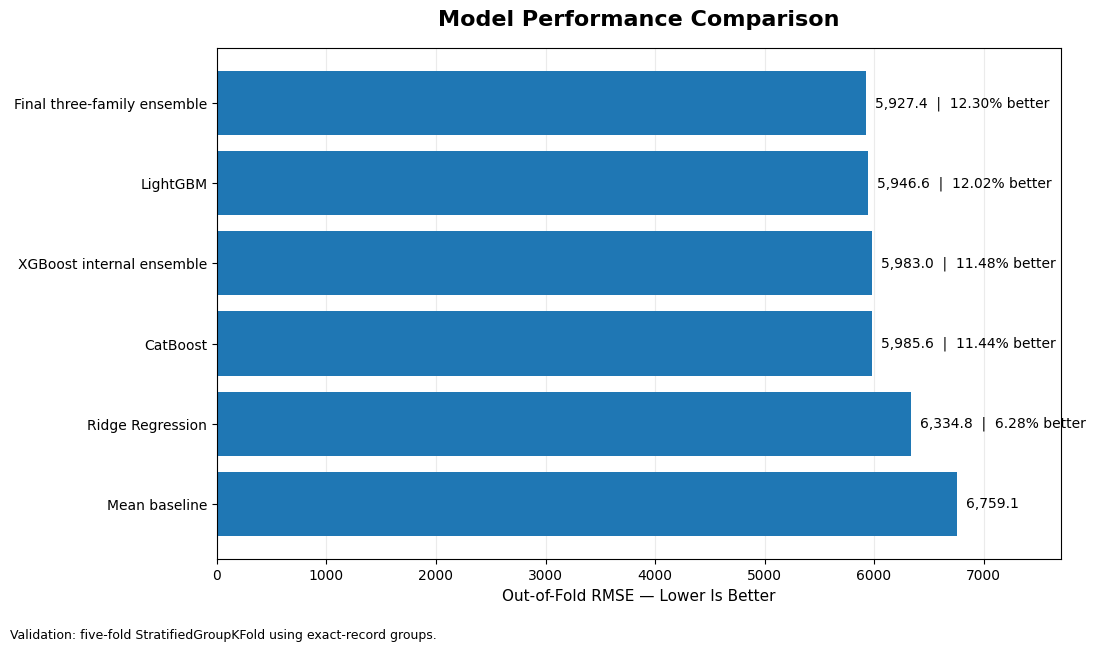

Saved: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\assets\model_performance.png


In [474]:
model_performance_plot = (
    readme_model_performance
    .sort_values(
        "oof_rmse",
        ascending=True,
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

bars = ax.barh(
    model_performance_plot[
        "model"
    ],
    model_performance_plot[
        "oof_rmse"
    ],
)

ax.invert_yaxis()

ax.set_title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Out-of-Fold RMSE — Lower Is Better",
    fontsize=11,
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.set_axisbelow(True)

maximum_rmse = (
    model_performance_plot[
        "oof_rmse"
    ].max()
)

ax.set_xlim(
    0,
    maximum_rmse * 1.14,
)

for bar, rmse, improvement in zip(
    bars,
    model_performance_plot[
        "oof_rmse"
    ],
    model_performance_plot[
        "improvement_percent"
    ],
):
    label = f"{rmse:,.1f}"

    if improvement > 0:
        label += (
            f"  |  {improvement:.2f}% better"
        )

    ax.text(
        bar.get_width()
        + maximum_rmse * 0.012,

        bar.get_y()
        + bar.get_height() / 2,

        label,

        va="center",
        fontsize=10,
    )

fig.text(
    0.01,
    0.01,
    (
        "Validation: five-fold "
        "StratifiedGroupKFold using exact-record groups."
    ),
    fontsize=9,
)

fig.tight_layout(
    rect=[0, 0.04, 1, 1]
)

MODEL_PERFORMANCE_PATH = (
    ASSETS_DIR
    / "model_performance.png"
)

fig.savefig(
    MODEL_PERFORMANCE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    MODEL_PERFORMANCE_PATH
)

### Target Distribution

Book vote counts are strongly right-skewed.

A small number of highly popular books have substantially larger vote counts than the majority of observations. The logarithmic representation makes the central distribution easier to inspect.

In [475]:
assert np.isfinite(
    y_array
).all()

assert np.all(
    y_array >= 0
)

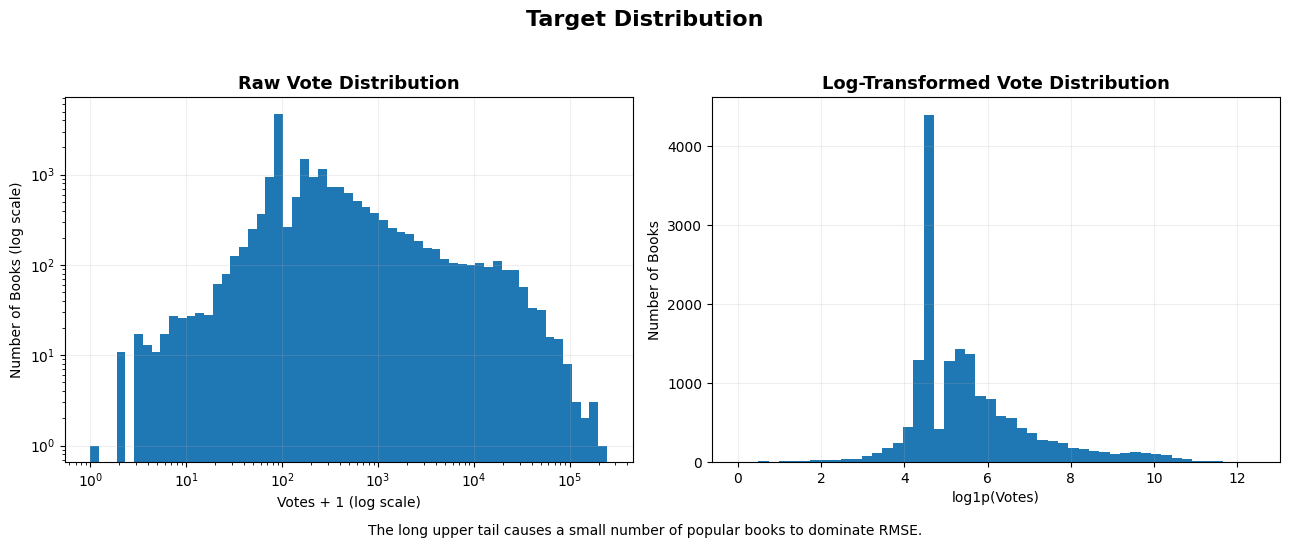

Saved: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\assets\target_distribution.png


In [476]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
)

# Raw target displayed using logarithmic axes.
raw_log_bins = np.logspace(
    0,
    np.log10(
        y_array.max() + 1
    ),
    60,
)

axes[0].hist(
    y_array + 1,
    bins=raw_log_bins,
)

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_title(
    "Raw Vote Distribution",
    fontsize=13,
    fontweight="bold",
)

axes[0].set_xlabel(
    "Votes + 1 (log scale)"
)

axes[0].set_ylabel(
    "Number of Books (log scale)"
)

axes[0].grid(
    alpha=0.20,
)

# Log-transformed target.
log_target = np.log1p(
    y_array
)

axes[1].hist(
    log_target,
    bins=50,
)

axes[1].set_title(
    "Log-Transformed Vote Distribution",
    fontsize=13,
    fontweight="bold",
)

axes[1].set_xlabel(
    "log1p(Votes)"
)

axes[1].set_ylabel(
    "Number of Books"
)

axes[1].grid(
    alpha=0.20,
)

fig.suptitle(
    "Target Distribution",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)

fig.text(
    0.5,
    -0.02,
    (
        "The long upper tail causes a small "
        "number of popular books to dominate RMSE."
    ),
    ha="center",
    fontsize=10,
)

fig.tight_layout()

TARGET_DISTRIBUTION_PATH = (
    ASSETS_DIR
    / "target_distribution.png"
)

fig.savefig(
    TARGET_DISTRIBUTION_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    TARGET_DISTRIBUTION_PATH
)

### Final Ensemble Composition

The final prediction combines four gradient-boosting models.

LightGBM receives the largest weight, while CatBoost and two XGBoost configurations provide complementary prediction patterns.

In [477]:
assert np.isclose(
    sum(
        final_ensemble_specification.values()
    ),
    1.0,
)

In [478]:
ensemble_display_names = {
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
    "xgboost_depth5": "XGBoost Depth 5",
    "xgboost_depth7": "XGBoost Depth 7",
}

In [479]:
ensemble_weight_table = pd.DataFrame({
    "model": [
        ensemble_display_names[
            model_name
        ]
        for model_name
        in final_ensemble_specification
    ],

    "weight_percent": [
        weight * 100
        for weight
        in final_ensemble_specification.values()
    ],
})

In [480]:
ensemble_weight_table = (
    ensemble_weight_table
    .sort_values(
        "weight_percent",
        ascending=True,
    )
    .reset_index(drop=True)
)

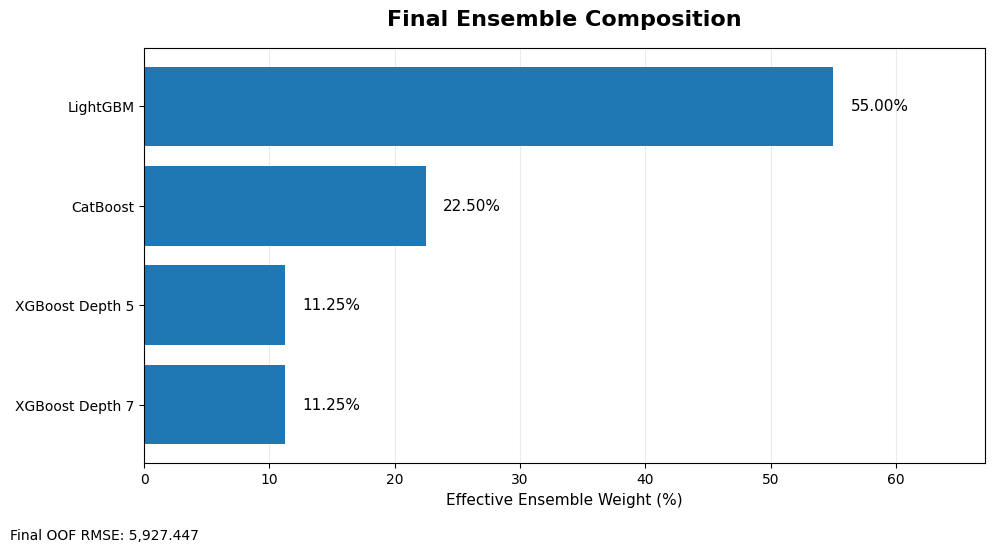

Saved: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\assets\final_ensemble.png


In [481]:
fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

bars = ax.barh(
    ensemble_weight_table[
        "model"
    ],
    ensemble_weight_table[
        "weight_percent"
    ],
)

ax.set_title(
    "Final Ensemble Composition",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Effective Ensemble Weight (%)",
    fontsize=11,
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.set_axisbelow(True)

maximum_weight = (
    ensemble_weight_table[
        "weight_percent"
    ].max()
)

ax.set_xlim(
    0,
    maximum_weight * 1.22,
)

for bar, value in zip(
    bars,
    ensemble_weight_table[
        "weight_percent"
    ],
):
    ax.text(
        bar.get_width()
        + maximum_weight * 0.025,

        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.2f}%",

        va="center",
        fontsize=11,
    )

fig.text(
    0.01,
    0.01,
    (
        "Final OOF RMSE: "
        f"{final_oof_rmse:,.3f}"
    ),
    fontsize=10,
)

fig.tight_layout(
    rect=[0, 0.04, 1, 1]
)

FINAL_ENSEMBLE_PATH = (
    ASSETS_DIR
    / "final_ensemble.png"
)

fig.savefig(
    FINAL_ENSEMBLE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    FINAL_ENSEMBLE_PATH
)

### Actual versus Out-of-Fold Predictions

Out-of-fold predictions provide an unbiased representation of model performance for the stored validation strategy.

The logarithmic scale makes both common low-vote observations and rare high-vote observations visible in the same figure.

In [482]:
assert (
    len(final_oof_predictions)
    == len(y_array)
)

assert np.isfinite(
    final_oof_predictions
).all()

assert np.all(
    final_oof_predictions >= 0
)

In [483]:
actual_log_votes = np.log1p(
    y_array
)

predicted_log_votes = np.log1p(
    final_oof_predictions
)

In [484]:
plot_minimum = float(
    min(
        actual_log_votes.min(),
        predicted_log_votes.min(),
    )
)

plot_maximum = float(
    max(
        actual_log_votes.max(),
        predicted_log_votes.max(),
    )
)

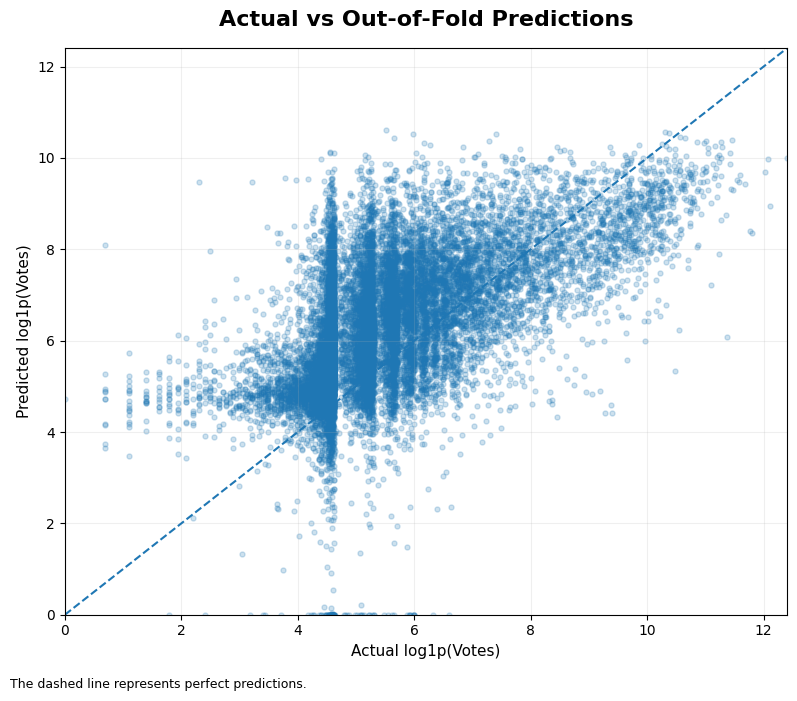

Saved: D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST\PREDICTION BOOK VOTING\assets\actual_vs_oof_predictions.png


In [485]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.scatter(
    actual_log_votes,
    predicted_log_votes,
    s=13,
    alpha=0.22,
)

ax.plot(
    [
        plot_minimum,
        plot_maximum,
    ],
    [
        plot_minimum,
        plot_maximum,
    ],
    linestyle="--",
    linewidth=1.5,
)

ax.set_title(
    "Actual vs Out-of-Fold Predictions",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Actual log1p(Votes)",
    fontsize=11,
)

ax.set_ylabel(
    "Predicted log1p(Votes)",
    fontsize=11,
)

ax.grid(
    alpha=0.20,
)

ax.set_xlim(
    plot_minimum,
    plot_maximum,
)

ax.set_ylim(
    plot_minimum,
    plot_maximum,
)

fig.text(
    0.01,
    0.01,
    (
        "The dashed line represents "
        "perfect predictions."
    ),
    fontsize=9,
)

fig.tight_layout(
    rect=[0, 0.03, 1, 1]
)

ACTUAL_VS_PREDICTED_PATH = (
    ASSETS_DIR
    / "actual_vs_oof_predictions.png"
)

fig.savefig(
    ACTUAL_VS_PREDICTED_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)

print(
    "Saved:",
    ACTUAL_VS_PREDICTED_PATH
)

In [486]:
portfolio_visual_paths = {
    "Model performance": (
        MODEL_PERFORMANCE_PATH
    ),

    "Target distribution": (
        TARGET_DISTRIBUTION_PATH
    ),

    "Final ensemble": (
        FINAL_ENSEMBLE_PATH
    ),

    "Actual versus prediction": (
        ACTUAL_VS_PREDICTED_PATH
    ),
}

In [487]:
portfolio_visual_summary = pd.DataFrame({
    "visual": (
        portfolio_visual_paths.keys()
    ),

    "path": [
        str(path)
        for path
        in portfolio_visual_paths.values()
    ],

    "exists": [
        path.is_file()
        for path
        in portfolio_visual_paths.values()
    ],

    "size_kb": [
        (
            path.stat().st_size
            / 1024
            if path.is_file()
            else np.nan
        )
        for path
        in portfolio_visual_paths.values()
    ],
})

portfolio_visual_summary.round(2)

,visual,path,exists,size_kb
0,Model performance,D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST...,True,112.49
1,Target distribution,D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST...,True,105.21
2,Final ensemble,D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST...,True,69.93
3,Actual versus prediction,D:\JOB HUNTING\END TO-END PROJECT DATA ANALYST...,True,742.25


In [488]:
assert (
    portfolio_visual_summary[
        "exists"
    ].all()
)

assert (
    portfolio_visual_summary[
        "size_kb"
    ] > 0
).all()

print(
    "All portfolio visualizations "
    "were created successfully."
)

All portfolio visualizations were created successfully.
